# **Projektets Syfte:**
För dig som är osäker på om ett mail är spam, (reklam eller social notification.)

Det här projektet har som mål att göra e-posthantering enklare och snabbare. Genom att automatiskt klassificera inkommande mejl som antingen sociala notifikationer (från vänner, familj eller plattformar som Facebook och LinkedIn) eller reklamutskick (nyhetsbrev, kampanjerbjudanden och marknadsföring) hjälper verktyget användare att snabbt sålla bort brus och fokusera på det som verkligen betyder något.

Verktyget fungerar för både svenska och engelska mejl och bygger på maskininlärning, där modeller som Random Forest och XGBoost tränats för att känna igen skillnaderna mellan dessa kategorier. Projektet innefattar hela kedjan! Från datahantering och rengöring av e-postfiler, till prediktion och visualisering av resultat i en Power BI-instrumentpanel.

Syftet är i grunden att ***spara tid***, ***minska manuell sortering*** och ge användaren en ***bättre överblick*** över sin inkorg.
Funkar för både svenska och engelska mail.


Resterade anteckningar och förklaringar kommer att vara skrivna på engelska.

.

# **The Project's Purpose:**

To help users quickly and confidently determine whether an email is a social notification or a promotional advertisement, reducing the time and effort spent on manual email sorting.

Why use this? *To save time.*

This project aims to make email management simpler and faster. By automatically classifying incoming emails as either social notifications (from friends, family, or platforms like Facebook and LinkedIn) or promotional advertisements (newsletters, campaign offers, and marketing), the tool helps users quickly filter out noise and focus on what truly matters.

The tool works for both Swedish and English emails and is built on machine learning, where models such as Random Forest and XGBoost have been trained to recognize the differences between these categories. The project covers the entire pipeline – from data handling and cleaning of email files, to prediction and visualization of results in a Power BI dashboard.

The core purpose is to ***save time***, ***reduce manual sorting***, and give users a ***better overview*** of their inbox.

Works for both swedish and english mail


# **Before you get started ! Important !**

For this to work, you must accept that the file is given access to your Google Drive and that it is allowed to make changes to it: add folders, create new files, overwrite files.

#**Cell 1: Mount Google Drive & Setup Project**

**What it does:**

This Cell sets up the project envionment in Google Colab. It's the foundation that all other cells depend on. Think of it as unpacking a backpack :) It finds ones workspace, makes sure certain folders exist, and gets the application ready to start working. Without it, the rest of the code wouldn't know where to save files or find data.

**Why it's needed:**
1. **It mounts Google Drive** (drive.mount()). It connects Colab to your Google Drive so you can access files. Without this, you'd lose all your work when the session ends

2. **Finds your project location** (the for loop with os.walk()). It searches through your Google Drive to find where this notebook is saved. Stores the path as *project_path* variable. All of this ensures that all file operations use the correct directory.

3. **Sets the working directory** (os.chdir()). More specifically it changes Python's current working directory to your project folder. So when you save files, they go to the *right place*.

4. **Creates project folders** (os.makedirs()). It builds the folder structure needed for the project:
    * data/raw - for uploaded datasets
    * data/processed - for cleaned data
    * models/saved - for trained models
    * src - for source code
    * notebooks - for additional notebooks

In [1]:
# -----------------------------------------------
#    CELL 1: Mount Google Drive & Setup Project
# -------------------------------------------------

import os # imports pythons OS module, a library with functions for interacting with the OS
from google.colab import drive # imports drive module from google's "colab" package --> so notebook can interact with G-Drive

drive.mount("/content/drive") # Mounts Google Drive so that performed work is saved

NOTEBOOK_NAME = "SocialOrPromotion_AI_project-WillJohnFri.ipynb" # The name of the google colab file

print(f"Searching... Looking for {NOTEBOOK_NAME} in Google Drive...")

project_path = None # Set to None for error handling / Safety check to see if it was accutaly found

for root, dirs, files in os.walk("/content/drive/MyDrive"): # Walk through Drive to find the notebook
    if NOTEBOOK_NAME in files: # if the NOTEBOOK_NAME variable is found in a folder
        project_path = root # Checkmark. If the google colab file could be found root will be saved in this variable
        print(f"Nice! Found notebook in: {project_path}") # Prints the path to the project
        break

if project_path is None:
    raise FileNotFoundError(
        f"Oh no! Could not find {NOTEBOOK_NAME}\n"
        f"       Make sure the notebook is saved in your Google Drive"
    )

os.chdir(project_path) # Change to the notebook's directory

folders = ["data/raw", "data/processed", "models/saved", "src", "notebooks"]# Create project folders (optional, but good to add)
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(f"\n Nice! Project ready!")
print(f"         Working directory: {os.getcwd()}") # Prints the current working directory
print(f"         Created folders: {', '.join(folders)}") # Prints all the created folders


Mounted at /content/drive
Searching... Looking for SocialOrPromotion_AI_project-WillJohnFri.ipynb in Google Drive...
Nice! Found notebook in: /content/drive/MyDrive/AI KURS: WilliamJohanssonFridén YH02444-2024-1-2-3/AI kurs/AI Spam or Ham project

 Nice! Project ready!
         Working directory: /content/drive/MyDrive/AI KURS: WilliamJohanssonFridén YH02444-2024-1-2-3/AI kurs/AI Spam or Ham project
         Created folders: data/raw, data/processed, models/saved, src, notebooks


#**Cell 2: Installing required libraries**

**What it does:**

This cell installs all the Python packages needed for the project automatically. ( based on a requirements.txt ). This cell is like a "shopping list" that automatically buys and sets up all the tools needed for the project.

**Why it's needed:**
1. **Automates dependency installation** (!pip install -r requirements.txt). It reads a file called requirements.txt that lists all needed packages. Then it installs everything in one go (like pandas, scikit-learn, xgboost, etc.). Meaning you do not need to manually type/install everything.

2. **Checks if requirements file exists** (os.path.exists()). The cell looks for requirements.txt in the project folder. If it's missing, it skips installation and warns you.

3. **Provides helpful error messages.** The cell will tell you exactly what went wrong if installation fails. It will then give suggestions for fixing common issues.



In [2]:
# -----------------------------------------------
#   CELL 2: Time to install required libraries :))))
# -------------------------------------------------

requirements_path = os.path.join(project_path, "requirements.txt") # Will look for the .txt file in current directory

if os.path.exists(requirements_path):
  print("\n Nice! Found requirements.txt. Installing the packages...")
  try:
      !pip install -r "$requirements_path" # Installs everything from requirements.txt
      print("Nice! All packages installed successfully!")
  except Exception as e: # If something went wrong it will give some form of explenation
      print(f"Oh no! Failed to install the packages >:( {e})") # Shows a user-friendly error message
      print("Possible fix; Check requirements.txt format or internet connection")
else:
  print("\n Warning: No requirements.txt found. Skipping package installation.")
  print(f"Looked for: {requirements_path}")
  print("\n Possible fix: Try downloading requirements.txt from GitHub")



 Nice! Found requirements.txt. Installing the packages...
Nice! All packages installed successfully!


#**Cell 3: Downloading the NLTK Data**

**What it does:**

This cell downloads and prepares text processing tools from the Natural Language Toolkit (NLTK) library. Think of this cell like "learning the alphabet" before you can read. Text processing requires special tools to understand language. It NEEDS to know which words are common filler (stopwords), how to split text into pieces (tokenization), and how to simplify words to their roots (lemmatization). This cell downloads and prepares all those tools so the later text preprocessing can work properly.

**Why it's needed:**
1. **It downloads essential NLTK packages** (the for loop)
    * stopwords - Common words to ignore (like "the", "and", "is") in both English and Swedish

    * punkt - Sentence and word tokenizer (splits text into sentences/words)

    * wordnet - Lemmatizer (reduces words to their base form, e.g., "running" → "run")

    * averaged_perceptron_tagger - Parts-of-speech tagger (identifies nouns, verbs, etc.)

2. **Loads stopwords for both languages** (stopwords.words()). Stopwords are common words that add little meaning and can hence be removed. This helps the application to focus on meaningful content when classifying emails.

    * Swedish stopwords - Words like "och", "att", "det" that don't add meaning

    * English stopwords - Words like "the", "and", "to" that don't add meaning

    * The cell combines them into one set (all_stopwords) for multilingual support

3. **Handles errors gracefully** (try/except blocks). For example: if a download fails, it catches the error and continues. The cell attempts to retry downloading if Swedish stopwords aren't available.

In [3]:
# --------------------------------------
#   CELL 3: Downloading NLTK Data
# -----------------------------------------

import nltk # Import Natural Language Toolkit for text processing

print("Downloading NLTK data...")

nltk_packages = ["stopwords", "punkt", "wordnet", "averaged_perceptron_tagger"] # List to use when downloading the required NLTK packages

for package in nltk_packages: # Loops through each package to download
    try: # Try to download the package
        nltk.download(package)
        print(f"Nice! Downloaded NLTK package: {package}")
    except Exception as e:
        print(f"Oh no! Failed to download NLTK package: {package} >:( {e}")

from nltk.corpus import stopwords # Checking both English and Swedish stopwords

try: # Downloading the Swedish stopwords
  swedish_stopwords = stopwords.words('swedish') # Load the Swedish stopword list from NLTK
  print(f"\nNice! Loaded {len(swedish_stopwords)} Swedish stopwords :DDD") # Show how many were loaded
except Exception as e: # Even if it fails the except statement will try anyways >:)
  print(f"Oh no! Failed to load Swedish stopwords >:( {e}")
  nltk.download('stopwords') # Ensure that the Swedish stopwords are downloaded
  swedish_stopwords = stopwords.words('swedish') # Load them again after downloading
  print(f"\nNice! Loaded {len(swedish_stopwords)} Swedish stopwords :DDD")

english_stopwords = stopwords.words('english') # Downloading the English stopwords
print(f"Nice! Loaded {len(english_stopwords)} Enlgish stopwords :DDD")

all_stopwords = set(english_stopwords + swedish_stopwords) # Combining both into one set for multilingual support
print(f"Total combined stopwords: {len(all_stopwords)}")

Nice! Downloaded NLTK package: stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Nice! Downloaded NLTK package: punkt
Nice! Downloaded NLTK package: wordnet


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...


Nice! Downloaded NLTK package: averaged_perceptron_tagger

Nice! Loaded 114 Swedish stopwords :DDD
Nice! Loaded 198 Enlgish stopwords :DDD
Total combined stopwords: 310


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


#**Cell 4: Smart Upload & Extract .mbox Dataset**

**What it does:**

It handles getting the users email data into the project. More specifically it handles uploading, extracting, and cleaning email datasets. Before you continue, make sure to have extracted a ZIP file containing your emails. Think of this like a "mail sorter" that takes a messy pile of emails and organizes them!

***To download your dataset*** --> go to Google Takeout --> Uncheck everything except Gmail --> Then select the two tabs for Social and Promotion, (Social & Kampanj) --> Download those. This will be your dataset.

**Why it's needed:**

    1. Accepts your email data (like dumping a box of letters on a table)
    2. Reads each email (opens each envelope)
    3. Cleans it up (removes junk, extracts the important text)
    4. Sorts it into categories (puts letters in the right pile: "Promotion" or "Social")
    5. Saves the organized data for later use (files everything away neatly)

---
**More detailed explanation:**


1. **Uploads email data** (files.upload()). Instead of making you upload and process 500+ MB of emails every time you restart Colab (which takes 6+ minutes!), it first checks if you already have processed data saved. IF NOT = you will have to have some faith :)
    * Allows users to upload a ZIP file containing *.mbox* email data. [ .mbox is a standard format for storing email collections from Googlemail ]
    * Handles the file upload process through Google Colab's interface.

.

2. **Extracts and parses emails** (zipfile, mailbox.mbox()). It unzips the uploaded file and then reads the .mbox format using Python's mailbox module. All of this to then extract individual emails from said archive.

.

3. **Cleans email content** (EmailProcessor class).
    * Decodes headers by handling encoded subject lines, sender names like: =?utf-8?B?...
    * Extracts body. It gets plain text from email and handles both plain text and HTML.
    * Removes clutter by stripping out reply headers, signatures, quoted text, and promotional boilerplate.
    * Lastly it combines subject + body for better text analysis.

> *Promotional boilerplate* refers to standardized, reusable text that is used in marketing or promotional materials.

.

4. **Categorizes emails automatically** (determine_category()). It detects two different categories by looking at filenames:
    * "Kategoring Socialt.mbox" converts it to "social".
    * "Kategoring Kampanjer.mbox" convers it to "promotion".

.

5. **Smart dataset management** (DatasetManager class).
    * It checks for existing data. If you already processed a dataset, it asks if you want to reuse it.
    * It saves progress by creating checkpoints every 1000 emails to prevent data loss.
    * Caches results. Saves cleaned data as CSV for future use. CSV is for analysis and machine learning while mbox is for storage and email clients. This is why result is saved as CSV.

.

6. **The Debug mode!!!** When testing and/or debuging the code you can prcoess 20 emails instead of 10.000+. **FYI**: if you want to Debug you need to change the Debug value to True, otherwise keep it as False.

---

**What happens to your data:**

- Raw emails → Stored in `data/raw/`
- Cleaned emails → Saved as CSV in `data/processed/cleaned_emails_TIMESTAMP.csv`
- Checkpoints → Saved as `checkpoint.csv` in the project root

In [4]:
# ------------------------------------------
# CELL 4: Smart Upload & Extract .mbox Dataset
# --------------------------------------------

import zipfile # provides tools for creating, reading, writing, appending, and listing contents of ZIP files
import os # imports pythons OS module, a library with functions for interacting with the OS
import mailbox # provides classes for reading and writting mailbox files in various formats (mbox, Maildir, etc)
import email # provides tools for parsing, handling, and generating email messages according to the MIME (Multipurpose Internet Mail Extensions) standard
from email import policy # defines how email messages should be parsed and handled
from email.parser import BytesParser # specifically designed to parse email messages from bytes (raw binary data) into structured email message objects
from google.colab import files # functions for uploading files from your local computer to the Colab runtime environment
import pandas as pd # imports the pandas library, provides structures like DataFrames and Series for working with structured data
from datetime import datetime # provides tools for working with dates and times
import re # regular expression module, provides powerful pattern-matching and text manipulation capabilities using regular expressions
import shutil # python's shell utilities module, provides high-level operations for working with files + directories, like copying, moving, renaming, deleting files + entire directory trees
from email.header import decode_header, make_header # for decoding email headers and using that output to create a header object
import glob # provides functions for finding all file paths that match a specific pattern using wildcard characters: [*], [?]
from typing import Optional, List, Dict, Tuple, Any  # Type hints for better code clarity
from dataclasses import dataclass, field  # For creating data containers
from pathlib import Path  # For modern path handling


# ==========================================
# PART 1: DATA CLASSES & CONFIGURATION
# ==========================================

@dataclass # automatically generates common methods for data-focused classes
class EmailData: # represents a single cleaned email with all its relevant fields
    """Container for cleaned email data"""
    from_addr: str  # Sender email address
    to_addr: str  # Recipient email address
    subject: str  # Email subject line
    date: str  # Email date
    text: str  # Cleaned email body text
    original_file: str  # Source mbox filename
    category: str  # Email category (social/promotion)


    def to_dict(self) -> Dict: # Converts an EmailData object into a Python directory. This is a bridge method transforming the structured object into a format pandas can easily consume
        """Convert to dictionary for DataFrame creation"""
        return {
            "from": self.from_addr,
            "to": self.to_addr,
            "subject": self.subject,
            "date": self.date,
            "text": self.text,
            "original_file": self.original_file,
            "category": self.category
        }


class DatasetConfig:
    """Configuration for dataset processing"""


    def __init__(self, debug_mode: bool = False):
        self.debug_mode = debug_mode  # Set to False for full processing (or True for testing)
        self.max_emails = 20 if debug_mode else None  # Limit for testing, None means unlimited, can be changed near the end of this Cell!
        self.folder_mappings = {  # Maps filename patterns to categories
            "socialt": "social",  # Swedish for "social"
            "kampanjer": "promotion"  # Swedish for "campaigns"
        }
        self.checkpoint_interval = 1000  # Save checkpoint every N emails
        self.cleanup_patterns = [  # Regex patterns to remove from email body
            r"^On .+ wrote:",  # English reply headers
            r"^Den .+ skrev:",  # Swedish reply headers
            r"^>.*$",  # Quoted text (email replies)
            r"^Sent from my .+$",  # English mobile signatures
            r"^Skickat från min .+$",  # Swedish mobile signatures
            r"^Med vänlig hälsning.*$",  # Swedish closing (kind regards)
            r"^Vänligen.*$",  # Swedish polite requests
            r"^Mvh.*$"  # Swedish abbreviation (med vänlig hälsning)
        ]




# ==========================================
# PART 2: UTILITY FUNCTIONS
# ==========================================


def decode_header_value(header_value: Optional[str]) -> str: # this function decodes email header values where the parameter is either sting or None always returns a string.
    """Decode email header values that might be encoded"""
    if header_value is None:
        return "Unknown"  # Return placeholder for missing headers

    try:
        if isinstance(header_value, str): # if header_values is a string otherwise except Exceptions as e
            if "=?" in header_value:  # Check for encoded string pattern (e.g., =?utf-8?B?...)
                decoded_header = make_header(decode_header(header_value))  # Decode email header
                return str(decoded_header)  # Convert to readable string
            return header_value  # Return as-is if not encoded
        elif isinstance(header_value, bytes):
            return header_value.decode('utf-8', errors='ignore')  # Decode bytes to string
        else:
            return str(header_value)  # Convert other types to string
    except Exception as e:
        print(f"Warning: Could not decode header: {e}")  # Log decoding failure
        return "Unknown"  # Return placeholder on error


def extract_body(email_message) -> str:
    """Extract and clean email body from message"""
    body = ""  # Initialize body content

    if email_message.is_multipart():  # Check if email has multiple parts
        for part in email_message.walk():  # Iterate through email parts
            if part.get_content_type() == "text/plain":  # Prefer plain text content
                body_part = part.get_payload(decode=True)  # Decode the part
                if body_part is None:
                    continue  # Skip if no content
                encoding = part.get_content_charset() or "utf-8"  # Get character encoding
                try:
                    body += body_part.decode(encoding, errors="ignore")  # Decode to string
                except:
                    body += body_part.decode("utf-8", errors="ignore")  # Fallback to utf-8
                break  # Stop after finding plain text
            elif part.get_content_type() == "text/html" and not body:  # Fallback to HTML
                try:
                    body_part = part.get_payload(decode=True)  # Decode HTML part
                    if body_part is None:
                        continue
                    encoding = part.get_content_charset() or "utf-8"  # Get encoding or default
                    try:
                        html_text = body_part.decode(encoding, errors="ignore")  # Decode HTML
                    except:
                        html_text = body_part.decode("utf-8", errors="ignore")  # Fallback decode
                    body = re.sub(r"<.*?>", " ", html_text)  # Remove HTML tags with regex
                except:
                    continue
    else:
        try:
            body_part = email_message.get_payload(decode=True)  # Get payload for non-multipart
            if body_part:
                encoding = email_message.get_content_charset() or "utf-8"  # Get encoding or default
                try:
                    body = body_part.decode(encoding, errors="ignore")  # Decode body
                except:
                    body = body_part.decode("utf-8", errors="ignore")  # Fallback decode
        except:
            body = str(email_message.get_payload())  # Convert to string as last resort

    return body  # Return extracted body


def clean_email_text(body: str, subject: str, config: DatasetConfig) -> str:
    """Clean and combine email subject and body"""
    if body:
        body = " ".join(body.split())  # Remove extra whitespace and newlines
        for pattern in config.cleanup_patterns:  # Apply all cleanup patterns
            body = re.sub(pattern, "", body, flags=re.MULTILINE)  # Remove pattern from body

    subject = subject if subject != "Unknown" else ""  # Get subject or empty
    combined_text = subject + " " + body if body else subject  # Combine subject and body
    return combined_text.strip()  # Return cleaned text with whitespace removed


# ==========================================
# PART 3: EMAIL PROCESSING CLASSES
# ==========================================

class EmailProcessor:
    """Handles email cleaning and processing"""


    def __init__(self, config: DatasetConfig):
        self.config = config  # Store configuration


    def clean_email_metadata(self, email_message, source_file: str) -> Optional[EmailData]:
        """Clean email metadata and create EmailData object"""
        try:
            # Extract and decode email headers
            from_addr = decode_header_value(email_message.get("From", "Unknown"))  # Sender
            to_addr = decode_header_value(email_message.get("To", "Unknown"))  # Recipient
            subject = decode_header_value(email_message.get("Subject", "No Subject"))  # Subject
            date = decode_header_value(email_message.get("Date", "Unknown"))  # Date

            # Extract and clean body
            body = extract_body(email_message)  # Get raw body
            cleaned_text = clean_email_text(body, subject, self.config)  # Clean and combine

            # Create EmailData object
            return EmailData( # creates and returns a new EmailData object with all the cleaned email data packaged together
                from_addr=from_addr,
                to_addr=to_addr,
                subject=subject,
                date=date,
                text=cleaned_text,
                original_file=source_file,
                category="unknown"  # Will be set later
            )

        except Exception as e:
            print(f"Failed to clean email metadata: {e}")  # Log cleaning failure
            return None  # Return None if processing fails


    def determine_category(self, filename: str) -> Optional[str]:
        """Determine email category based on filename"""
        filename_lower = filename.lower()  # Convert to lowercase for matching

        for pattern, category in self.config.folder_mappings.items():  # Check each pattern
            if pattern in filename_lower:  # Pattern found in filename
                return category  # Return matching category

        return None  # No matching category found


class MBoxProcessor:
    """Handles mbox file processing and email extraction"""


    def __init__(self, email_processor: EmailProcessor, project_path: str):
        self.email_processor = email_processor  # Store email processor
        self.project_path = project_path  # Store project path for checkpoints
        self.processed_emails: List[EmailData] = []  # List to store processed emails


    def process_mbox_file(self, mbox_path: str, category: str) -> int:
        """Process a single mbox file and extract emails"""
        print(f"\nProcessing: {os.path.basename(mbox_path)}")  # Show current file
        processed_count = 0  # Counter for this file

        try:
            mbox = mailbox.mbox(mbox_path)  # Load mbox file

            # Count emails (only if not in debug mode)
            if not self.email_processor.config.debug_mode:
                email_count = sum(1 for _ in mbox)  # Count all emails
                print(f"  → Contains {email_count} emails")  # Display count
                mbox = mailbox.mbox(mbox_path)  # Reload mbox (iterator was consumed)
            else:
                max_emails = self.email_processor.config.max_emails  # Get debug limit
                print(f"  → DEBUG mode: Processing first {max_emails} emails")  # Debug message

            # Process each email
            for i, message in enumerate(mbox):  # Iterate through emails
                # Check debug mode limit - This is the equivalent of MAX_EMAILS logic
                if self.email_processor.config.debug_mode and i >= self.email_processor.config.max_emails:
                    break  # Stop if debug limit reached

                cleaned_email = self.email_processor.clean_email_metadata(  # Clean email
                    message,
                    os.path.basename(mbox_path)
                )

                if cleaned_email:  # Check if cleaning succeeded
                    cleaned_email.category = category  # Assign category
                    self.processed_emails.append(cleaned_email)  # Add to collection
                    processed_count += 1  # Increment counter

                    # Checkpoint saving
                    if processed_count % self.email_processor.config.checkpoint_interval == 0 and not self.email_processor.config.debug_mode:
                        self.save_checkpoint()  # Save progress checkpoint
                        print(f"  → Saved checkpoint after {processed_count} emails")  # Confirm checkpoint

            print(f"  → Processed {processed_count} emails from {os.path.basename(mbox_path)}")  # Summary

        except Exception as e:
            print(f"  → Failed to process {mbox_path}: {e}")  # Log file processing failure

        return processed_count  # Return count of processed emails


    def save_checkpoint(self, checkpoint_path: str = "checkpoint.csv") -> None:
        """Save checkpoint of processed emails"""
        if self.processed_emails:  # Check if there are emails to save
            df = pd.DataFrame([email.to_dict() for email in self.processed_emails])  # Convert to DataFrame
            checkpoint_full_path = os.path.join(self.project_path, checkpoint_path)  # Full path
            df.to_csv(checkpoint_full_path, index=False)  # Save to CSV


    def get_all_emails(self) -> List[EmailData]:
        """Return all processed emails"""
        return self.processed_emails  # Return the list of emails




# ==========================================
# PART 4: DATASET MANAGEMENT CLASS
# ==========================================

class DatasetManager:
    """Manages dataset loading, uploading, and saving"""


    def __init__(self, project_path: str): # setting up the paths
        self.project_path = Path(project_path)  # Project root directory
        self.processed_path = self.project_path / "data/processed"  # Processed data directory
        self.raw_path = self.project_path / "data/raw"  # Raw data directory


    def find_existing_dataset(self) -> Optional[pd.DataFrame]: # In case the user wants to save time by using pre-existing data from previous run
        """Check for and load existing dataset"""
        existing_csv_files = glob.glob(str(self.processed_path / "cleaned_emails_*.csv"))  # Find CSV files

        if not existing_csv_files:
            return None  # No existing dataset

        latest_csv = max(existing_csv_files, key=os.path.getctime)  # Get newest file
        size_mb = os.path.getsize(latest_csv) / (1024 * 1024)  # Calculate size in MB

        print(f"\n Nice! Found existing cleaned dataset: {os.path.basename(latest_csv)}")  # Show filename
        print(f"       Size: {size_mb:.2f} MB")  # Show size

        use_existing = input("\nDo you want to use this existing dataset? (yes/no): ").lower()  # Ask user

        if use_existing in ['yes', 'y', '']:  # Check affirmative response
            df = pd.read_csv(latest_csv)  # Load dataset
            print(f"Nice! Loaded {len(df)} emails from existing dataset!")  # Show count
            print("Category distribution:")  # Show distribution header
            print(df["category"].value_counts())  # Display category counts
            return df  # Return loaded DataFrame

        return None  # User declined existing dataset


    def upload_and_extract(self) -> bool:
        """Handle file upload and extraction"""
        print("\n 1st step: Please upload the dataset ZIP file")  # Upload instruction
        print("(Click the 'Choose Files' button that appears below)")  # UI instruction

        uploaded = files.upload()  # Trigger file upload

        # Find uploaded zip file
        zip_path = None  # Initialize zip path
        for filename in uploaded.keys():  # Check uploaded files
            if filename.lower().endswith(".zip"):  # Find zip file
                zip_path = filename  # Store filename
                print(f"\nNice! Found ZIP file: {filename}")  # Confirm found
                break  # Stop searching

        if not zip_path:  # No zip file found
            print("\nOh no! No ZIP file found! Please upload a .zip file containing the .mbox data set you want to use.")  # Error message
            return False  # Return failure

        # Move zip to project directory
        saved_zip = self.project_path / zip_path  # Create full path
        if not saved_zip.exists():  # Check if already exists
            shutil.move(zip_path, saved_zip)  # Move to project folder

        # Extract zip file
        print(f"\nStep 2: Extracting {zip_path} to {self.raw_path}...")  # Extraction message

        try:
            if self.raw_path.exists():  # Check if raw directory exists
                print("\nRemoving previously extracted dataset...")  # Cleanup message
                shutil.rmtree(self.raw_path)  # Delete old raw data

            self.raw_path.mkdir(parents=True, exist_ok=True)  # Create fresh directory

            with zipfile.ZipFile(saved_zip, "r") as zip_ref:  # Open zip file
                zip_ref.extractall(self.raw_path)  # Extract all contents
            print(f"Nice! Extracted {zip_path} to {self.raw_path}")  # Confirmation
            return True  # Return success

        except zipfile.BadZipFile:  # Invalid zip file
            print(f"Oh no! {zip_path} is not a valid ZIP file. Please make sure you uploaded a valid.zip file!")  # Error message
            return False  # Return failure
        except Exception as e:  # Other errors
            print(f"Oh no! Unexpected error: {e}")  # Error details
            print("Please check your file and try again!")  # Recovery suggestion
            return False  # Return failure

    def find_mbox_files(self) -> List[str]:
        """Find all mbox files in raw data directory"""
        print("\nStep 3: Looking for .mbox files...")  # Search message
        mbox_files = []  # List for mbox files

        for root, dirs, files in os.walk(self.raw_path):  # Walk through directory
            for file in files:  # Check each file
                if file.endswith(".mbox"):  # Found mbox file
                    full_path = os.path.join(root, file)  # Create full path
                    mbox_files.append(full_path)  # Add to list
                    file_size = os.path.getsize(full_path) / (1024 * 1024)  # Calculate size in MB
                    print(f"Nice! Found .mbox file: {file} ({file_size:.2f} MB)")  # Show found file

        if not mbox_files:  # No mbox files found
            print("Please check:")  # Troubleshooting header
            print("   -   Your file extension (should be .mbox)")  # Extension check
            print("   -   The .mbox file should be inside the ZIP")  # Location check
            raise FileNotFoundError("Oh no! No .mbox files found in the dataset! >:(")  # Error

        return mbox_files  # Return list of mbox files

    def save_dataset(self, emails: List[EmailData]) -> pd.DataFrame:
        """Save processed emails to CSV and return DataFrame"""
        print(f"\nStep 5: Saving the cleaned data... Let's GO!!")  # Save message

        self.processed_path.mkdir(parents=True, exist_ok=True)  # Ensure directory exists

        # Create DataFrame
        df = pd.DataFrame([email.to_dict() for email in emails])  # Convert to DataFrame

        # Save to CSV with timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Create timestamp
        csv_path = self.processed_path / f"cleaned_emails_{timestamp}.csv"  # Full path
        df.to_csv(csv_path, index=False)  # Save without index

        print(f"Nice! Saved {len(df)} cleaned emails to: {csv_path}")  # Confirmation

        print("\nDataset Summary:")  # Summary header
        print(f"Total emails: {len(df)}")  # Total count

        print("\nCategory distribution:")  # Distribution header
        print(df["category"].value_counts())  # Category counts

        print("\nSample cleaned email:")  # Sample header
        sample = df.iloc[0]  # First email as sample

        print(f"Category: {sample['category']}")  # Sample category
        print(f"From: {str(sample['from'])[:50]}...")  # Truncated sender
        print(f"To: {str(sample['to'])[:50]}...")  # Truncated recipient
        print(f"Subject: {str(sample['subject'])[:50]}...")  # Truncated subject
        print(f"Text preview: {str(sample['text'])[:100]}...")  # Truncated body

        return df  # Return DataFrame




# ==========================================
# PART 5: MAIN PROCESSING PIPELINE
# ==========================================

def process_dataset(project_path: str, debug_mode: bool = False) -> Optional[pd.DataFrame]:
    """Main pipeline for processing email dataset"""

    # Initialize components
    config = DatasetConfig(debug_mode=debug_mode)  # Create configuration with DEBUG flag
    email_processor = EmailProcessor(config)  # Create email processor
    mbox_processor = MBoxProcessor(email_processor, project_path)  # Create mbox processor
    dataset_manager = DatasetManager(project_path)  # Create dataset manager

    print("="*50)
    print("DATASET UPLOAD & EXTRACTION TIME!!!!! (.mbox support)")
    print("="*50)

    # Step 1: Check for existing dataset
    existing_df = dataset_manager.find_existing_dataset()  # Look for existing data
    if existing_df is not None:  # Found existing dataset
        return existing_df  # Return existing data

    # Step 2: Upload and extract
    if not dataset_manager.upload_and_extract():  # Upload failed
        return None  # Return None on failure

    # Step 3: Find mbox files
    try:
        mbox_files = dataset_manager.find_mbox_files()  # Find all mbox files
    except FileNotFoundError as e:  # No mbox files found
        print(e)  # Print error message
        return None  # Return None

    # Step 4: Process mbox files
    print(f"\nStep 4: Loading and cleaning {len(mbox_files)} .mbox file(s)...")  # Processing message

    for mbox_path in mbox_files:  # Process each mbox
        filename = os.path.basename(mbox_path)  # Get filename
        category = email_processor.determine_category(filename)  # Determine category

        if category is None:  # Unknown category
            print(f"  → Skipping {os.path.basename(mbox_path)} - unknown category")  # Skip message
            continue  # Skip this file

        print(f"  → Categorized as: {category}")  # Show category
        mbox_processor.process_mbox_file(mbox_path, category)  # Process file

    # Step 5: Save and display results
    all_emails = mbox_processor.get_all_emails()  # Get all processed emails

    if not all_emails:  # No emails processed
        print("Oh no! No emails were successfully processed!")  # Error message
        return None  # Return None

    df = dataset_manager.save_dataset(all_emails)  # Save dataset
    return df  # Return final DataFrame



# ==========================================
# PART 6: EXECUTION
# ==========================================

# Main execution - This is where DEBUG is set!
if 'project_path' not in locals():  # Check if project_path exists from previous cells
    print("\nOh no! No dataset loaded. Please run the upload again.")  # Error message
else:
    # --- Set DEBUG mode here ---
    DEBUG = False  # Set to False for full processing (or True for testing) <------------------------------ DEBUG True/False HERE!!!!
    # MAX_EMAILS is now handled internally by DatasetConfig

    # Process the dataset with debug flag
    df = process_dataset(project_path, debug_mode=DEBUG)  # Run main pipeline

    # Store the dataframe in a variable that will persist
    if df is not None:  # Processing succeeded
        print(f"\nNice! Dataset ready with {len(df)} emails!")  # Success message
    else:  # Processing failed
        print("\nOh no! No dataset loaded. Please run the upload again.")  # Failure message

DATASET UPLOAD & EXTRACTION TIME!!!!! (.mbox support)

 Nice! Found existing cleaned dataset: cleaned_emails_20260808_202620.csv
       Size: 27.26 MB

Do you want to use this existing dataset? (yes/no): yes
Nice! Loaded 7568 emails from existing dataset!
Category distribution:
category
promotion    5486
social       2082
Name: count, dtype: int64

Nice! Dataset ready with 7568 emails!


# **Cell 5: Text Preprocessing**
**What it does:**

Transforms raw, messy email text into clean, standardized data that machine learning models can understand. It removes HTML, signatures, reply chains, promotional boilerplate, and words that might accidentally reveal the email's category.

**Why it's needed:**

Raw emails are full of noise. They contain HTML tags, reply chains ("On... wrote:"), email signatures ("Sent from my iPhone"), promotional text ("Click here to unsubscribe"), inconsistent capitalization, and punctuation. This cell systematically removes all that noise and standardizes the text for ML algorithms.

Fyi: Waiting time 14-17 minutes

---


**Detailed functionality:**
1. **HTML & Formatting Extraction** (TextExtractor class).
  * Removes ALL HTML tags - Strips out `<div>`, `<span>`, `<a>` tags, scripts, and styles

  * Extracts visible text - Keeps only what a human would see when reading the email

  * Why? Machine learning models can't learn from HTML code - they need plain text

  * Fallback handling - If BeautifulSoup fails, uses regex to remove tags

.

2. **Label Leakage Prevention** (SuspiciousWordManager class).
  * Removes suspicious phrases - Multi-word patterns that leak label information. Example: "social icons", "campaign sale", "unsubscribe here".

  * Removes suspicious words - Individual words that might reveal the category:

    * Category words: "promotion", "social", "campaign", "kampanj"

    * Names: "william", "fridén", "nogla" (people from the dataset)

    * Company names: "facebook", "instagram", "linkedin", "pinterest"

    * Email jargon: "unsubscribe", "newsletter", "prenumeration" (Swedish for subscription)

    * HTML classes: "container", "header", "footer", "navbar"
    
    * Random strings: "fjmkq", "zx", "jvj" (garbage from HTML)

* Removes leakage patterns - Email structure indicators:

    * Unsubscribe links: "unsubscribe here", "click here to unsubscribe"

    * Browser links: "view in browser", "view this email in your browser"

    * Tracking parameters: "utm_source=", "utm_medium=", "utm_campaign="

    * Reply patterns: "On ... wrote:", "Den ... skrev:" (Swedish)

    * HTML attributes: "class=", "id=", "style=", "data-"

**Why so many words?** Your dataset contains promotional emails that naturally include words like "unsubscribe" or "newsletter". If the model learns that these words = promotion, it's cheating (data leakage). Removing them forces the model to learn from actual content.

.

3. **Subject Line Cleaning** (SubjectCleaner class).
* Removes prefixes - Strips out "RE:", "FW:", "FWD:", "SV:" (Swedish for "Svar" = Reply), "VB:" (Swedish for "Vidarebefordra" = Forward)

* Removes promotional patterns - Strips out "Newsletter #123", "Special offer #456", "Your order confirmation", "Invoice #", "Receipt #"

* Why? Subject lines often contain clues about the email type that could leak the label

.

4. **The 13-Step Text Cleaning Pipeline** (preprocess_text() method).

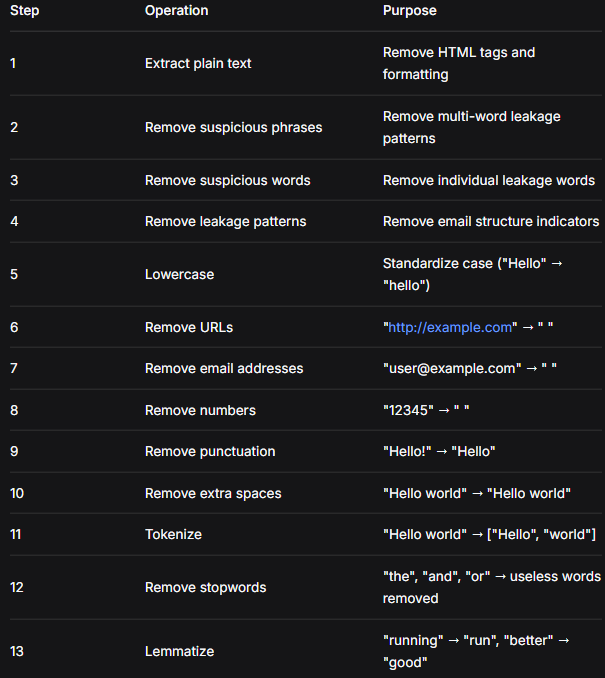




5. **Stopwords for Multilingual Support**.
* English stopwords - Words like "the", "and", "to" that add no meaning

* Swedish stopwords - Words like "och", "att", "det" (since emails are in both languages)

* Combined into one set for processing both languages

.

6. **Validation System** (TextValidator class).
* After cleaning, checks if any suspicious words remain

* Checks for leakage words - Specifically looks for Swedish email footer words: "epostmeddelande", "epostaviseringar", "epost", "meddelande"

* Shows examples - Displays emails that still contain suspicious content

* Top 20 check - Scans for the most common suspicious words

.

---
**What happens to your data:**
* Raw text → Stored in original text column

* Cleaned subject → Added as cleaned_subject

* Subject + body combined → Added as text_with_subject

* Final cleaned text → Added as clean_text (ready for ML)

* Empty rows removed - Emails with no text after cleaning are dropped

In [5]:
# ------------------------------------------
# CELL 5: Text Preprocessing
# ------------------------------------------

import re # regular expression module, provides powerful pattern-matching and text manipulation capabilities using regular expressions
import string # provides a collection of useful constants and utility functions for working with text and characters
import pandas as pd # imports the pandas library, provides structures like DataFrames and Series for working with structured data
import nltk # Natural Language Toolkit for natural language processing, one of the most powerful and comprehensive python libraries
from nltk.tokenize import word_tokenize # splits text into individual words and punctuation tokens
from nltk.stem import WordNetLemmatizer # reduces words to their base or dictionary form (lemma)
from nltk.corpus import stopwords # contains lists of common words in various languages that typically don't carry much meaning for classification tasks ex: "the", "and", "of" or "och", "det", "att"
from bs4 import BeautifulSoup # python library for parsing HTML and XML documents, creates a parse tree that makes it easy to extract data, navigate the structurem and clean up messy web content
from typing import Optional, List, Dict, Set # imports type hints <-- special annotations that tell developers and tools what type of data a variable, function paramater or return value should be, (not enforced at runtime)
from dataclasses import dataclass # imports the @dataclass decorator from python's dataclasses module


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass # automatically generates common methods for data-focused classes
class PreprocessingConfig:
    """Configuration for text preprocessing"""
    min_word_length: int = 2  # Minimum word length to keep
    debug_mode: bool = False  # Enable debug output <--------------------------------------DEBUG True/False !!!!!!!!!!!!!
    stopwords_languages: List[str] = None  # Languages for stopwords

    def __post_init__(self):
        if self.stopwords_languages is None:
            self.stopwords_languages = ['english', 'swedish']  # Default languages


class SuspiciousWordManager:
    """Manages suspicious words and patterns for removal"""

    def __init__(self):
        self.phrases_to_remove = self._get_phrases()  # Multi-word patterns to remove
        self.suspicious_words = self._get_suspicious_words()  # Individual words to remove
        self.leakage_patterns = self._get_leakage_patterns()  # Email-specific patterns

    def _get_phrases(self) -> List[str]:
        """Get phrases that leak label information"""
        return [
            r'beställningar\s+socialicons',
            r'follow\s+social',
            r'following\s+social',
            r'social\s+icons',
            r'social\s+media\s+links',
            r'classic\s+style',
            r'hero\s+forge\s+campaign|spring\s+campaign|sale\s+campaign',
            r'campaign\s+sale|campaign\s+save|campaign\s+offer',
            r'hand\s+socialize',
            r'social\s+facebook',
            r'socialize',
            r'facebook',
            r'avsluta\s+prenumeration',
            r'avsluta\s+prenumerationen',
            r'prenumeration\s+meddelanden',
            r'linkedins\s+varumärken',
            r'email\s+sent',
            r'menlo\s+park',
            r'based\s+interest',
            r'pinterest\s+världsomspännande',
            r'francisco\s+hjälpcenter',
            r'avsett\s+william',
            r'william\s+fridén',
            r'daithi\s+nogla',
            r'message\s+sent',
            r'irland\s+unlimited',
            r'unlimited\s+company',
            r'url\s+unlimited',
            r'place\s+irland',
            r'mer\s+visa',
            r'mini\s+ladd',
            r'irland\s+linkedins',
            r'url\s+världsomspännande',
            r'urldu\s+url',
            r'htmlversionen\s+länk',
            r'message\s+sent',
            r'email\s+sent',
            r'meta\s+platform',
            r'inc\s+willow',
            r'unsubscribe\s+url',
            r'momentsurldu\s+url',
            r'accepteraurl',
            r'idékatalogen\s+street',
            r'veckans',
            r'may\s+seen',
            r'epostmeddelande\s+läs',
            r'epostaviseringar',
            r'message\s+sent',
            r'instagram\s+message',
            r'notification\s+instagram',
            r'future\s+please',
            r'läs\s+mer',
            r'mer\s+visa',
            r'emot\s+epostaviseringar',
            r'visa\s+tar',
            r'ditt\s+epostmeddelande',
            r'epostmeddelande\s+är',
            r'epostmeddelande\s+har',
            r'epostmeddelande\s+från',
            r'epostmeddelande\s+till',
            r'epostmeddelande\s+med',
            r'epostmeddelande\s+läs',
            r'epostmeddelandet',
            r'epostmeddelande\s+visa',
            r'epostmeddelande\s+\w+',
            r'\w+\s+epostmeddelande',
            r'emot\s+epostaviseringar',
            r'epostaviseringar\s+\w+',
            r'sent\s+intended',
            r'email\s+sent',
            r'message\s+sent',
            r'notification\s+message',
            r'tar\s+emot',
            r'account\s+remove',
            r'sekretesspolicy\s+allmänna',
            r'aps\s+trommesalen',
        ]

    def _get_suspicious_words(self) -> List[str]:
        """Get individual suspicious words to remove"""
        return [

            # Category words
            'category', 'categories', 'kategori', 'kategorier',

            # Promotion words
            'promotion', 'promotions', 'promotional', 'promo', 'kampanj', 'kampanjer',
            'unsubscribe', 'subscribe', 'click',

            # Social words
            'social', 'socialt', 'sociala', 'sociaal', 'socialicons', 'socialicon', 'socialmedia',
            'socialize', 'socializing', 'socialized',

            # Label words
            'label', 'labels',

            # Spam/Ham labels
            'spam', 'ham',

            # Class words
            'class', 'classes', 'classy', 'classic',
            'externalclass', 'internalclass', 'mainclass', 'subclass',

            # Email type words
            'newsletter', 'newsletters', 'mailing', 'mailings', 'nyhetsbrev', 'nyhetsbrevet', 'messagesent',

            # Campaign words
            'campaign', 'campaigns',

            # Advertisement words
            'advertisement', 'annons', 'advert', 'ad',

            # Marketing words
            'marketing', 'marknadsföring', 'rea',
            'deal', 'studentrabatt', 'unlimited',

            # Swedish email footer words
            'avsluta', 'prenumeration', 'prenumerationen', 'prenumerera',
            'meddelanden', 'meddelande', 'meddelandet',
            'besöka', 'besök', 'kommentar', 'kommentarer',
            'svara', 'svar', 'användare', 'användaren', 'användarens',
            'profil', 'snabbprofil', 'genom', 'lagga', 'lagt',
            'nytt', 'inbjudan', 'nätverk', 'besvarade',
            'kommentaren', 'inlägg', 'avregistrera', 'hjälp',
            'klicka', 'epostaviseringar',
            'epostmeddelande', 'epostmeddelanden', 'epostmeddelandet', 'epost',
            'logotyp', 'registrerade', 'registrerat',
            'företagsnamn', 'veckans',

            # Specific names
            'nogla', 'daithi', 'jacksepticeye', 'odelirious',
            'willecoolkille', 'johansson', 'william', 'fridén',
            'avsett', 'bruno',

            # URL/Link indicators
            'url', 'länk', 'link',
            'urldu', 'momentsurldu', 'accepteraurl',
            'världsomspännande',

            # Company and promotional words
            'varumärken', 'tillhör', 'messagesent',
            'htmlversion', 'htmlversionen',
            'instagramurl', 'facebookurl', 'twitterurl',
            'meta', 'platform', 'inc', 'willow',

            # Specific company names
            'wilton', 'plaza', 'dublin', 'ireland', 'irland',
            'linkedin', 'linkedins', 'menlo', 'pinterest',
            'francisco', 'facebook', 'fb',
            'foodora', 'instagram', 'snapchat', 'tiktok',

            # Random/garbage strings
            'may', 'seen', 'app', 'video',
            'san', 'de', 'an', 'ho',
            'hack', 'vill', 'receive',
            'automatisk', 'célibataires',

            # Random strings
            'fjmkq', 'zx', 'jvj', 'bwguz',
            'fwzvntd', 'zgj', 'nkzzd', 'czxej',
            'ladd', 'mini', 'gillar', 'personer',
            'road', 'visa', 'mi',

            # Email metadata words (from XGBoost top features)
            'sent', 'intended', 'emailsent', 'messagesent',
            'notification', 'notificationmessage',

            # Swedish footer words (from XGBoost top features)
            'tar', 'emot', 'taremot', 'taremot',
            'sekretesspolicy', 'allmänna', 'allmanna',
            'hjälpcenter',

            # Specific company/newsletter names (from XGBoost top features)
            'aps', 'trommesalen', 'billetto',

            # Promotional indicators (from XGBoost top features)
            'account', 'remove', 'avregistrera',
            'rabatt', 'discount',
            'visa', 'place', 'watch', 'see',

            # Additional problematic words
            'community', 'attention',

            # HTML indicators (from XGBoost top features)
            'htmlversion', 'htmlversionen',

            # Common HTML class prefixes/suffixes
            'container', 'wrapper', 'header', 'footer', 'content',
            'sidebar', 'navigation', 'navbar', 'menu',
            'button', 'link', 'image', 'video',
            'post', 'article', 'comment',
            'featured', 'popular', 'trending', 'top',
            'home', 'page', 'site', 'blog',
            'shop', 'cart', 'checkout', 'product',
            'gallery', 'slideshow', 'carousel',
            'table', 'row', 'column', 'grid',
            'panel', 'modal', 'popup', 'banner',
            'alert', 'notice', 'warning', 'success', 'error',
            'info', 'help', 'support', 'contact',
            'about', 'team', 'work', 'service'
        ]

    def _get_leakage_patterns(self) -> Dict[str, List[str]]: # This part could have been expanded upon a bit more
        """Get patterns that indicate email structure leakage"""
        return {
            'unsubscribe': ['unsubscribe\\s+here', 'click\\s+here\\s+to\\s+unsubscribe'],
            'browser': ['view\\s+in\\s+browser', 'view\\s+this\\s+email\\s+in\\s+your\\s+browser'],
            'tracking': ['utm_source=\\S+', 'utm_medium=\\S+', 'utm_campaign=\\S+', 'utm_term=\\S+'],
            'email_reply': ['On .+ wrote:', 'Den .+ skrev:', '>.*$'],
            'promotional': [
                'Click here to .+', 'Visit our .+',
                'Follow us on .+', 'Like us on .+'
            ],
            'html_attributes': [
                'class=["\'][^"\']*["\']', 'id=["\'][^"\']*["\']',
                'style=["\'][^"\']*["\']', 'data-[\\w-]+=["\'][^"\']*["\']'
            ]
        }


# ==========================================
# PART 2: TEXT EXTRACTION AND CLEANING
# ==========================================

class TextExtractor:
    """Extracts plain text from HTML content"""

    @staticmethod
    def extract_plain_text(html_content: str) -> str:
        """
        Extract ONLY visible text from HTML using BeautifulSoup
        Removes ALL HTML tags, classes, ids, scripts, styles, etc.
        """
        if not html_content or pd.isna(html_content):
            return ""  # Return empty for missing content

        try:
            soup = BeautifulSoup(str(html_content), 'html.parser')  # Parse HTML

            for script in soup(["script", "style"]):  # Remove script and style tags
                script.decompose()  # Remove from parse tree

            text = soup.get_text(separator=' ', strip=True)  # Extract text with spaces
            return text  # Return clean text
        except:
            text = str(html_content)  # Fallback to string conversion
            text = re.sub(r'<[^>]+>', ' ', text)  # Remove HTML tags
            text = re.sub(r'&[a-zA-Z]+;', ' ', text)  # Remove HTML entities
            return text  # Return cleaned text


class SubjectCleaner:
    """Cleans email subject lines to remove leakage"""

    def __init__(self):
        self.prefix_patterns = [
            r'(?i)^subject:\s*', r'(?i)^fw:\s*', r'(?i)^re:\s*',
            r'(?i)^fwd:\s*', r'(?i)^sv:\s*', r'(?i)^vb:\s*'
        ]
        self.promotional_patterns = [
            r'(?i)newsletter\s+#?\d+', r'(?i)special\s+offer\s+#?\d+',
            r'(?i)your\s+[a-z]+\s+order', r'(?i)order\s+#?\d+',
            r'(?i)confirmation\s+#?\d+', r'(?i)invoice\s+#?\d+',
            r'(?i)receipt\s+#?\d+', r'(?i)welcome\s+to\s+\S+'
        ]

    def clean_subject(self, subject: str) -> str:
        """Remove subject-specific leakage patterns"""
        if pd.isna(subject):
            return ""  # Return empty for missing subject

        subject = str(subject)  # Convert to string

        # Remove subject line indicators
        for pattern in self.prefix_patterns:
            subject = re.sub(pattern, '', subject)  # Remove prefix

        # Remove promotional patterns
        for pattern in self.promotional_patterns:
            subject = re.sub(pattern, '', subject)  # Remove promotional text

        return subject.strip()  # Return cleaned subject


class TextCleaner:
    """Main text cleaning and preprocessing class"""

    def __init__(self, config: PreprocessingConfig):
        self.config = config  # Store configuration
        self.suspicious_manager = SuspiciousWordManager()  # Initialize suspicious word manager
        self.text_extractor = TextExtractor()  # Initialize text extractor
        self.subject_cleaner = SubjectCleaner()  # Initialize subject cleaner

        # Initialize stopwords
        self.stopwords = self._load_stopwords()  # Load stopwords for configured languages

        # Initialize lemmatizer
        self.lemmatizer = WordNetLemmatizer()  # Create lemmatizer instance

    def _load_stopwords(self) -> Set[str]:
        """Load stopwords for configured languages"""
        all_stopwords = set()  # Initialize empty set

        for lang in self.config.stopwords_languages:
            try:
                all_stopwords.update(stopwords.words(lang))  # Add stopwords for each language
            except:
                print(f"Warning: Could not load stopwords for {lang}")  # Warning for missing language

        return all_stopwords  # Return combined stopwords set

    def remove_suspicious_phrases(self, text: str) -> str:
        """Remove suspicious phrases that might leak label information"""
        if not text:
            return text  # Return empty if no text

        text = str(text)  # Convert to string

        # Remove specific phrases
        for phrase in self.suspicious_manager.phrases_to_remove:
            text = re.sub(r'(?i)' + phrase, '', text)  # Remove phrase (case-insensitive)

        return text  # Return cleaned text

    def remove_suspicious_words(self, text: str) -> str:
        """Remove individual suspicious words"""
        if not text:
            return text  # Return empty if no text

        text = str(text)  # Convert to string

        # Remove each suspicious word with variations
        for word in self.suspicious_manager.suspicious_words:
            # Remove exact word
            text = re.sub(r'\b' + word + r'\b', '', text, flags=re.IGNORECASE)
            # Remove word with common suffixes
            text = re.sub(r'\b' + word + r'(?:ing|ed|er|or|ion|ive|able|ible|y|ies|ly|ness|ment)?\b',
                         '', text, flags=re.IGNORECASE)
            # Remove word with common prefixes
            text = re.sub(r'\b(?:un|re|dis|mis|over|under)?' + word + r'\b',
                         '', text, flags=re.IGNORECASE)

        return text  # Return cleaned text

    def remove_leakage_patterns(self, text: str) -> str:
        """Remove patterns that indicate email structure"""
        if not text:
            return text  # Return empty if no text

        text = str(text)  # Convert to string

        # Remove each pattern category
        for category, patterns in self.suspicious_manager.leakage_patterns.items():
            for pattern in patterns:
                text = re.sub(pattern, '', text, flags=re.IGNORECASE)  # Remove pattern

        # Remove bracketed content
        text = re.sub(r'\[.*?\]', '', text)  # Remove square brackets
        text = re.sub(r'\(.*?\)', '', text)  # Remove parentheses
        text = re.sub(r'\{.*?\}', '', text)  # Remove curly braces
        text = re.sub(r'<.*?>', '', text)  # Remove angle brackets

        # Final aggressive removal for email-related words
        text = re.sub(r'\S*epost\S*', '', text, flags=re.IGNORECASE)  # Remove words with "epost"
        text = re.sub(r'\S*meddelande\S*', '', text, flags=re.IGNORECASE)  # Remove words with "meddelande"
        text = re.sub(r'\bemail\s+message\b', '', text, flags=re.IGNORECASE)  # Remove "email message"
        text = re.sub(r'\bmessage\s+email\b', '', text, flags=re.IGNORECASE)  # Remove "message email"

        # Clean up extra spaces
        text = re.sub(r'\s+', ' ', text).strip()  # Replace multiple spaces with single

        return text  # Return cleaned text

    def preprocess_text(self, text: str) -> str:
        """
        Complete text preprocessing pipeline
        """
        if pd.isna(text):
            return ""  # Return empty for missing text

        # Step 1: Extract plain text
        text = self.text_extractor.extract_plain_text(text)  # Remove HTML

        # Step 2: Remove suspicious phrases
        text = self.remove_suspicious_phrases(text)  # Remove multi-word patterns

        # Step 3: Remove suspicious words
        text = self.remove_suspicious_words(text)  # Remove individual words

        # Step 4: Remove leakage patterns
        text = self.remove_leakage_patterns(text)  # Remove structural patterns

        # Step 5: Lowercase
        text = text.lower()  # Convert to lowercase

        # Step 6: Remove URLs
        text = re.sub(r"http\S+|www\S+", " ", text)  # Remove URLs

        # Step 7: Remove email addresses
        text = re.sub(r"\S+@\S+", " ", text)  # Remove email addresses

        # Step 8: Remove numbers
        text = re.sub(r"\d+", " ", text)  # Remove digits

        # Step 9: Remove punctuation
        text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation

        # Step 10: Remove extra spaces
        text = re.sub(r"\s+", " ", text).strip()  # Normalize spaces

        # Step 11: Tokenize
        tokens = word_tokenize(text)  # Split into tokens

        # Step 12: Remove stopwords and short words
        tokens = [
            word for word in tokens
            if word not in self.stopwords  # Remove stopwords
            and len(word) > self.config.min_word_length  # Remove short words
        ]

        # Step 13: Lemmatize
        tokens = [
            self.lemmatizer.lemmatize(word)  # Reduce to base form
            for word in tokens
        ]

        return " ".join(tokens)  # Return joined tokens


# ==========================================
# PART 3: VALIDATION AND REPORTING
# ==========================================

class TextValidator:
    """Validates text cleaning results"""

    def __init__(self, suspicious_manager: SuspiciousWordManager):
        self.suspicious_manager = suspicious_manager  # Store suspicious word manager
        self.leakage_words = ['epostmeddelande', 'epostaviseringar', 'epost', 'meddelande'] # add more words as see fit

    def check_suspicious_words(self, df: pd.DataFrame, column: str = 'clean_text') -> Dict:
        """Check for suspicious words in cleaned text"""
        suspicious_check = self.suspicious_manager.suspicious_words[:20]  # Check top 20 suspicious words

        print("\n" + "="*50)
        print("FINAL CHECK: Looking for suspicious words in clean_text")
        print("="*50)

        suspicious_counts = {}  # Dictionary to store counts
        total_emails_with_suspicious = 0  # Counter for emails with suspicious words

        for word in suspicious_check:
            count = df[column].str.contains(r'\b' + word + r'\b', case=False, na=False).sum()
            if count > 0:
                suspicious_counts[word] = count  # Store count
                total_emails_with_suspicious += count  # Increment total

        if suspicious_counts:
            print(f"  Warning: Found suspicious words in {total_emails_with_suspicious} emails total")
            print("   What words and how many emails:")
            for word, count in suspicious_counts.items():
                print(f"      - '{word}' appears in {count} emails")

            # Find which emails have suspicious words
            pattern = r'\b(?:' + '|'.join(suspicious_check) + r')\b'
            suspicious_emails = df[df[column].str.contains(pattern, case=False, na=False)]

            print(f"\n   Example emails with suspicious words (showing first 3):")
            for idx, row in suspicious_emails.head(3).iterrows():
                found_words = []  # List to store found words
                for word in suspicious_check:
                    if re.search(r'\b' + word + r'\b', row[column], re.IGNORECASE):
                        found_words.append(word)  # Add word to list
                print(f"      Email {idx}: Found words: {found_words}")
                print(f"      Preview: {row[column][:100]}...")

            print("\n   These words need to be removed to prevent data leakage!") # tells you what to add to the suspicius list
        else:
            print("No suspicious words found in ANY emails!")  # Success message

        return suspicious_counts  # Return counts for further analysis

    def check_leakage_words(self, df: pd.DataFrame, column: str = 'clean_text') -> Dict:
        """Aggressively check for leakage words"""
        print("\n" + "="*50)
        print("DEBUG: AGGRESSIVE CHECK FOR LEAKAGE WORDS")
        print("="*50)

        leakage_counts = {}  # Dictionary to store counts

        for word in self.leakage_words:
            count = df[column].str.contains(word, case=False, na=False).sum()
            leakage_counts[word] = count  # Store count

            if count > 0:
                print(f"Warning: Found '{word}' in {count} emails!")
                # Show examples
                for idx, row in df[df[column].str.contains(word, case=False, na=False)].head(2).iterrows():
                    print(f"  Email {idx}: {row[column][:100]}...")
            else:
                print(f"Success: '{word}' successfully removed!")

        print("="*50)
        return leakage_counts  # Return counts for further analysis


# ==========================================
# PART 4: MAIN PROCESSING PIPELINE
# ==========================================

class TextPreprocessor:
    """Main preprocessing pipeline"""

    def __init__(self, config: PreprocessingConfig = None):
        self.config = config or PreprocessingConfig()  # Use provided config or default
        self.text_cleaner = TextCleaner(self.config)  # Initialize text cleaner
        self.validator = TextValidator(SuspiciousWordManager())  # Initialize validator
        self.df: Optional[pd.DataFrame] = None  # Store processed DataFrame

    def download_nltk_data(self) -> None:
        """Download required NLTK data"""
        try:
            nltk.download('punkt_tab')  # Download tokenizer data
            nltk.download('punkt')  # Download punkt tokenizer
            nltk.download('stopwords')  # Download stopwords
            nltk.download('wordnet')  # Download wordnet for lemmatization
            print("Success: Downloaded NLTK data")
        except Exception as e:
            print(f"Failed: Could not download NLTK data - {e}")  # Error message

    def prepare_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Prepare and clean the dataset"""
        print("="*50)
        print("TEXT PREPROCESSING")
        print("="*50)

        # Download NLTK data
        self.download_nltk_data()  # Download required resources

        # Verify dataset
        if "df" not in locals() and df is None:
            raise ValueError("No dataframe found. Please run Cell 4 first.")  # Error if no data

        self.df = df.copy()  # Store copy of original
        print(f"\nDataset contains {len(self.df)} emails.")  # Show dataset size

        return self.df

    def clean_subjects(self) -> None:
        """Clean subject lines to prevent leakage"""
        print("\nCleaning subject lines to prevent leakage...")

        # Clean subject lines
        self.df["cleaned_subject"] = self.df["subject"].apply(self.text_cleaner.subject_cleaner.clean_subject)  # Apply cleaning

        # Combine cleaned subject with text
        self.df["text_with_subject"] = self.df["cleaned_subject"].fillna("") + " " + self.df["text"]  # Combine

        print("Subject lines cleaned and combined with text!")  # Success message

    def preprocess_texts(self) -> None:
        """Apply preprocessing to all texts"""
        print("\nCleaning email text (with BeautifulSoup HTML extraction)...")

        self.df["clean_text"] = self.df["text"].apply(self.text_cleaner.preprocess_text)  # Apply preprocessing

        print("Text preprocessing complete!")  # Success message

    def remove_empty_rows(self) -> None:
        """Remove rows with empty cleaned text"""
        before = len(self.df)  # Count before removal
        self.df = self.df[self.df["clean_text"].str.strip() != ""]  # Keep only non-empty
        after = len(self.df)  # Count after removal

        print(f"\nRemoved {before-after} empty emails.")  # Show removed count
        print(f"Remaining emails: {after}")  # Show remaining count

    def show_samples(self) -> None:
        """Display sample of original vs cleaned text"""
        print("\nSample comparison")
        print("-"*50)

        print("ORIGINAL\n")
        print(self.df.iloc[0]["text"][:500])  # Show first 500 chars of original

        print("\nCLEANED\n")
        print(self.df.iloc[0]["clean_text"][:500])  # Show first 500 chars of cleaned

    def show_summary(self) -> None:
        """Display dataset summary"""
        print("\nDataset ready for Machine Learning!")
        print(f"Total emails: {len(self.df)}")  # Show total emails

        print("\nCategory distribution:")
        print(self.df["category"].value_counts())  # Show category distribution

    def validate_results(self) -> None:
        """Validate cleaning results"""
        self.validator.check_suspicious_words(self.df)  # Check suspicious words
        self.validator.check_leakage_words(self.df)  # Check leakage words

    def run_pipeline(self, df: pd.DataFrame) -> pd.DataFrame:
        """Run the complete preprocessing pipeline"""
        # Step 1: Prepare data
        self.prepare_data(df)  # Initialize and prepare

        # Step 2: Clean subjects
        self.clean_subjects()  # Clean subject lines

        # Step 3: Preprocess texts
        self.preprocess_texts()  # Apply text cleaning

        # Step 4: Remove empty rows
        self.remove_empty_rows()  # Clean up empty rows

        # Step 5: Show samples
        self.show_samples()  # Display examples

        # Step 6: Show summary
        self.show_summary()  # Display statistics

        # Step 7: Validate
        self.validate_results()  # Check for leakage

        return self.df  # Return processed DataFrame


# ==========================================
# PART 5: EXECUTION
# ==========================================

# Main execution
if "df" not in locals():  # Check if dataframe exists
    raise ValueError("No dataframe found. Please run Cell 4 first.")  # Error if no data

# Initialize and run preprocessor
preprocessor = TextPreprocessor()  # Create preprocessor instance
df = preprocessor.run_pipeline(df)  # Run complete pipeline

# ==========================================
# EXPOSE PREPROCESSING FUNCTIONS
# ==========================================

# Extract functions from the preprocessor for Cell 12
text_cleaner = preprocessor.text_cleaner

# Define global functions that Cell 12 can use
def preprocess_text(text):
    """Clean text using the trained preprocessor"""
    return text_cleaner.preprocess_text(text)

def extract_plain_text(html_content):
    """Extract plain text from HTML"""
    return TextExtractor.extract_plain_text(html_content)

def remove_suspicious_words(text):
    """Remove suspicious words from text"""
    return text_cleaner.remove_suspicious_words(text)

print("\n" + "=" * 50)
print("PREPROCESSING FUNCTIONS EXPOSED")
print("=" * 50)
print("  preprocess_text() - Clean email text")
print("  extract_plain_text() - Extract text from HTML")
print("  remove_suspicious_words() - Remove leakage words")

print("\n" + "=" * 50)
print("CELL 5 COMPLETED")
print("=" * 50)


TEXT PREPROCESSING


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Success: Downloaded NLTK data

Dataset contains 7568 emails.

Cleaning subject lines to prevent leakage...
Subject lines cleaned and combined with text!

Cleaning email text (with BeautifulSoup HTML extraction)...
Text preprocessing complete!

Removed 38 empty emails.
Remaining emails: 7530

Sample comparison
--------------------------------------------------
ORIGINAL

Irminsul Engulfed in Flames? Don't Miss the Latest Archon Quest! <img alt="" src="[URL] style="display: none; width: 1px; height: 1px;"> <!DOCTYPE html PUBLIC "-/[PATH]/DTD XHTML 1.0 Transitional//EN" "[URL] <html xmlns="[URL] xmlns:v="urn:schemas-microsoft-com:vml" xmlns:o="urn:schemas-microsoft-com:office:office"><head> <META NAME="ROBOTS" CONTENT="NOINDEX, NOFOLLOW"><META NAME="referrer" CONTENT="no-referrer"> <meta http-equiv="Content-Type" content="text/html; charset=utf-8" /> <meta name="v

CLEANED

irminsul engulfed flame dont miss latest archon quest primogem redemption code expire upon time people turned tree wi

#**Cell 6: Feature Engineering**
**What it does:**

It takes the raw email text and transforms it into features that a machine learning model can understand. It creates 8 different features from the text and converts the category labels (Promotion/Social) into numbers. Think of this like converting words into measurements that a computer can calculate with!

**Why it's needed:**

Machine learning models can't understand text directly --> they need numbers. This cell bridges that gap by extracting meaningful numerical features from the cleaned email text. It also converts the target labels ("promotion" and "social") into numerical format (0 and 1) so the models can learn from them.

    1. Creates numerical features from text (turns words into numbers)
    2. Extracts patterns that distinguish Promotion from Social emails
    3. Converts category labels to numeric format (0 = promotion, 1 = social)
    4. Saves the label encoder for making predictions on new emails

---
**Detailed functionality:**

1. **Text-Based Features** (TextFeatureExtractor class). Extracts features directly from the email text:

    * Character count - Total number of characters in the email (promotional emails tend to be longer)

    * Word count - Total number of words (longer emails might indicate promotional content)

    * Subject word count - Number of words in the subject line (promotional subjects tend to be longer)

    * Average word length - Average characters per word (promotional emails sometimes use longer, more descriptive words)

.

2. **Email-Specific Features** (EmailFeatureExtractor class). Extracts features specific to email structure:

    * Has URL - Binary flag (0 or 1) indicating if a URL is present (promotional emails almost always contain links)

    * Has email - Binary flag indicating if an email address is present (social emails often contain personal emails)

    * Caps ratio - Proportion of uppercase characters (promotional emails often use ALL CAPS for emphasis)

    * Special character count - Count of !?$%#@ (promotional emails use more exclamation marks and special characters)

.

3. **Label Encoding** (LabelEncoderManager class). Converts categories to numbers:

    * Converts "promotion" → 0, "social" → 1

    * Stores the mapping so predictions can be converted back to readable labels

    * Saves as label_encoder.pkl for later use in predictions (Cell 12)

.

4. **Feature Reporting** (FeatureReporter class). Shows what was created:

    * Category distribution - Shows how many Promotion vs Social emails

    * Feature overview - Lists all created features

    * Preview - Shows sample rows with new features

    * Summary - Displays final dataset shape

.

5. **The 8 Features Created:**

    * `char_count` - Total characters (promotional emails tend to be longer)

    * `word_count` - Total words (more words = potentially promotional)

    * `subject_word_count` - Subject length (promotional subjects are often longer)

    * `avg_word_length` - Average letters per word (promotional emails use more descriptive words)

    * `has_url` - URL present (0/1) (promotional emails almost always have links)

    * `has_email` - Email present (0/1) (social emails often contain personal emails)

    * `caps_ratio` - Uppercase proportion (promotional emails use ALL CAPS)

    * `special_char_count` - Count of !?$%#@ (promotional emails use more exclamation marks)


> *But why these features?* They're simple but effective at capturing patterns that distinguish promotional from social emails. They're fast to compute, easy to understand, and complement the TF-IDF features that come later


---
**What happens to your data:**

- Clean text → Used to extract features
- 8 new features → Added as new columns
- Category labels → Encoded as numbers (0 = promotion, 1 = social)
- Label encoder → Saved for later predictions (Cell 12)

In [7]:
# ------------------------------------------
# CELL 6: Feature Engineering
# ------------------------------------------

import os # imports pythons OS module, a library with functions for interacting with the OS
import pandas as pd # imports the pandas library, provides structures like
import numpy as np # the fundamental package for scientific computing in Python
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects
import re # regular expression module, provides powerful pattern-matching and text manipulation capabilities using regular expressions
from sklearn.preprocessing import LabelEncoder # a utility from sckit-learn that converts categorical text labels into numerical values
from typing import List, Dict, Optional, Tuple # special annotations that tell developers (and tools) what type of data a variable, function parameter, or return value should be
from dataclasses import dataclass, field # dataclass = decorator that automatically generates special methods for classes, field = function providing more control over individual attributes in dataclass
from pathlib import Path # provides an object-oriented approach to working with file system paths


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class FeatureConfig:
    """Configuration for feature engineering"""
    feature_columns: List[str] = field(default_factory=lambda: [
        "char_count",
        "word_count",
        "subject_word_count",
        "avg_word_length",
        "has_url",
        "has_email",
        "caps_ratio",
        "special_char_count"
    ])  # List of feature column names to create
    model_path: str = "models/saved"  # Path to save models
    label_encoder_filename: str = "label_encoder.pkl"  # Filename for saved encoder


# ==========================================
# PART 2: FEATURE EXTRACTORS
# ==========================================

class TextFeatureExtractor:
    """Extracts text-based features from email content"""

    @staticmethod
    def count_characters(text: str) -> int:
        """Count total characters in text"""
        return len(str(text))  # Return character count

    @staticmethod
    def count_words(text: str) -> int:
        """Count total words in text"""
        return len(str(text).split())  # Return word count

    @staticmethod
    def count_subject_words(subject: str) -> int:
        """Count words in subject line"""
        return len(str(subject).split())  # Return subject word count

    @staticmethod
    def calculate_avg_word_length(text: str) -> float:
        """Calculate average word length in text"""
        words = str(text).split()  # Split into words
        if len(words) > 0:  # Check if words exist
            return np.mean([len(word) for word in words])  # Return average length
        return 0.0  # Return 0 for empty text


class EmailFeatureExtractor:
    """Extracts email-specific features"""

    @staticmethod
    def has_url(text: str) -> int:
        """Check if text contains a URL"""
        return int(bool(re.search(r"http[s]?://|www\.", str(text), re.IGNORECASE)))  # Return 1 if URL found

    @staticmethod
    def has_email(text: str) -> int:
        """Check if text contains an email address"""
        return int(bool(re.search(r"\S+@\S+", str(text), re.IGNORECASE)))  # Return 1 if email found

    @staticmethod
    def calculate_caps_ratio(text: str) -> float:
        """Calculate ratio of uppercase characters"""
        text_str = str(text)  # Convert to string
        if len(text_str) == 0:  # Check if empty
            return 0.0  # Return 0 for empty text
        uppercase_count = sum(1 for c in text_str if c.isupper())  # Count uppercase letters
        return uppercase_count / len(text_str)  # Return ratio

    @staticmethod
    def count_special_characters(text: str) -> int:
        """Count special characters in text"""
        return len(re.findall(r"[!?$%#@]", str(text)))  # Return count of special chars


class FeatureExtractor:
    """Main feature extraction orchestrator"""

    def __init__(self):
        self.text_extractor = TextFeatureExtractor()  # Initialize text feature extractor
        self.email_extractor = EmailFeatureExtractor()  # Initialize email feature extractor

    def extract_all_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract all features from dataframe"""
        # Create text features
        df["char_count"] = df["clean_text"].apply(self.text_extractor.count_characters)  # Character count
        df["word_count"] = df["clean_text"].apply(self.text_extractor.count_words)  # Word count
        df["subject_word_count"] = df["subject"].apply(self.text_extractor.count_subject_words)  # Subject word count
        df["avg_word_length"] = df["clean_text"].apply(self.text_extractor.calculate_avg_word_length)  # Average word length

        # Create email features
        df["has_url"] = df["clean_text"].apply(self.email_extractor.has_url)  # URL presence
        df["has_email"] = df["clean_text"].apply(self.email_extractor.has_email)  # Email presence
        df["caps_ratio"] = df["clean_text"].apply(self.email_extractor.calculate_caps_ratio)  # Caps ratio
        df["special_char_count"] = df["clean_text"].apply(self.email_extractor.count_special_characters)  # Special chars

        return df  # Return enhanced dataframe


# ==========================================
# PART 3: LABEL ENCODER MANAGER
# ==========================================

class LabelEncoderManager:
    """Manages label encoding and persistence"""

    def __init__(self, config: FeatureConfig):
        self.config = config  # Store configuration
        self.encoder = LabelEncoder()  # Initialize label encoder
        self.classes_: Optional[List[str]] = None  # Store encoded classes

    def encode_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        """Encode categorical labels to numeric values"""
        df["category_encoded"] = self.encoder.fit_transform(df["category"])  # Fit and transform labels
        self.classes_ = self.encoder.classes_  # Store class names
        return df  # Return dataframe with encoded labels

    def save_encoder(self, project_path: str) -> None:
        """Save label encoder to disk"""
        model_path = Path(project_path) / self.config.model_path  # Create full model path
        model_path.mkdir(parents=True, exist_ok=True)  # Create directory if needed

        encoder_path = model_path / self.config.label_encoder_filename  # Create full file path
        with open(encoder_path, "wb") as f:  # Open file in binary write mode
            pickle.dump(self.encoder, f)  # Save encoder to disk

        print(f"Saved label encoder to: {encoder_path}")  # Success message

    def get_encoder(self) -> LabelEncoder:
        """Return the label encoder for use in other cells"""
        return self.encoder

    def show_encoding_mapping(self) -> None:
        """Display label to numeric mapping"""
        print("\nCategory encoding:")
        for label in self.classes_:  # Iterate through all classes
            encoded_value = self.encoder.transform([label])[0]  # Get numeric encoding
            print(f"{label} -> {encoded_value}")  # Display mapping


# ==========================================
# PART 4: FEATURE REPORTER
# ==========================================

class FeatureReporter:
    """Reports feature engineering results"""

    def __init__(self, config: FeatureConfig):
        self.config = config  # Store configuration

    def show_category_distribution(self, df: pd.DataFrame) -> None:
        """Display category distribution"""
        print("\nCategory distribution:")
        print(df["category"].value_counts())  # Show value counts

    def show_feature_overview(self) -> None:
        """Display list of created features"""
        print("\nCreated features:")
        for feature in self.config.feature_columns:  # Iterate through feature list
            print(f"• {feature}")  # Print feature name

    def show_feature_preview(self, df: pd.DataFrame) -> None:
        """Display preview of features"""
        print("\nPreview:")
        display_columns = ["category", "clean_text"] + self.config.feature_columns  # Columns to display
        display(df[display_columns].head())  # Show first few rows

    def show_summary(self, df: pd.DataFrame) -> None:
        """Display complete summary"""
        print("\nFeature engineering complete!")
        print(f"Dataset shape: {df.shape}")  # Show dataset dimensions


# ==========================================
# PART 5: MAIN PROCESSING PIPELINE
# ==========================================

class FeatureEngineer:
    """Main feature engineering pipeline"""

    def __init__(self, config: FeatureConfig = None):
        self.config = config or FeatureConfig()  # Use provided config or default
        self.feature_extractor = FeatureExtractor()  # Initialize feature extractor
        self.label_encoder_manager = LabelEncoderManager(self.config)  # Initialize label encoder
        self.reporter = FeatureReporter(self.config)  # Initialize reporter
        self.df: Optional[pd.DataFrame] = None  # Store processed dataframe

    def validate_data(self, df: pd.DataFrame) -> None:
        """Validate that required data exists"""
        if "df" not in locals() and df is None:
            raise ValueError("No dataframe found. Please run Cell 5 first.")  # Error if no data

        self.df = df.copy()  # Store copy of dataframe

    def extract_features(self) -> None:
        """Extract all features from data"""
        print("Creating text-based features...")  # Progress message
        self.df = self.feature_extractor.extract_all_features(self.df)  # Extract all features

    def encode_labels(self) -> None:
        """Encode categorical labels"""
        print("Encoding labels...")  # Progress message
        self.df = self.label_encoder_manager.encode_labels(self.df)  # Encode labels

    def save_encoder(self) -> None:
        """Save label encoder to disk"""
        if 'project_path' in globals():  # Check if project path exists
            self.label_encoder_manager.save_encoder(project_path)  # Save encoder

    def get_label_encoder(self) -> LabelEncoder:
        """Get the fitted label encoder"""
        return self.label_encoder_manager.get_encoder()

    def show_results(self) -> None:
        """Display feature engineering results"""
        self.reporter.show_category_distribution(self.df)  # Show categories
        self.label_encoder_manager.show_encoding_mapping()  # Show label mapping
        self.reporter.show_feature_overview()  # Show feature list
        self.reporter.show_feature_preview(self.df)  # Show preview
        self.reporter.show_summary(self.df)  # Show summary

    def run_pipeline(self, df: pd.DataFrame) -> pd.DataFrame:
        """Run the complete feature engineering pipeline"""
        print("="*50)
        print("FEATURE ENGINEERING")
        print("="*50)

        # Step 1: Validate data
        self.validate_data(df)  # Check if data exists
        print(f"\nDataset contains {len(self.df)} emails.")  # Show dataset size

        # Step 2: Extract features
        self.extract_features()  # Create all features

        # Step 3: Encode labels
        self.encode_labels()  # Encode categorical labels

        # Step 4: Save encoder
        self.save_encoder()  # Save to disk

        # Step 5: Show results
        self.show_results()  # Display all results

        return self.df  # Return processed dataframe


# ==========================================
# PART 6: EXECUTION
# ==========================================

# Main execution
if "df" not in locals():  # Check if dataframe exists
    raise ValueError("No dataframe found. Please run Cell 5 first.")  # Error if no data

# Initialize and run feature engineer
feature_engineer = FeatureEngineer()  # Create feature engineer instance
df = feature_engineer.run_pipeline(df)  # Run complete pipeline

# ==========================================
# EXPOSE LABEL ENCODER FOR OTHER CELLS
# ==========================================

# Get the label encoder and expose it as a global variable
label_encoder = feature_engineer.get_label_encoder()
print("\n" + "=" * 50)
print("LABEL ENCODER EXPOSED FOR OTHER CELLS")
print("=" * 50)
print(f"Classes: {label_encoder.classes_}")
print(f"Mapping:")
for label in label_encoder.classes_:
    print(f"  {label} -> {label_encoder.transform([label])[0]}")

# Also expose feature columns for other cells
feature_columns = feature_engineer.config.feature_columns
print(f"\nFeature columns: {feature_columns}")

# Confirm everything is ready
print("\n Cell 6 complete!")

FEATURE ENGINEERING

Dataset contains 7530 emails.
Creating text-based features...
Encoding labels...
Saved label encoder to: /content/drive/MyDrive/AI KURS: WilliamJohanssonFridén YH02444-2024-1-2-3/AI kurs/AI Spam or Ham project/models/saved/label_encoder.pkl

Category distribution:
category
promotion    5473
social       2057
Name: count, dtype: int64

Category encoding:
promotion -> 0
social -> 1

Created features:
• char_count
• word_count
• subject_word_count
• avg_word_length
• has_url
• has_email
• caps_ratio
• special_char_count

Preview:


,category,clean_text,char_count,word_count,subject_word_count,avg_word_length,has_url,has_email,caps_ratio,special_char_count
0,promotion,irminsul engulfed flame dont miss latest archo...,1918,268,10,6.160448,0,0,0.0,0
1,promotion,directmeds glp treatment help lose lb end year...,82,14,15,4.928571,0,0,0.0,0
2,promotion,ready confirm story day sun believe please safely,49,8,9,5.250000,0,0,0.0,0
3,promotion,ladda för lego edition football fyller vra ma...,111,19,7,4.894737,0,0,0.0,0
4,promotion,wear color proudly pride trucker hat sold trev...,655,88,5,6.454545,0,0,0.0,0



Feature engineering complete!
Dataset shape: (7530, 19)

LABEL ENCODER EXPOSED FOR OTHER CELLS
Classes: ['promotion' 'social']
Mapping:
  promotion -> 0
  social -> 1

Feature columns: ['char_count', 'word_count', 'subject_word_count', 'avg_word_length', 'has_url', 'has_email', 'caps_ratio', 'special_char_count']

 Cell 6 complete!


# **Cell 7: Train/Test Split**

**What it does:**

Splits your dataset into two separate groups: one for training the models and one for testing them. Think of this like separating your flashcards into "study" and "quiz" piles. You learn from one pile and test yourself with the other!

**Why it's needed:**

Machine learning models need to be evaluated on data they haven't seen before to know if they actually work. If you test on the same data you trained on, the model could just memorize the answers (like a student who memorizes the test questions!). This cell ensures:

    1. The model learns from training data (80% of emails)
    2. The model is tested on completely unseen data (20% of emails)
    3. We can measure how well the model generalizes to new emails
    4. No data leakage occurs - the test data is kept completely separate until evaluation


> IMPORTANT: This split happens BEFORE any vectorization! This prevents the TF-IDF vectorizer from "seeing" the test data during training, which would cause data leakage.

---
**Detailed functionality:**

1. **Data Splitting** (DataSplitter class). Separates the dataset:

    * 80% Training - Used to train the models (learn patterns)

    * 20% Testing - Used to evaluate performance (unseen data)

    * Stratification - Maintains the same Promotion/Social ratio in both sets

    * Random seed (42) - Ensures the split is reproducible
.

2. **Stratification** (stratify=y). Keeps the class balance consistent:
    * If your dataset is 60% Promotion and 40% Social, both training and test sets will have the same proportions.

    * This prevents the model from being trained on an unbalanced dataset.

.

3. **Split Data Management** (SplitDataManager class). Saves the split for later use:

    * Saves training text, test text, training labels, and test labels

    * Stores as train_test_split.pkl in models/saved/

    * This allows Cell 8 (TF-IDF) to load the split data
.

4. **Why Split BEFORE Vectorization?** Critical for preventing data leakage:

    * WRONG: Vectorize ALL data, then split → Test data influences the vectorizer → LEAKAGE!

    * RIGHT: Split FIRST, then vectorize training data ONLY → Test data is untouched → NO LEAKAGE!

        [ This is why the split happens in Cell 7, before TF-IDF in Cell 8 ]
.

5. **The Split Results:**

    * `X_train_text` - Training emails (80% of data) → Used to train models

    * `X_test_text` - Testing emails (20% of data) → Used to evaluate models

    * `y_train` - Training labels (0 = promotion, 1 = social)

    * `y_test` - Testing labels (for measuring accuracy)

---
**What happens to your data:**

* Original dataset (7540 emails) → Split into:

    * 80% Training (≈6032 emails) → For model training

    * 20% Testing (≈1508 emails) → For model evaluation

* Split data saved as train_test_split.pkl

* Training and test sets kept completely separate

In [8]:
# ------------------------------------------
# CELL 7: Train/Test Split
# ------------------------------------------

import os # imports pythons OS module, a library with functions for interacting with the OS
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects
from sklearn.model_selection import train_test_split # a function that randomly splits your dataset into training and testing subsets
from typing import Tuple, Dict, Optional, Any # important type hints that allows for the specification of various types of variables, function parameters and return values in the code
from dataclasses import dataclass, field # dataclass = decorator that automatically generates special methods for classes, field = function providing more control over individual attributes in dataclass
from pathlib import Path # use path from pathlib for an object-oriented, cross-platform way to handle system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class SplitConfig:
    """Configuration for train/test split"""
    test_size: float = 0.20  # Proportion of data to use for testing
    random_state: int = 42  # Random seed for reproducibility
    stratify: bool = True  # Whether to stratify by target variable
    model_path: str = "models/saved"  # Path to save split data
    split_filename: str = "train_test_split.pkl"  # Filename for saved split data


# ==========================================
# PART 2: DATA SPLITTER
# ==========================================

class DataSplitter:
    """Handles train/test splitting of data"""

    def __init__(self, config: SplitConfig):
        self.config = config  # Store configuration
        self.split_data: Optional[Dict] = None  # Store split results

    def validate_data(self, df: Any) -> None:
        """Validate that required data exists"""
        if "df" not in locals() and df is None:
            raise ValueError("No dataframe found. Please run Cell 6 first.")  # Error if no data

    def perform_split(self, df: Any, text_column: str = "clean_text", target_column: str = "category_encoded") -> Dict:
        """
        Perform train/test split on the data

        Returns:
            Dictionary containing split data
        """
        # Create target variable
        y = df[target_column]  # Extract target labels

        print(f"Classes: {df['category'].unique()}")  # Show available classes

        # Split the raw text data
        print("\nSplitting dataset into train/test sets...")

        X_train_text, X_test_text, y_train, y_test = train_test_split(
            df[text_column],  # Raw text, NOT vectorized yet
            y,  # Target labels
            test_size=self.config.test_size,  # Proportion for testing
            random_state=self.config.random_state,  # For reproducibility
            stratify=y if self.config.stratify else None  # Stratify if enabled
        )

        print("Done!")  # Confirm completion

        # Store split data
        self.split_data = {
            'X_train_text': X_train_text,  # Training text data
            'X_test_text': X_test_text,  # Testing text data
            'y_train': y_train,  # Training labels
            'y_test': y_test  # Testing labels
        }

        return self.split_data  # Return split dictionary

    def show_split_summary(self) -> None:
        """Display summary of the split"""
        if self.split_data is None:  # Check if split exists
            raise ValueError("No split data found. Run perform_split() first.")  # Error if no split

        print(f"\nTraining samples: {len(self.split_data['X_train_text'])}")  # Show training count
        print(f"Testing samples : {len(self.split_data['X_test_text'])}")  # Show testing count


# ==========================================
# PART 3: SPLIT DATA MANAGER
# ==========================================

class SplitDataManager:
    """Manages saving and loading of split data"""

    def __init__(self, config: SplitConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path

    def save_split_data(self, split_data: Dict) -> None:
        """Save split data to disk"""
        model_path = self.project_path / self.config.model_path  # Create full model path
        model_path.mkdir(parents=True, exist_ok=True)  # Create directory if needed

        split_path = model_path / self.config.split_filename  # Create full file path
        with open(split_path, "wb") as f:  # Open file in binary write mode
            pickle.dump(split_data, f)  # Save split data to disk

        print("\nSplit data saved successfully.")  # Confirm save

    def load_split_data(self) -> Dict:
        """Load split data from disk"""
        split_path = self.project_path / self.config.model_path / self.config.split_filename  # Full path
        if not split_path.exists():  # Check if file exists
            raise FileNotFoundError(f"Split data not found at: {split_path}")  # Error if missing

        with open(split_path, "rb") as f:  # Open file in binary read mode
            return pickle.load(f)  # Load and return split data


# ==========================================
# PART 4: SPLIT REPORTER
# ==========================================

class SplitReporter:
    """Reports train/test split results"""

    def __init__(self, config: SplitConfig):
        self.config = config  # Store configuration

    def show_header(self) -> None:
        """Display section header"""
        print("=" * 50)
        print("TRAIN/TEST SPLIT")
        print("=" * 50)

    def show_summary(self, split_data: Dict) -> None:
        """Display complete summary"""
        print("\n" + "=" * 50)
        print("CELL 7 COMPLETE - Data Split First!")
        print("=" * 50)
        print(f"Training samples: {len(split_data['X_train_text'])}")  # Show training count
        print(f"Testing samples : {len(split_data['X_test_text'])}")  # Show testing count
        print("\nNo vectorization yet - preventing data leakage!")  # Important warning

    def show_data_preview(self, df: Any) -> None:
        """Show dataset information"""
        if "df" in locals() or df is not None:
            print(f"\nDataset contains {len(df)} emails.")  # Show dataset size


# ==========================================
# PART 5: MAIN PROCESSING PIPELINE
# ==========================================

class TrainTestSplitter:
    """Main train/test split pipeline"""

    def __init__(self, config: SplitConfig = None, project_path: str = None):
        self.config = config or SplitConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.splitter = DataSplitter(self.config)  # Initialize data splitter
        self.manager = SplitDataManager(self.config, self.project_path)  # Initialize manager
        self.reporter = SplitReporter(self.config)  # Initialize reporter
        self.df: Optional[Any] = None  # Store dataframe
        self.split_data: Optional[Dict] = None  # Store split results

    def validate_data(self, df: Any) -> None:
        """Validate that required data exists"""
        self.splitter.validate_data(df)  # Call splitter validation
        self.df = df  # Store dataframe reference

    def perform_split(self) -> None:
        """Perform train/test split"""
        self.split_data = self.splitter.perform_split(self.df)  # Execute split
        self.splitter.show_split_summary()  # Show split summary

    def save_split(self) -> None:
        """Save split data to disk"""
        self.manager.save_split_data(self.split_data)  # Save to disk

    def show_results(self) -> None:
        """Display all results"""
        self.reporter.show_summary(self.split_data)  # Show complete summary

    def run_pipeline(self, df: Any) -> Dict:
        """Run the complete train/test split pipeline"""
        # Step 1: Show header
        self.reporter.show_header()  # Display section header

        # Step 2: Validate data
        self.validate_data(df)  # Check if data exists

        # Step 3: Show data info
        self.reporter.show_data_preview(self.df)  # Show dataset info

        # Step 4: Perform split
        self.perform_split()  # Execute train/test split

        # Step 5: Save split
        self.save_split()  # Save to disk

        # Step 6: Show results
        self.show_results()  # Display complete summary

        return self.split_data  # Return split data for use in other cells


# ==========================================
# PART 6: EXECUTION
# ==========================================

# Main execution
if "df" not in locals():  # Check if dataframe exists
    raise ValueError("No dataframe found. Please run Cell 6 first.")  # Error if no data

# Check if project_path exists
if 'project_path' not in locals():  # Check if project path is defined
    print("Warning: project_path not defined. Using current directory.")  # Warning message
    project_path = os.getcwd()  # Use current directory as fallback

# Initialize and run splitter
splitter = TrainTestSplitter(project_path=project_path)  # Create splitter instance
split_data = splitter.run_pipeline(df)  # Run complete pipeline

# Extract split components for easy access in other cells
X_train_text = split_data['X_train_text']  # Training text data
X_test_text = split_data['X_test_text']  # Testing text data
y_train = split_data['y_train']  # Training labels
y_test = split_data['y_test']  # Testing labels

TRAIN/TEST SPLIT

Dataset contains 7530 emails.
Classes: ['promotion' 'social']

Splitting dataset into train/test sets...
Done!

Training samples: 6024
Testing samples : 1506

Split data saved successfully.

CELL 7 COMPLETE - Data Split First!
Training samples: 6024
Testing samples : 1506

No vectorization yet - preventing data leakage!


# **Cell 8: TF-IDF Vectorization**
**What it does:**

Converts the cleaned email text into numerical vectors that machine learning models can understand. It uses TF-IDF (Term Frequency-Inverse Document Frequency) to transform text into numbers while giving more weight to important words. Think of this like translating words into a mathematical language that computers can calculate with!

**Why it's needed:**

Machine learning models can't understand text directly - they need numbers. While Cell 6 created 8 numerical features from the text, those don't capture the actual words and their meanings. TF-IDF creates hundreds or thousands of numerical features based on word frequencies, capturing the semantic content of the emails.

>*CRITICAL*: The vectorizer is FITTED ONLY ON TRAINING DATA and then used to TRANSFORM both training AND test data. This prevents data leakage - the test data never influences the vectorizer!

.

---
**Detailed functionality**:

1. **TF-IDF Vectorization** (TfidfVectorizer class). Converts text to numerical features:

    * TF (Term Frequency) - How often a word appears in a specific email

    * IDF (Inverse Document Frequency) - How rare or common a word is across all emails

    * Combined - Words that appear frequently in one email but rarely in others get higher scores

    * Max features (10,000) - Limits to the 10,000 most important words

    * N-gram range (1,2) - Captures both single words AND two-word phrases (e.g., "black friday")

    * Min df (2) - Ignores words that appear in fewer than 2 emails (removes typos/rare words)

    * Max df (0.95) - Ignores words that appear in more than 95% of emails (removes common words like "the")

    * Sublinear tf - Uses 1+log(tf) instead of raw counts (reduces impact of very frequent words)

.

2. **Numerical Feature Scaling** (StandardScaler class). Scales the 8 features from Cell 6:

    * Standardization - Centers the data around 0 with standard deviation of 1

    * Why? Features like "char_count" (0-1000+) and "has_url" (0 or 1) are on completely different scales

    * FIT ON TRAINING ONLY - Like TF-IDF, scaling parameters are learned from training data only

.

3. **Feature Combination** (hstack). Combines all features into one matrix:

    * TF-IDF features (10,000 features from text)

    * Numerical features (8 features from Cell 6)

    * Result ~10,008 features per email (sparse matrix for efficiency)

.

4. **Saving Vectorizer and Scaler.** Stores for later predictions:

    * TF-IDF Vectorizer - Saved as tfidf_vectorizer.pkl

    * Feature Scaler - Saved as feature_scaler.pkl

    * Used in - Cell 12 (User Email Prediction) to vectorize new emails

.

---

**What happens to your data:**

  * Training text (≈6032 emails) → Fitted and Transformed → X_train_tfidf

  * Training numerical features (≈6032 rows × 8 features) → Fitted and Transformed → X_train_num

  * Test text (≈1508 emails) → Transformed (NOT fitted!) → X_test_tfidf

  * Test numerical features (≈1508 rows × 8 features) → Transformed (NOT fitted!) → X_test_num

  * All features combined → X_train and X_test (sparse matrices, ~10,008 features each)

In [9]:
# ------------------------------------------
# CELL 8: TF-IDF Vectorization
# ------------------------------------------

import os # imports Python's OS module, a library with functions for interacting with the operating system (file paths, directories, environment variables)
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import scipy.sparse as sp # imports the sparse matrix module from SciPy and aliases it as 'sp', providing efficient storage and operations for matrices with mostly zero values (like TF-IDF features from text data)
from sklearn.feature_extraction.text import TfidfVectorizer # imports the TF-IDF vectorizer from scikit-learn, which converts a collection of raw text documents into a matrix of TF-IDF (Term Frequency-Inverse Document Frequency) features for machine learning
from sklearn.preprocessing import StandardScaler # imports the StandardScaler from scikit-learn, which standardizes features by removing the mean and scaling to unit variance (mean=0, std=1), essential for many ML algorithms
from typing import Tuple, List, Optional, Dict, Any # imports type hints from the typing module for specifying that variables/functions return: Tuple (fixed-length sequences), List (lists of specific types), Optional (value or None), Dict (key-value mappings), and Any (any type, use sparingly)
from dataclasses import dataclass, field # dataclass = decorator that automatically generates special methods (__init__, __repr__, __eq__) for classes; field = function providing more control over individual attributes in dataclass (like mutable defaults with default_factory)
from pathlib import Path # use Path from pathlib for an object-oriented, cross-platform way to handle file system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation (uses / operator for joining)


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class VectorizerConfig:
    """Configuration for TF-IDF vectorization"""
    max_features: int = 10000  # Maximum number of features to keep
    ngram_range: Tuple[int, int] = (1, 2)  # N-gram range (unigrams and bigrams)
    min_df: int = 2  # Minimum document frequency
    max_df: float = 0.95  # Maximum document frequency
    sublinear_tf: bool = True  # Use sublinear tf scaling
    model_path: str = "models/saved"  # Path to save models
    vectorizer_filename: str = "tfidf_vectorizer.pkl"  # Filename for vectorizer
    scaler_filename: str = "feature_scaler.pkl"  # Filename for scaler


@dataclass
class FeatureConfig:
    """Configuration for numerical features"""
    feature_columns: List[str] = field(default_factory=lambda: [
        "char_count",
        "word_count",
        "subject_word_count",
        "avg_word_length",
        "has_url",
        "has_email",
        "caps_ratio",
        "special_char_count"
    ])  # List of numerical feature column names


# ==========================================
# PART 2: TF-IDF VECTORIZER MANAGER
# ==========================================

class TfidfVectorizerManager:
    """Manages TF-IDF vectorization with proper train/test split"""

    def __init__(self, config: VectorizerConfig):
        self.config = config  # Store configuration
        self.vectorizer = None  # Initialize vectorizer
        self.vocabulary_size = 0  # Store vocabulary size

    def create_vectorizer(self) -> None:
        """Create TF-IDF vectorizer with configured parameters"""
        self.vectorizer = TfidfVectorizer(
            max_features=self.config.max_features,  # Limit number of features
            ngram_range=self.config.ngram_range,  # Use unigrams and bigrams
            min_df=self.config.min_df,  # Ignore rare terms
            max_df=self.config.max_df,  # Ignore common terms
            sublinear_tf=self.config.sublinear_tf  # Use sublinear scaling
        )  # Create vectorizer instance

    def fit_transform_train(self, X_train_text: Any) -> sp.csr_matrix:
        """Fit vectorizer on training data and transform"""
        print("\nFitting vectorizer on training data ONLY...")  # Progress message
        X_train_tfidf = self.vectorizer.fit_transform(X_train_text)  # Fit and transform training
        self.vocabulary_size = len(self.vectorizer.vocabulary_)  # Store vocabulary size
        return X_train_tfidf  # Return transformed training data

    def transform_test(self, X_test_text: Any) -> sp.csr_matrix:
        """Transform test data using fitted vectorizer"""
        X_test_tfidf = self.vectorizer.transform(X_test_text)  # Transform test data only
        return X_test_tfidf  # Return transformed test data

    def get_vocabulary_size(self) -> int:
        """Return vocabulary size"""
        return self.vocabulary_size  # Return stored vocabulary size


# ==========================================
# PART 3: SCALER MANAGER
# ==========================================

class ScalerManager:
    """Manages scaling of numerical features with proper train/test split"""

    def __init__(self, config: VectorizerConfig):
        self.config = config  # Store configuration
        self.scaler = StandardScaler()  # Initialize scaler

    def fit_transform_train(self, df_train: Any, feature_columns: List[str]) -> sp.csr_matrix:
        """Fit scaler on training data and transform"""
        X_train_num = self.scaler.fit_transform(df_train[feature_columns])  # Fit and transform training
        return sp.csr_matrix(X_train_num)  # Convert to sparse matrix and return

    def transform_test(self, df_test: Any, feature_columns: List[str]) -> sp.csr_matrix:
        """Transform test data using fitted scaler"""
        X_test_num = self.scaler.transform(df_test[feature_columns])  # Transform test data only
        return sp.csr_matrix(X_test_num)  # Convert to sparse matrix and return


# ==========================================
# PART 4: FEATURE COMBINER
# ==========================================

class FeatureCombiner:
    """Combines TF-IDF features with numerical features"""

    @staticmethod
    def combine_features(X_tfidf: sp.csr_matrix, X_num: sp.csr_matrix) -> sp.csr_matrix:
        """Combine TF-IDF and numerical features into single matrix"""
        combined = sp.hstack([X_tfidf, X_num])  # Stack matrices horizontally
        return combined  # Return combined matrix


# ==========================================
# PART 5: SPLIT DATA MANAGER
# ==========================================

class SplitDataManager:
    """Manages saving of vectorizer and scaler"""

    def __init__(self, config: VectorizerConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path

    def save_vectorizer(self, vectorizer: TfidfVectorizer) -> None:
        """Save TF-IDF vectorizer to disk"""
        model_path = self.project_path / self.config.model_path  # Create full model path
        model_path.mkdir(parents=True, exist_ok=True)  # Create directory if needed

        vectorizer_path = model_path / self.config.vectorizer_filename  # Create full file path
        with open(vectorizer_path, "wb") as f:  # Open file in binary write mode
            pickle.dump(vectorizer, f)  # Save vectorizer to disk

        print("\nVectorizer and scaler saved successfully.")  # Confirm save

    def save_scaler(self, scaler: StandardScaler) -> None:
        """Save scaler to disk"""
        model_path = self.project_path / self.config.model_path  # Create full model path
        scaler_path = model_path / self.config.scaler_filename  # Create full file path
        with open(scaler_path, "wb") as f:  # Open file in binary write mode
            pickle.dump(scaler, f)  # Save scaler to disk


# ==========================================
# PART 6: VECTORIZATION REPORTER
# ==========================================

class VectorizationReporter:
    """Reports vectorization results"""

    def __init__(self, config: VectorizerConfig):
        self.config = config  # Store configuration

    def show_header(self) -> None:
        """Display section header"""
        print("=" * 50)
        print("TF-IDF VECTORIZATION (NO LEAKAGE!)")
        print("=" * 50)

    def show_data_info(self, X_train_text: Any, X_test_text: Any) -> None:
        """Show dataset information"""
        print(f"\nTraining samples: {len(X_train_text)}")  # Show training count
        print(f"Testing samples : {len(X_test_text)}")  # Show testing count

    def show_vectorization_info(self, X_train_tfidf: sp.csr_matrix, X_test_tfidf: sp.csr_matrix, vocab_size: int) -> None:
        """Show vectorization results"""
        print("Done!")  # Confirm completion
        print(f"\nTraining TF-IDF Matrix Shape: {X_train_tfidf.shape}")  # Show training shape
        print(f"Testing TF-IDF Matrix Shape:  {X_test_tfidf.shape}")  # Show testing shape
        print(f"Vocabulary size: {vocab_size}")  # Show vocabulary size

    def show_combined_info(self, X_train: sp.csr_matrix, X_test: sp.csr_matrix) -> None:
        """Show combined feature information"""
        print("Done!")  # Confirm completion
        print(f"\nFinal Training Feature Matrix Shape: {X_train.shape}")  # Show training shape
        print(f"Final Testing Feature Matrix Shape:  {X_test.shape}")  # Show testing shape

    def show_summary(self, X_train: sp.csr_matrix, X_test: sp.csr_matrix, y_train: Any, y_test: Any) -> None:
        """Display complete summary"""
        print("\n" + "=" * 50)
        print("CELL 8 COMPLETE - No Data Leakage!")
        print("=" * 50)
        print(f"Training matrix : {X_train.shape}")  # Show training shape
        print(f"Testing matrix  : {X_test.shape}")  # Show testing shape
        print(f"Training labels : {len(y_train)}")  # Show training labels count
        print(f"Testing labels  : {len(y_test)}")  # Show testing labels count
        print("\nVectorizer fitted on training data ONLY")  # Important note
        print("Test data was ONLY transformed, never fitted")  # Important note
        print("No data leakage! Ready for models.")  # Success message


# ==========================================
# PART 7: MAIN PROCESSING PIPELINE
# ==========================================

class VectorizationPipeline:
    """Main vectorization pipeline"""

    def __init__(self, config: VectorizerConfig = None, feature_config: FeatureConfig = None, project_path: str = None):
        self.config = config or VectorizerConfig()  # Use provided config or default
        self.feature_config = feature_config or FeatureConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.vectorizer_manager = TfidfVectorizerManager(self.config)  # Initialize vectorizer manager
        self.scaler_manager = ScalerManager(self.config)  # Initialize scaler manager
        self.feature_combiner = FeatureCombiner()  # Initialize feature combiner
        self.data_manager = SplitDataManager(self.config, self.project_path)  # Initialize data manager
        self.reporter = VectorizationReporter(self.config)  # Initialize reporter
        self.X_train: Optional[sp.csr_matrix] = None  # Store training features
        self.X_test: Optional[sp.csr_matrix] = None  # Store testing features

    def validate_variables(self, X_train_text: Any, X_test_text: Any, y_train: Any, y_test: Any) -> None:
        """Validate that required variables exist"""
        required_vars = {
            "X_train_text": X_train_text,
            "X_test_text": X_test_text,
            "y_train": y_train,
            "y_test": y_test
        }  # Dictionary of required variables

        for var_name, var_value in required_vars.items():  # Check each variable
            if var_value is None:  # Check if variable is None
                raise ValueError(f"'{var_name}' not found. Please run Cell 7 first.")  # Error if missing

    def vectorize_text(self, X_train_text: Any, X_test_text: Any) -> Tuple[sp.csr_matrix, sp.csr_matrix]:
        """Vectorize text data using TF-IDF"""
        print("\nCreating TF-IDF vectorizer...")  # Progress message
        self.vectorizer_manager.create_vectorizer()  # Create vectorizer

        X_train_tfidf = self.vectorizer_manager.fit_transform_train(X_train_text)  # Fit and transform training
        X_test_tfidf = self.vectorizer_manager.transform_test(X_test_text)  # Transform test data

        self.reporter.show_vectorization_info(X_train_tfidf, X_test_tfidf, self.vectorizer_manager.get_vocabulary_size())  # Show results
        return X_train_tfidf, X_test_tfidf  # Return transformed matrices

    def process_numerical_features(self, df: Any, X_train_text: Any, X_test_text: Any) -> Tuple[sp.csr_matrix, sp.csr_matrix]:
        """Process numerical features with scaling"""
        print("\nProcessing numerical features...")  # Progress message

        # Get numerical data
        df_train = df.loc[X_train_text.index]  # Get training rows
        df_test = df.loc[X_test_text.index]  # Get testing rows

        # Scale numerical features
        X_train_num = self.scaler_manager.fit_transform_train(df_train, self.feature_config.feature_columns)  # Fit and transform training
        X_test_num = self.scaler_manager.transform_test(df_test, self.feature_config.feature_columns)  # Transform test data

        return X_train_num, X_test_num  # Return scaled matrices

    def combine_features(self, X_train_tfidf: sp.csr_matrix, X_test_tfidf: sp.csr_matrix, X_train_num: sp.csr_matrix, X_test_num: sp.csr_matrix) -> Tuple[sp.csr_matrix, sp.csr_matrix]:
        """Combine TF-IDF and numerical features"""
        print("Combining TF-IDF with engineered features...")  # Progress message

        X_train = self.feature_combiner.combine_features(X_train_tfidf, X_train_num)  # Combine training features
        X_test = self.feature_combiner.combine_features(X_test_tfidf, X_test_num)  # Combine testing features

        self.reporter.show_combined_info(X_train, X_test)  # Show results
        return X_train, X_test  # Return combined matrices

    def save_artifacts(self) -> None:
        """Save vectorizer and scaler to disk"""
        self.data_manager.save_vectorizer(self.vectorizer_manager.vectorizer)  # Save vectorizer
        self.data_manager.save_scaler(self.scaler_manager.scaler)  # Save scaler

    def run_pipeline(self, X_train_text: Any, X_test_text: Any, y_train: Any, y_test: Any, df: Any) -> Dict:
        """Run the complete vectorization pipeline"""
        # Step 1: Show header
        self.reporter.show_header()  # Display section header

        # Step 2: Validate variables
        self.validate_variables(X_train_text, X_test_text, y_train, y_test)  # Check required variables

        # Step 3: Show data info
        self.reporter.show_data_info(X_train_text, X_test_text)  # Show dataset info

        # Step 4: Vectorize text
        X_train_tfidf, X_test_tfidf = self.vectorize_text(X_train_text, X_test_text)  # Apply TF-IDF

        # Step 5: Process numerical features
        X_train_num, X_test_num = self.process_numerical_features(df, X_train_text, X_test_text)  # Scale numerical features

        # Step 6: Combine features
        self.X_train, self.X_test = self.combine_features(X_train_tfidf, X_test_tfidf, X_train_num, X_test_num)  # Combine all features

        # Step 7: Save artifacts
        self.save_artifacts()  # Save vectorizer and scaler

        # Step 8: Show summary
        self.reporter.show_summary(self.X_train, self.X_test, y_train, y_test)  # Display complete results

        # Return all processed data
        return {
            'X_train': self.X_train,  # Training features
            'X_test': self.X_test,  # Testing features
            'X_train_tfidf': X_train_tfidf,  # Training TF-IDF features
            'X_test_tfidf': X_test_tfidf,  # Testing TF-IDF features
            'X_train_num': X_train_num,  # Training numerical features
            'X_test_num': X_test_num,  # Testing numerical features
            'y_train': y_train,  # Training labels
            'y_test': y_test,  # Testing labels
            'vectorizer': self.vectorizer_manager.vectorizer,  # Fitted vectorizer
            'scaler': self.scaler_manager.scaler  # Fitted scaler
        }


# ==========================================
# PART 8: EXECUTION
# ==========================================

# Main execution
# Verify required variables exist
required_variables = ["X_train_text", "X_test_text", "y_train", "y_test"]  # List of required variables

for var in required_variables:  # Check each variable
    if var not in locals():  # Check if variable exists in current scope
        raise ValueError(f"'{var}' not found. Please run Cell 7 first.")  # Error if missing

# Check if df and project_path exist
if "df" not in locals():  # Check if dataframe exists
    raise ValueError("No dataframe found. Please run Cell 6 first.")  # Error if missing

if 'project_path' not in locals():  # Check if project path is defined
    print("Warning: project_path not defined. Using current directory.")  # Warning message
    project_path = os.getcwd()  # Use current directory as fallback

# Initialize and run pipeline
pipeline = VectorizationPipeline(project_path=project_path)  # Create pipeline instance
results = pipeline.run_pipeline(X_train_text, X_test_text, y_train, y_test, df)  # Run complete pipeline

# Extract results for use in other cells
X_train = results['X_train']  # Training features
X_test = results['X_test']  # Testing features
y_train = results['y_train']  # Training labels
y_test = results['y_test']  # Testing labels
vectorizer = results['vectorizer']  # Fitted vectorizer
scaler = results['scaler']  # Fitted scaler


TF-IDF VECTORIZATION (NO LEAKAGE!)

Training samples: 6024
Testing samples : 1506

Creating TF-IDF vectorizer...

Fitting vectorizer on training data ONLY...
Done!

Training TF-IDF Matrix Shape: (6024, 10000)
Testing TF-IDF Matrix Shape:  (1506, 10000)
Vocabulary size: 10000

Processing numerical features...
Combining TF-IDF with engineered features...
Done!

Final Training Feature Matrix Shape: (6024, 10008)
Final Testing Feature Matrix Shape:  (1506, 10008)

Vectorizer and scaler saved successfully.

CELL 8 COMPLETE - No Data Leakage!
Training matrix : (6024, 10008)
Testing matrix  : (1506, 10008)
Training labels : 6024
Testing labels  : 1506

Vectorizer fitted on training data ONLY
Test data was ONLY transformed, never fitted
No data leakage! Ready for models.


# **CELL 9: Random Forest Classifier**
**What it does:**

Trains a Random Forest model to classify emails as either "Promotion" or "Social". Random Forest is an ensemble method that builds multiple decision trees and combines their predictions for better accuracy. Think of this like having a committee of experts (200 trees) voting on whether an email is promotional or social!

**Why it's needed:**

Now that we have our data in numerical format (Cell 8), we need a model that can learn patterns and make predictions. Random Forest is particularly good for this type of classification because:

    1. It handles both text features (TF-IDF) and numerical features (from Cell 6) well
    2. It's resistant to overfitting (important when we have 10,000+ features)
    3. It provides feature importance scores (helps identify which words/features are most predictive)
    4. It's fast to train and doesn't require extensive parameter tuning

---

**Detailed functionality:**

1. **Model Creation** (RandomForestTrainer class). Creates the Random Forest with specific parameters:

    * n_estimators=200 - Builds 200 decision trees (more trees = better performance but slower)

    * max_depth=20 - Limits tree depth to prevent overfitting (stops trees from getting too specific)

    * min_samples_split=10 - Requires at least 10 samples to split a node (prevents overfitting)

    * min_samples_leaf=5 - Requires at least 5 samples at each leaf node (smooths predictions)

    * random_state=42 - Ensures reproducible results

    * n_jobs=-1 - Uses all available CPU cores for faster training

.

2. **Model Training** (train() method). Fits the model to training data:

    * Learns patterns from 80% of the data (~6032 emails)

    * Builds 200 decision trees, each learning different patterns

    * Stores feature importances for analysis

.

3. **Model Evaluation** (ModelEvaluator class). Calculates performance metrics:

    * Accuracy - Overall correctness (percentage of correct predictions)

    * Precision - When it says "Promotion", how often is it right?

    * Recall - How many actual "Promotion" emails did it find?

    * F1 Score - Harmonic mean of precision and recall (balanced metric)

    * Classification Report - Detailed metrics per category

    * Confusion Matrix - Shows correct/incorrect predictions in a matrix

.

4. **Feature Importance Analysis** (ModelReporter class). Shows which features matter most:

    * Displays top 20 most important features

    * Features with higher importance have more influence on predictions

    * Helps identify potential data leakage (if suspicious words are highly important)

.

5. **Leakage Detection** (LeakageDetector class). Checks for data leakage:

    * Scans top 50 features for suspicious words (like "promotion", "social", "unsubscribe")

    * Checks for Swedish footer words that might leak information

    * If found, warns you to add them to the remove_suspicious_words() function

.

---
**How Random Forest Works (Simplified):**

    1. Bootstrap Sampling -  -  - Creates 200 different training sets by randomly sampling with replacement
    2. Decision Trees  -  -  -  - Builds a tree on each sample set, each tree learning different patterns
    3. Random Feature Selection - Each tree only considers a random subset of features at each split
    4. Voting -  -  -  -  -  -  - All 200 trees vote on the class (Promotion vs Social)
    5. Majority Wins   -  -  -  - The class with the most votes becomes the final prediction


**What happens to your data:**

* Training features (X_train) → Fed to model → Learns patterns

* Training labels (y_train) → Used as answers → Model checks if predictions match

* Test features (X_test) → Used for evaluation → Model predicts unseen data

* Test labels (y_test) → Used to calculate accuracy → We compare predictions to actual answers

In [10]:
# ------------------------------------------
# CELL 9: Random Forest Classifier
# ------------------------------------------

import os # imports Python's OS module, a library with functions for interacting with the operating system (file paths, directories, environment variables)
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import numpy as np # imports the NumPy for fast, vectorized numerical operations on multi-dimensional arrays = foundation for almost all data science and machine learning in python
from sklearn.ensemble import RandomForestClassifier # use for robust, accurate text classification that handles complex patterns, resists overfitting through ensemble averaging, and provides valuable feature importance information to understand which words predict social vs promotion emails
from sklearn.metrics import ( # these metrics are used to evaluate the email classifier's performancem, understanding both overall accuracy and specific strengths/weaknesses in identifying social vs promotion emails
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from typing import Tuple, List, Dict, Optional, Any, Union # add type hints that make your code self-documenting, enable IDE autocomplete, catch errors early with type checkers, and make your ML pipeline more maintainable and professional
from dataclasses import dataclass, field # automatically generate __init__, __repr__, and __eq__ methods for data container classes, and field() to customize individual attributes with default factories, exclusion from representations, or metadata
from pathlib import Path #use path for object-oriented, cross-platform way to handle file system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class ModelConfig:
    """Configuration for Random Forest model""" # Here you can change how thorough you'd like to be :) Though for optimal performance leave as is!
    n_estimators: int = 200  # Number of trees in the forest
    max_depth: int = 20  # Maximum depth of trees
    min_samples_split: int = 10  # Minimum samples required to split
    min_samples_leaf: int = 5  # Minimum samples required at leaf node
    random_state: int = 42  # Random seed for reproducibility
    n_jobs: int = -1  # Use all available CPU cores
    model_path: str = "models/saved"  # Path to save models
    model_filename: str = "random_forest_model.pkl"  # Filename for saved model


@dataclass
class LeakageConfig:
    """Configuration for leakage detection"""
    suspicious_patterns: List[str] = field(default_factory=lambda: [
        'social', 'class', 'category', 'promotion', 'kampanj',
        'newsletter', 'mailing', 'campaign', 'subscribe', 'unsubscribe',
        'prenumeration', 'avsluta', 'meddelanden', 'besöka',
        'epostmeddelande', 'varumärken', 'tillhör', 'unlimited'
    ])  # Patterns to check for leakage
    swedish_footer_words: List[str] = field(default_factory=lambda: [
        'avsluta', 'prenumeration', 'prenumerationen', 'meddelanden',
        'meddelande', 'besöka', 'besök', 'kommentar', 'svara',
        'användare', 'profil'
    ])  # Swedish footer words to check
    top_features_to_check: int = 50  # Number of top features to inspect


# ==========================================
# PART 2: MODEL TRAINER
# ==========================================

class RandomForestTrainer:
    """Handles Random Forest model training and prediction"""

    def __init__(self, config: ModelConfig):
        self.config = config  # Store configuration
        self.model = None  # Initialize model
        self.feature_importances = None  # Store feature importances

    def create_model(self) -> None:
        """Create Random Forest model with configured parameters"""
        self.model = RandomForestClassifier(
            n_estimators=self.config.n_estimators,  # Number of trees
            max_depth=self.config.max_depth,  # Tree depth limit
            min_samples_split=self.config.min_samples_split,  # Split threshold
            min_samples_leaf=self.config.min_samples_leaf,  # Leaf threshold
            random_state=self.config.random_state,  # Reproducibility
            n_jobs=self.config.n_jobs  # CPU core usage
        )  # Create model instance

    def train(self, X_train: Any, y_train: Any) -> None:
        """Train the Random Forest model"""
        print("\nTraining Random Forest model...")  # Progress message
        self.model.fit(X_train, y_train)  # Fit model to training data
        self.feature_importances = self.model.feature_importances_  # Store importances
        print("Training complete!")  # Confirm completion

    def predict(self, X_test: Any) -> np.ndarray:
        """Make predictions on test data"""
        print("\nMaking predictions...")  # Progress message
        return self.model.predict(X_test)  # Return predictions


# ==========================================
# PART 3: MODEL EVALUATOR
# ==========================================

class ModelEvaluator:
    """Evaluates model performance with multiple metrics"""

    @staticmethod
    def calculate_metrics(y_test: Any, y_pred: np.ndarray) -> Dict:
        """Calculate all evaluation metrics"""
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),  # Overall accuracy
            'precision': precision_score(y_test, y_pred, average="weighted"),  # Weighted precision
            'recall': recall_score(y_test, y_pred, average="weighted"),  # Weighted recall
            'f1': f1_score(y_test, y_pred, average="weighted")  # Weighted F1 score
        }  # Dictionary of metrics
        return metrics  # Return metrics dictionary

    @staticmethod
    def get_classification_report(y_test: Any, y_pred: np.ndarray, target_names: List[str]) -> str:
        """Generate classification report"""
        return classification_report(y_test, y_pred, target_names=target_names)  # Return report

    @staticmethod
    def get_confusion_matrix(y_test: Any, y_pred: np.ndarray) -> np.ndarray:
        """Generate confusion matrix"""
        return confusion_matrix(y_test, y_pred)  # Return confusion matrix


# ==========================================
# PART 4: MODEL REPORTER
# ==========================================

class ModelReporter:
    """Reports model results and performance"""

    def __init__(self, config: ModelConfig):
        self.config = config  # Store configuration

    def show_header(self) -> None:
        """Display section header"""
        print("=" * 50)
        print("RANDOM FOREST CLASSIFIER TIME TIME TIME")
        print("=" * 50)

    def show_metrics(self, metrics: Dict) -> None:
        """Display evaluation metrics"""
        print("\n" + "=" * 50)
        print("RANDOM FOREST RESULTS")
        print("=" * 50)
        print(f"Accuracy : {metrics['accuracy']:.4f}")  # Show accuracy
        print(f"Precision: {metrics['precision']:.4f}")  # Show precision
        print(f"Recall   : {metrics['recall']:.4f}")  # Show recall
        print(f"F1 Score : {metrics['f1']:.4f}")  # Show F1 score

    def show_classification_report(self, report: str) -> None:
        """Display classification report"""
        print("\nClassification Report\n")  # Report header
        print(report)  # Show classification report

    def show_confusion_matrix(self, cm: np.ndarray) -> None:
        """Display confusion matrix"""
        print("Confusion Matrix\n")  # Matrix header
        print(cm)  # Show confusion matrix
        print("Top-left - Currently predicted Promotion.")
        print("Top-right - Promotions wrongly classified as Social.")
        print("Bottom-left - Social wrongly classified as Promotion.")
        print("Bottom-right - Correctly predicted Social.")

    def show_feature_importances(self, importances: np.ndarray, top_n: int = 20) -> None:
        """Display top feature importances"""
        print("\nTop Feature Importances")  # Section header
        top_features = sorted(enumerate(importances), key=lambda x: x[1], reverse=True)[:top_n]  # Sort and slice

        for index, importance in top_features:  # Iterate through top features
            print(f"Feature {index:<6} Importance: {importance:.6f}")  # Show each feature


# ==========================================
# PART 5: LEAKAGE DETECTOR
# ==========================================

class LeakageDetector:
    """Detects potential data leakage in features"""

    def __init__(self, config: LeakageConfig):
        self.config = config  # Store configuration
        self.feature_names = []  # Initialize as empty list
        self.numerical_features = []  # Initialize as empty list

    def set_feature_names(self, feature_names: Union[List, np.ndarray], numerical_feature_names: List[str]) -> None:
        """Set feature names from vectorizer and numerical features"""
        # Convert to list if numpy array
        if isinstance(feature_names, np.ndarray):
            self.feature_names = feature_names.tolist()  # Convert numpy array to list
        else:
            self.feature_names = feature_names  # Use as-is if already list

        self.numerical_features = numerical_feature_names  # Store numerical feature names

    def get_all_feature_names(self) -> List[str]:
        """Combine all feature names"""
        all_names = []  # Initialize combined list
        if self.feature_names is not None and len(self.feature_names) > 0:  # Check if TF-IDF features exist
            all_names.extend(self.feature_names)  # Add TF-IDF names
        if self.numerical_features is not None and len(self.numerical_features) > 0:  # Check if numerical features exist
            all_names.extend(self.numerical_features)  # Add numerical names
        return all_names  # Return combined list

    def detect_leakage(self, importances: np.ndarray, top_n: int = 50) -> Dict:
        """Detect potential leakage in top features"""
        all_feature_names = self.get_all_feature_names()  # Get all feature names
        print(f"\nTotal feature names: {len(all_feature_names)}")  # Show total count

        # Get top features
        top_indices = importances.argsort()[-top_n:][::-1]  # Get indices of top features

        print("\nTop 50 most important features:")  # Section header
        print("-" * 50)  # Separator

        found_suspicious = []  # List to store suspicious features

        for i, idx in enumerate(top_indices):  # Iterate through top features
            if idx < len(all_feature_names):  # Check if index is within bounds
                feature = all_feature_names[idx]  # Get feature name
                importance = importances[idx]  # Get importance score

                is_suspicious = any(pattern in feature.lower() for pattern in self.config.suspicious_patterns)  # Check for suspicion

                if is_suspicious:  # Suspicious feature found
                    found_suspicious.append((feature, importance))  # Store suspicious feature
                    print(f"{i+1:2d}. Warning: {feature}: {importance:.6f} (SUSPICIOUS!)")  # Warning message
                else:  # Safe feature
                    print(f"{i+1:2d}. Success: {feature}: {importance:.6f}")  # Success message
            else:  # Numerical feature without name
                importance = importances[idx]  # Get importance score
                print(f"{i+1:2d}. Numerical Feature {idx}: {importance:.6f}")  # Show numerical feature

        return {'found_suspicious': found_suspicious}  # Return suspicious features

    def check_swedish_footer_words(self, importances: np.ndarray) -> List:
        """Check for Swedish footer words in top features"""
        all_feature_names = self.get_all_feature_names()  # Get all feature names
        top_indices = importances.argsort()[-30:][::-1]  # Get top 30 features

        found_swedish = []  # List to store Swedish footer words

        for i, idx in enumerate(top_indices):  # Iterate through top features
            if idx < len(all_feature_names):  # Check if index is within bounds
                feature = all_feature_names[idx]  # Get feature name
                importance = importances[idx]  # Get importance score

                is_swedish = any(word in feature.lower() for word in self.config.swedish_footer_words)  # Check for Swedish words

                if is_swedish:  # Swedish footer word found
                    found_swedish.append((feature, importance))  # Store Swedish word
                    print(f"Warning: {feature}: {importance:.6f} (SWEDISH FOOTER WORD!)")

        return found_swedish  # Return Swedish footer words

    def report_findings(self, found_suspicious: List, found_swedish: List) -> None:
        """Report leakage findings"""
        if found_suspicious:  # Suspicious features found
            print("\n" + "=" * 50)
            print("Warning: STILL FOUND SUSPICIOUS FEATURES!")
            print("These need to be removed:")
            for feature, importance in found_suspicious:  # Iterate through suspicious features
                print(f"   - {feature} (importance: {importance:.6f})")  # Show feature
            print("\nAdd these to your remove_suspicious_words() function!")  # Recommendation
        else:  # No suspicious features
            print("\nSuccess: No suspicious features found in top 50!")

        if found_swedish:  # Swedish footer words found
            print("\nWarning: Found Swedish footer words leaking labels!")
            print("Add these to your remove_suspicious_words() function!")  # Recommendation
        else:  # No Swedish footer words
            print("Success: No Swedish footer words found in top 30 features!")


# ==========================================
# PART 6: MODEL MANAGER
# ==========================================

class ModelManager:
    """Manages saving and loading of models"""

    def __init__(self, config: ModelConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path

    def save_model(self, model: Any) -> None:
        """Save trained model to disk"""
        model_path = self.project_path / self.config.model_path  # Create full model path
        model_path.mkdir(parents=True, exist_ok=True)  # Create directory if needed

        model_file = model_path / self.config.model_filename  # Create full file path
        with open(model_file, "wb") as f:  # Open file in binary write mode
            pickle.dump(model, f)  # Save model to disk

        print("\nModel saved successfully!")  # Confirm save


# ==========================================
# PART 7: MAIN PROCESSING PIPELINE
# ==========================================

class RandomForestPipeline:
    """Main Random Forest pipeline"""

    def __init__(self, model_config: ModelConfig = None, leakage_config: LeakageConfig = None, project_path: str = None):
        self.model_config = model_config or ModelConfig()  # Use provided config or default
        self.leakage_config = leakage_config or LeakageConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.trainer = RandomForestTrainer(self.model_config)  # Initialize trainer
        self.evaluator = ModelEvaluator()  # Initialize evaluator
        self.reporter = ModelReporter(self.model_config)  # Initialize reporter
        self.detector = LeakageDetector(self.leakage_config)  # Initialize leakage detector
        self.manager = ModelManager(self.model_config, self.project_path)  # Initialize manager
        self.metrics: Optional[Dict] = None  # Store metrics

    def validate_variables(self, required_vars: Dict) -> None:
        """Validate that required variables exist"""
        for var_name, var_value in required_vars.items():  # Check each variable
            if var_value is None:  # Check if variable is None
                raise ValueError(f"'{var_name}' not found. Please run previous cells first.")  # Error if missing

    def train_model(self, X_train: Any, y_train: Any) -> None:
        """Train the Random Forest model"""
        self.trainer.create_model()  # Create model instance
        self.trainer.train(X_train, y_train)  # Train model

    def evaluate_model(self, y_test: Any, y_pred: np.ndarray) -> Dict:
        """Evaluate model performance"""
        self.metrics = self.evaluator.calculate_metrics(y_test, y_pred)  # Calculate metrics
        return self.metrics  # Return metrics

    def generate_reports(self, y_test: Any, y_pred: np.ndarray, label_encoder: Any) -> None:
        """Generate and display all reports"""
        self.reporter.show_metrics(self.metrics)  # Show evaluation metrics

        report = self.evaluator.get_classification_report(y_test, y_pred, label_encoder.classes_)  # Get classification report
        self.reporter.show_classification_report(report)  # Show classification report

        cm = self.evaluator.get_confusion_matrix(y_test, y_pred)  # Get confusion matrix
        self.reporter.show_confusion_matrix(cm)  # Show confusion matrix

        self.reporter.show_feature_importances(self.trainer.feature_importances)  # Show feature importances

    def detect_leakage(self, vectorizer: Any, feature_columns: List[str]) -> None:
        """Detect potential leakage in features"""
        try:  # Get feature names from vectorizer
            feature_names = vectorizer.get_feature_names_out()  # Get TF-IDF feature names
            n_tfidf_features = len(feature_names)  # Count TF-IDF features
            print(f"Success: Retrieved {n_tfidf_features} TF-IDF feature names")  # Success message
        except Exception as e:  # Error getting feature names
            feature_names = np.array([])  # Empty array
            n_tfidf_features = 0  # Zero features
            print(f"Could not get feature names from vectorizer: {e}")  # Warning message

        try:  # Get numerical feature names
            numerical_feature_names = feature_columns  # Use feature columns from config
            n_numerical_features = len(numerical_feature_names)  # Count numerical features
            print(f"Success: Retrieved {n_numerical_features} numerical feature names")  # Success message
        except Exception as e:  # Error getting numerical features
            numerical_feature_names = []  # Empty list
            n_numerical_features = 0  # Zero features
            print(f"Could not get numerical feature names: {e}")  # Warning message

        print(f"\nTF-IDF features: {n_tfidf_features}")  # Show TF-IDF count
        print(f"Numerical features: {n_numerical_features}")  # Show numerical count
        print(f"Total features: {len(self.trainer.feature_importances)}")  # Show total count

        # Set feature names for detector
        self.detector.set_feature_names(feature_names, numerical_feature_names)  # Store feature names

        # Detect leakage
        print("\n" + "="*50)
        print("CHECKING TOP FEATURES FOR LEAKAGE")
        print("="*50)

        leakage_results = self.detector.detect_leakage(self.trainer.feature_importances)  # Detect suspicious features

        # Check Swedish footer words
        print("\n" + "="*50)
        print("CHECKING FOR SWEDISH EMAIL FOOTER WORDS")
        print("="*50)

        found_swedish = self.detector.check_swedish_footer_words(self.trainer.feature_importances)  # Check Swedish words

        # Report findings
        self.detector.report_findings(leakage_results['found_suspicious'], found_swedish)  # Show results

    def run_pipeline(self, X_train: Any, X_test: Any, y_train: Any, y_test: Any, label_encoder: Any, vectorizer: Any, feature_columns: List[str]) -> Dict:
        """Run the complete Random Forest pipeline"""
        # Step 1: Show header
        self.reporter.show_header()  # Display section header

        # Step 2: Validate variables
        required_vars = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "label_encoder": label_encoder
        }  # Dictionary of required variables
        self.validate_variables(required_vars)  # Validate all variables

        # Step 3: Train model
        self.train_model(X_train, y_train)  # Train Random Forest

        # Step 4: Make predictions
        y_pred = self.trainer.predict(X_test)  # Predict on test data

        # Step 5: Evaluate model
        self.evaluate_model(y_test, y_pred)  # Calculate metrics

        # Step 6: Generate reports
        self.generate_reports(y_test, y_pred, label_encoder)  # Show all reports

        # Step 7: Save model
        self.manager.save_model(self.trainer.model)  # Save to disk

        # Step 8: Detect leakage
        self.detect_leakage(vectorizer, feature_columns)  # Check for data leakage

        print("\nCell 9 Complete!")  # Success message

        # Return all results
        return {
            'model': self.trainer.model,  # Trained model
            'y_pred': y_pred,  # Predictions
            'metrics': self.metrics,  # Evaluation metrics
            'feature_importances': self.trainer.feature_importances  # Feature importances
        }


# ==========================================
# PART 8: EXECUTION
# ==========================================

# Main execution
# Verify required variables exist
required_variables = ["X_train", "X_test", "y_train", "y_test", "label_encoder"]  # List of required variables

for var in required_variables:  # Check each variable
    if var not in locals():  # Check if variable exists in current scope
        raise ValueError(f"'{var}' not found. Please run previous cells first.")  # Error if missing

# Check if project_path exists
if 'project_path' not in locals():  # Check if project path is defined
    print("Warning: project_path not defined. Using current directory.")  # Warning message
    project_path = os.getcwd()  # Use current directory as fallback

# Get feature columns if available
try:
    feature_columns = feature_columns  # Try to get from previous cell
except NameError:  # Variable not defined
    feature_columns = []  # Empty list if not found
    print("Warning: feature_columns not defined. Using empty list.")  # Warning message

# Initialize and run pipeline
pipeline = RandomForestPipeline(project_path=project_path)  # Create pipeline instance
results = pipeline.run_pipeline(X_train, X_test, y_train, y_test, label_encoder, vectorizer, feature_columns)  # Run complete pipeline

# Extract results for use in other cells
rf_model = results['model']  # Trained model
y_pred_rf = results['y_pred']  # Predictions
rf_metrics = results['metrics']  # Evaluation metrics
rf_feature_importances = results['feature_importances']  # Feature importances

# Extract individual metrics for easy access
rf_accuracy = rf_metrics['accuracy']  # Accuracy score
rf_precision = rf_metrics['precision']  # Precision score
rf_recall = rf_metrics['recall']  # Recall score
rf_f1 = rf_metrics['f1']  # F1 score

RANDOM FOREST CLASSIFIER TIME TIME TIME

Training Random Forest model...
Training complete!

Making predictions...

RANDOM FOREST RESULTS
Accuracy : 0.8898
Precision: 0.9029
Recall   : 0.8898
F1 Score : 0.8800

Classification Report

              precision    recall  f1-score   support

   promotion       0.87      1.00      0.93      1095
      social       0.99      0.60      0.75       411

    accuracy                           0.89      1506
   macro avg       0.93      0.80      0.84      1506
weighted avg       0.90      0.89      0.88      1506

Confusion Matrix

[[1093    2]
 [ 164  247]]
Top-left - Currently predicted Promotion.
Top-right - Promotions wrongly classified as Social.
Bottom-left - Social wrongly classified as Promotion.
Bottom-right - Correctly predicted Social.

Top Feature Importances
Feature 10001  Importance: 0.035801
Feature 2294   Importance: 0.029628
Feature 10003  Importance: 0.027103
Feature 10000  Importance: 0.024210
Feature 9504   Importance: 0.0232

# **Cell 10: XGBoost Clasifier**

**What it does:**

Trains an XGBoost (Extreme Gradient Boosting) model to classify emails as either "Promotion" or "Social". XGBoost is an advanced gradient boosting algorithm that builds trees sequentially, with each new tree correcting the errors of previous ones. Think of this like a team of experts where each person learns from the mistakes of the person before them, getting progressively better at the task!

**Why it's needed:**

While Random Forest (Cell 9) is a solid baseline, XGBoost often achieves better performance through more sophisticated learning. It's particularly good for this project because:

    1. It handles sparse data well (our TF-IDF matrix is sparse)
    2. It includes built-in regularization to prevent overfitting
    3. It's highly optimized and fast
    4. It often outperforms Random Forest on text classification tasks
    5. It provides probability estimates (useful for confidence scoring)

> ***Key Difference from Random Forest***: Random Forest builds trees independently and averages them (bagging). XGBoost builds trees sequentially, with each tree learning from the mistakes of the previous ones (boosting). This sequential learning often leads to better accuracy.

.

---

**Detailed functionality:**

1. **Model Creation** (XGBoostTrainer class). Creates the XGBoost model with specific parameters:

    * n_estimators=200 - Builds 200 trees (more trees = better but slower)

    * max_depth=6 - Shallower trees than Random Forest (prevents overfitting)

    * learning_rate=0.1 - Step size for each tree (smaller = more conservative)

    * subsample=0.8 - Uses 80% of training data per tree (prevents overfitting)

    * colsample_bytree=0.8 - Uses 80% of features per tree (adds randomness)

    * min_child_weight=1 - Minimum instance weight in child (prevents overfitting)

    * gamma=0 - Minimum loss reduction for split (0 = no minimum)

    * reg_alpha=0 - L1 regularization (0 = no L1)

    * reg_lambda=1 - L2 regularization (1 = mild L2)

    * eval_metric="logloss" - Metric for evaluation

    * random_state=42 - Ensures reproducible results

    * n_jobs=-1 - Uses all available CPU cores

.

2. **Model Training** (train() method). Fits the model to training data:

    * Learns patterns from 80% of the data (~6032 emails)

    * Builds trees sequentially, each correcting previous errors

    * Stores feature importances for analysis

.

3. **Model Evaluation** (ModelEvaluator class). Calculates performance metrics:

    * Same metrics as Random Forest for fair comparison

    * Accuracy, Precision, Recall, F1 Score

    * Classification Report per category

    * Confusion Matrix with visualization

.

4. **Model Comparison** (ModelReporter class). Compares XGBoost vs Random Forest:

    * Shows side-by-side metrics

    * Calculates improvement percentage

    * Determines which model performs better

.

5. **Leakage Detection** (LeakageDetector class). Checks for data leakage:

    * Scans top features for suspicious words

    * Deep investigation of feature names

    * Identifies potential leakage sources

.

---
**How XGBoost Works (Simplified):**

    1. Start with a simple model - Makes initial predictions (usually just the average)
    2. Calculate errors -  -  -  - Measures how wrong the predictions are
    3. Build a new tree -  -  -  - Focuses specifically on the errors from previous tree
    4. Combine predictions -  -  - Adds new tree to the ensemble with a weight (learning rate)
    5. Repeat  -  -  -  -  -  -  - Continues for 200 trees, each correcting previous mistakes
    6. Final prediction -  -  -  - Weighted sum of all tree predictions

> **The "Gradient" in XGBoost:** It uses gradient descent to optimize the loss function, making it more efficient than traditional boosting.

**What happens to your data:**

* Training features (X_train) → Fed to model → Learns patterns sequentially

* Training labels (y_train) → Used as answers → Each tree corrects previous errors

* Test features (X_test) → Used for evaluation → Model predicts unseen data

* Test labels (y_test) → Used to calculate accuracy → Compare predictions to actual answers

Success: Random Forest metrics loaded for comparison
XGBOOST CLASSIFIER

Training samples: 6024
Testing samples: 1506
Features: 10008

Training XGBoost model...
Training complete!

Making predictions...

XGBOOST RESULTS
Accuracy : 0.9701
Precision: 0.9700
Recall   : 0.9701
F1 Score : 0.9700

Classification Report
              precision    recall  f1-score   support

   promotion       0.97      0.99      0.98      1095
      social       0.96      0.93      0.94       411

    accuracy                           0.97      1506
   macro avg       0.97      0.96      0.96      1506
weighted avg       0.97      0.97      0.97      1506

Top-left - Currently predicted Promotion.
Top-right - Promotions wrongly classified as Social.
Bottom-left - Social wrongly classified as Promotion.
Bottom-right - Correctly predicted Social.

Confusion Matrix
[[1079   16]
 [  29  382]]


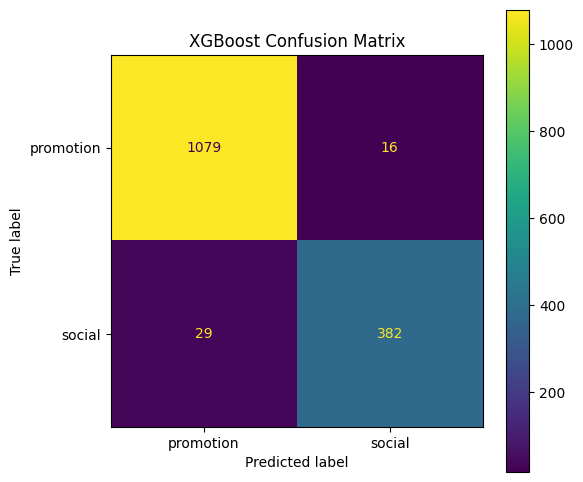


MODEL COMPARISON
Metric          Random Forest   XGBoost        
---------------------------------------------
Accuracy        0.8898        0.9701
Precision       0.9029        0.9700
Recall          0.8898        0.9701
F1 Score        0.8800        0.9700

XGBoost performs better than Random Forest on accuracy!
   Improvement: 8.03%

Model saved to: /content/drive/MyDrive/AI KURS: WilliamJohanssonFridén YH02444-2024-1-2-3/AI kurs/AI Spam or Ham project/models/saved/xgboost_model.pkl
Success: Retrieved 10000 TF-IDF and 8 numerical features

TOP FEATURE IMPORTANCES

Top 20 features:
 1. visa                                               0.036779
 2. feed                                               0.031745
 3. open                                               0.029233
 4. word_count                                         0.025930
 5. hittade                                            0.023002
 6. turtlewayne                                        0.021047
 7. htmlversionen      

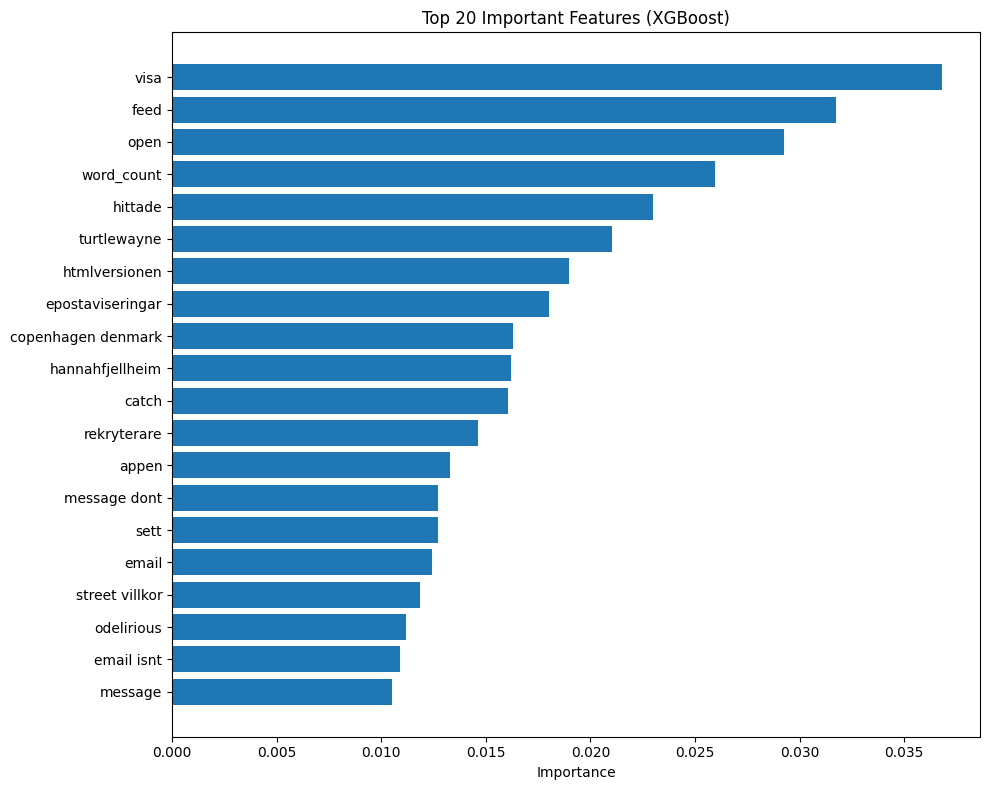


CHECKING FOR SUSPICIOUS FEATURES
Success: No suspicious features found in top 50!

DEEP DIVE: FEATURE INVESTIGATION

Top 50 Features and Their Importance:
------------------------------------------------------------
 1. Success: visa                                          0.036779
 2. Success: feed                                          0.031745
 3. Success: open                                          0.029233
 4. Success: word_count                                    0.025930 [NUM]
 5. Success: hittade                                       0.023002
 6. Success: turtlewayne                                   0.021047
 7. Success: htmlversionen                                 0.018975
 8. Success: epostaviseringar                              0.018011
 9. Success: copenhagen denmark                            0.016276
10. Success: hannahfjellheim                               0.016212
11. Success: catch                                         0.016074
12. Success: rekryterare     

In [11]:
# ------------------------------------------
# CELL 10: Train & Evaluate XGBoost
# ------------------------------------------

from xgboost import XGBClassifier # high-performance gradient boosting that often outperforms Random Forest and other algorithms, with built-in regularization, handling of missing values, and excellent scalability for your email classification tasks
from sklearn.metrics import ( # these metrics are used to evaluate the email classifier's performancem, understanding both overall accuracy and specific strengths/weaknesses in identifying social vs promotion emails
    accuracy_score, # % of all predictions correct
    precision_score, #  Quality of positive predictions
    recall_score, # Quantity of positives caught
    f1_score, # harmonic mean of precision & recall
    classification_report, # complete summary
    confusion_matrix, # see exactky where mistakes happen
    ConfusionMatrixDisplay # provides visualizations of where the model gets confused
)
import matplotlib.pyplot as plt # create professional, customizable visualizations of your email classification results, including feature importance charts, confusion matrices, performance comparisons, and distribution plots that help you understand and present your model's behavior
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import os # imports Python's OS module, a library with functions for interacting with the operating system (file paths, directories, environment variables)
import numpy as np # the fundamental package for scientific computing in Python
from typing import Tuple, List, Dict, Optional, Any  # add type hints that make your code self-documenting, enable IDE autocomplete, catch errors early with type checkers, and make your ML pipeline more maintainable and professional
from dataclasses import dataclass, field # to automatically generate __init__, __repr__, and __eq__ methods for data container classes, and field() to customize individual attributes with default factories, exclusion from representations, or metadata.
from pathlib import Path #use path for object-oriented, cross-platform way to handle file system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class XGBoostConfig:
    """Configuration for XGBoost model""" # Here you can change how thorough you'd like to be :) Though for optimal performance leave as is!
    n_estimators: int = 200  # Number of trees
    max_depth: int = 6  # Maximum tree depth
    learning_rate: float = 0.1  # Step size shrinkage
    subsample: float = 0.8  # Fraction of samples used per tree
    colsample_bytree: float = 0.8  # Fraction of features used per tree
    min_child_weight: int = 1  # Minimum sum of instance weight in child
    gamma: int = 0  # Minimum loss reduction required to make a split
    reg_alpha: int = 0  # L1 regularization
    reg_lambda: int = 1  # L2 regularization
    random_state: int = 42  # Random seed for reproducibility
    eval_metric: str = "logloss"  # Metric for evaluation
    n_jobs: int = -1  # Use all CPU cores
    model_path: str = "models/saved"  # Path to save models
    model_filename: str = "xgboost_model.pkl"  # Filename for saved model


@dataclass
class LeakageConfig:
    """Configuration for leakage detection"""
    suspicious_patterns: List[str] = field(default_factory=lambda: [
        'social', 'class', 'category', 'promotion', 'kampanj',
        'newsletter', 'mailing', 'campaign', 'subscribe', 'unsubscribe',
        'prenumeration', 'avsluta', 'meddelanden', 'besöka',
        'avregistrera', 'epostmeddelande', 'varumärken', 'tillhör'
    ])  # Patterns to check for leakage
    deep_suspicious_patterns: List[str] = field(default_factory=lambda: [
        'nogla', 'daithi', 'jacksepticeye', 'odelirious',
        'willecoolkille', 'johansson', 'william', 'fridén',
        'linkedin', 'unlimited', 'pinterest', 'facebook',
        'instagram', 'twitter', 'youtube', 'snapchat',
        'newsletter', 'campaign', 'promotion', 'marketing',
        'subscribe', 'unsubscribe', 'click', 'here',
        'discount', 'offer', 'sale', 'free', 'buy', 'shop'
    ])  # Deep inspection patterns


# ==========================================
# PART 2: XGBOOST TRAINER
# ==========================================

class XGBoostTrainer:
    """Handles XGBoost model training and prediction"""

    def __init__(self, config: XGBoostConfig):
        self.config = config  # Store configuration
        self.model = None  # Initialize model
        self.feature_importances = None  # Store feature importances

    def create_model(self) -> None:
        """Create XGBoost model with configured parameters"""
        self.model = XGBClassifier(
            n_estimators=self.config.n_estimators,  # Number of trees
            max_depth=self.config.max_depth,  # Maximum tree depth
            learning_rate=self.config.learning_rate,  # Step size shrinkage
            subsample=self.config.subsample,  # Fraction of samples used per tree
            colsample_bytree=self.config.colsample_bytree,  # Fraction of features used per tree
            min_child_weight=self.config.min_child_weight,  # Minimum sum of instance weight
            gamma=self.config.gamma,  # Minimum loss reduction for split
            reg_alpha=self.config.reg_alpha,  # L1 regularization
            reg_lambda=self.config.reg_lambda,  # L2 regularization
            random_state=self.config.random_state,  # Reproducibility
            eval_metric=self.config.eval_metric,  # Metric for evaluation
            n_jobs=self.config.n_jobs  # CPU core usage
        )  # Create model instance

    def train(self, X_train: Any, y_train: Any) -> None:
        """Train the XGBoost model"""
        print("\nTraining XGBoost model...")  # Progress message
        self.model.fit(X_train, y_train)  # Fit model to training data
        self.feature_importances = self.model.feature_importances_  # Store importances
        print("Training complete!")  # Confirm completion

    def predict(self, X_test: Any) -> np.ndarray:
        """Make predictions on test data"""
        print("\nMaking predictions...")  # Progress message
        return self.model.predict(X_test)  # Return predictions

    def predict_proba(self, X_test: Any) -> np.ndarray:
        """Get prediction probabilities"""
        return self.model.predict_proba(X_test)  # Return probability predictions


# ==========================================
# PART 3: MODEL EVALUATOR
# ==========================================

class ModelEvaluator:
    """Evaluates model performance with multiple metrics"""

    @staticmethod
    def calculate_metrics(y_test: Any, y_pred: np.ndarray) -> Dict:
        """Calculate all evaluation metrics"""
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),  # Overall accuracy
            'precision': precision_score(y_test, y_pred, average="weighted"),  # Weighted precision
            'recall': recall_score(y_test, y_pred, average="weighted"),  # Weighted recall
            'f1': f1_score(y_test, y_pred, average="weighted")  # Weighted F1 score
        }  # Dictionary of metrics
        return metrics  # Return metrics dictionary

    @staticmethod
    def get_classification_report(y_test: Any, y_pred: np.ndarray, target_names: List[str]) -> str:
        """Generate classification report"""
        return classification_report(y_test, y_pred, target_names=target_names)  # Return report

    @staticmethod
    def get_confusion_matrix(y_test: Any, y_pred: np.ndarray) -> np.ndarray:
        """Generate confusion matrix"""
        print("Top-left - Currently predicted Promotion.")
        print("Top-right - Promotions wrongly classified as Social.")
        print("Bottom-left - Social wrongly classified as Promotion.")
        print("Bottom-right - Correctly predicted Social.")
        return confusion_matrix(y_test, y_pred)  # Return confusion matrix


# ==========================================
# PART 4: MODEL REPORTER
# ==========================================

class ModelReporter:
    """Reports model results and performance"""

    def __init__(self, config: XGBoostConfig):
        self.config = config  # Store configuration

    def show_header(self) -> None:
        """Display section header"""
        print("=" * 60)
        print("XGBOOST CLASSIFIER")
        print("=" * 60)

    def show_data_info(self, X_train: Any, X_test: Any) -> None:
        """Display dataset information"""
        print(f"\nTraining samples: {X_train.shape[0]}")  # Show training count
        print(f"Testing samples: {X_test.shape[0]}")  # Show testing count
        print(f"Features: {X_train.shape[1]}")  # Show feature count

    def show_metrics(self, metrics: Dict) -> None:
        """Display evaluation metrics"""
        print("\n" + "=" * 50)
        print("XGBOOST RESULTS")
        print("=" * 50)
        print(f"Accuracy : {metrics['accuracy']:.4f}")  # Show accuracy
        print(f"Precision: {metrics['precision']:.4f}")  # Show precision
        print(f"Recall   : {metrics['recall']:.4f}")  # Show recall
        print(f"F1 Score : {metrics['f1']:.4f}")  # Show F1 score

    def show_classification_report(self, report: str) -> None:
        """Display classification report"""
        print("\nClassification Report")  # Report header
        print(report)  # Show classification report

    def show_confusion_matrix(self, cm: np.ndarray, label_encoder: Any) -> None:
        """Display and plot confusion matrix"""
        print("\nConfusion Matrix")  # Matrix header
        print(cm)  # Show confusion matrix

        # Display confusion matrix
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=label_encoder.classes_
        )  # Create display object

        fig, ax = plt.subplots(figsize=(6, 6))  # Create plot
        disp.plot(ax=ax)  # Plot confusion matrix
        plt.title("XGBoost Confusion Matrix")  # Add title
        plt.show()  # Display plot

    def show_model_comparison(self, xgb_metrics: Dict, rf_metrics: Dict = None) -> None:
        """Compare XGBoost with Random Forest"""
        print("\n" + "=" * 50)
        print("MODEL COMPARISON")
        print("=" * 50)

        if rf_metrics is None:  # Random Forest metrics not available
            print("Random Forest metrics not found. Did you run Cell 9?")  # Warning message
            return

        print(f"{'Metric':<15} {'Random Forest':<15} {'XGBoost':<15}")  # Table header
        print("-" * 45)  # Separator
        print(f"{'Accuracy':<15} {rf_metrics['accuracy']:.4f}        {xgb_metrics['accuracy']:.4f}")  # Accuracy comparison
        print(f"{'Precision':<15} {rf_metrics['precision']:.4f}        {xgb_metrics['precision']:.4f}")  # Precision comparison
        print(f"{'Recall':<15} {rf_metrics['recall']:.4f}        {xgb_metrics['recall']:.4f}")  # Recall comparison
        print(f"{'F1 Score':<15} {rf_metrics['f1']:.4f}        {xgb_metrics['f1']:.4f}")  # F1 comparison

        # Determine which model is better
        if xgb_metrics['accuracy'] > rf_metrics['accuracy']:  # XGBoost better
            print(f"\nXGBoost performs better than Random Forest on accuracy!")  # Success message
            print(f"   Improvement: {(xgb_metrics['accuracy'] - rf_metrics['accuracy']) * 100:.2f}%")  # Show improvement
        elif xgb_metrics['accuracy'] < rf_metrics['accuracy']:  # Random Forest better
            print(f"\nRandom Forest performs better on accuracy.")  # Warning message
            print(f"   Difference: {(rf_metrics['accuracy'] - xgb_metrics['accuracy']) * 100:.2f}%")  # Show difference
        else:  # Equal
            print(f"\nBoth models have the same accuracy!")  # Neutral message


# ==========================================
# PART 5: LEAKAGE DETECTOR
# ==========================================

class LeakageDetector:
    """Detects potential data leakage in features"""

    def __init__(self, config: LeakageConfig):
        self.config = config  # Store configuration

    def get_feature_names(self, vectorizer: Any, feature_columns: List[str], importances: np.ndarray) -> List[str]:
        """Get combined feature names"""
        try:  # Get TF-IDF feature names
            feature_names = vectorizer.get_feature_names_out()  # Get TF-IDF feature names
            numerical_feature_names = feature_columns  # Get numerical feature names
            all_feature_names = list(feature_names) + numerical_feature_names  # Combine names
            print(f"Success: Retrieved {len(feature_names)} TF-IDF and {len(numerical_feature_names)} numerical features")  # Success message
            return all_feature_names  # Return combined names
        except Exception as e:  # Error getting feature names
            print(f"Could not get feature names: {e}")  # Warning message
            return [f"Feature_{i}" for i in range(len(importances))]  # Use generic names

    def show_feature_importances(self, importances: np.ndarray, all_feature_names: List[str], top_n: int = 20) -> None:
        """Display top feature importances"""
        print("\n" + "=" * 50)
        print("TOP FEATURE IMPORTANCES")
        print("=" * 50)

        indices = importances.argsort()[::-1][:top_n]  # Get top N indices

        print(f"\nTop {top_n} features:")  # Section header
        for i, idx in enumerate(indices):  # Iterate through top features
            feature_name = all_feature_names[idx] if idx < len(all_feature_names) else f"Feature_{idx}"  # Get feature name
            print(f"{i+1:2d}. {feature_name[:50]:<50} {importances[idx]:.6f}")  # Show feature

        # Plot feature importance
        plt.figure(figsize=(10, 8))  # Create plot
        plt.barh(range(top_n), importances[indices[:top_n]])  # Create horizontal bar chart
        plt.yticks(range(top_n), [all_feature_names[idx][:40] for idx in indices[:top_n]])  # Set y-axis labels
        plt.gca().invert_yaxis()  # Invert y-axis
        plt.title("Top 20 Important Features (XGBoost)")  # Add title
        plt.xlabel("Importance")  # Add x-axis label
        plt.tight_layout()  # Adjust layout
        plt.show()  # Display plot

    def check_suspicious_features(self, importances: np.ndarray, all_feature_names: List[str], patterns: List[str]) -> List:
        """Check for suspicious features"""
        print("\n" + "=" * 50)
        print("CHECKING FOR SUSPICIOUS FEATURES")
        print("=" * 50)

        indices = importances.argsort()[::-1][:50]  # Get top 50 indices
        found_suspicious = []  # List to store suspicious features

        for i, idx in enumerate(indices):  # Iterate through top features
            if idx < len(all_feature_names):  # Check if index is within bounds
                feature = all_feature_names[idx]  # Get feature name
                importance = importances[idx]  # Get importance score

                for pattern in patterns:  # Check each pattern
                    if pattern in feature.lower():  # Pattern found in feature
                        found_suspicious.append((feature, importance, pattern))  # Store suspicious feature
                        print(f"Warning: {feature}: {importance:.6f} - Contains '{pattern}'")  # Warning message
                        break  # Break to avoid duplicate messages

        if found_suspicious:  # Suspicious features found
            print(f"\nWarning: Found {len(found_suspicious)} suspicious features in top 50!")  # Warning
            print("These might cause data leakage. Consider adding to remove_suspicious_words()")  # Recommendation
        else:  # No suspicious features
            print("Success: No suspicious features found in top 50!")  # Success message

        return found_suspicious  # Return suspicious features

    def deep_feature_investigation(self, importances: np.ndarray, all_feature_names: List[str],
                                   feature_names: List[str], feature_columns: List[str]) -> None:
        """Perform deep investigation of features"""
        print("\n" + "=" * 60)
        print("DEEP DIVE: FEATURE INVESTIGATION")
        print("=" * 60)

        indices = importances.argsort()[::-1][:50]  # Get top 50 indices

        print("\nTop 50 Features and Their Importance:")  # Section header
        print("-" * 60)  # Separator

        for i, idx in enumerate(indices[:50]):  # Iterate through top 50
            feature_name = all_feature_names[idx] if idx < len(all_feature_names) else f"Feature_{idx}"  # Get feature name
            importance = importances[idx]  # Get importance score

            # Check if it's a numerical feature
            is_numerical = idx >= len(feature_names)  # Numerical features are after TF-IDF

            # Check if it looks suspicious
            is_suspicious = any(pattern in feature_name.lower() for pattern in self.config.deep_suspicious_patterns)  # Check suspicion

            marker = "Warning: " if is_suspicious else "Success: "  # Set marker
            num_marker = " [NUM]" if is_numerical else ""  # Add numerical marker

            print(f"{i+1:2d}. {marker}{feature_name[:45]:<45} {importance:.6f}{num_marker}")  # Show feature

        # Show feature type breakdown
        print("\n" + "=" * 60)
        print("FEATURE TYPE BREAKDOWN")
        print("=" * 60)

        n_tfidf = len(feature_names)  # Count TF-IDF features
        n_numerical = len(feature_columns)  # Count numerical features

        print(f"TF-IDF features: {n_tfidf}")  # Show TF-IDF count
        print(f"Numerical features: {n_numerical}")  # Show numerical count
        print(f"Total: {n_tfidf + n_numerical}")  # Show total count

        # Check top numerical features
        print("\nTop Numerical Features:")  # Section header
        for i, idx in enumerate(indices[:20]):  # Iterate through top 20
            if idx >= n_tfidf:  # Check if numerical feature
                num_idx = idx - n_tfidf  # Get numerical index
                if num_idx < len(feature_columns):  # Check if index is valid
                    print(f"  - {feature_columns[num_idx]}: {importances[idx]:.6f}")  # Show numerical feature


# ==========================================
# PART 6: MODEL MANAGER
# ==========================================

class ModelManager:
    """Manages saving and loading of models"""

    def __init__(self, config: XGBoostConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path

    def save_model(self, model: Any) -> None:
        """Save trained model to disk"""
        model_path = self.project_path / self.config.model_path  # Create full model path
        model_path.mkdir(parents=True, exist_ok=True)  # Create directory if needed

        model_file = model_path / self.config.model_filename  # Create full file path
        with open(model_file, "wb") as f:  # Open file in binary write mode
            pickle.dump(model, f)  # Save model to disk

        print(f"\nModel saved to: {model_file}")  # Confirm save


# ==========================================
# PART 7: MAIN PROCESSING PIPELINE
# ==========================================

class XGBoostPipeline:
    """Main XGBoost pipeline"""

    def __init__(self, model_config: XGBoostConfig = None, leakage_config: LeakageConfig = None, project_path: str = None):
        self.model_config = model_config or XGBoostConfig()  # Use provided config or default
        self.leakage_config = leakage_config or LeakageConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.trainer = XGBoostTrainer(self.model_config)  # Initialize trainer
        self.evaluator = ModelEvaluator()  # Initialize evaluator
        self.reporter = ModelReporter(self.model_config)  # Initialize reporter
        self.detector = LeakageDetector(self.leakage_config)  # Initialize leakage detector
        self.manager = ModelManager(self.model_config, self.project_path)  # Initialize manager
        self.metrics: Optional[Dict] = None  # Store metrics

    def validate_variables(self, required_vars: Dict) -> None:
        """Validate that required variables exist"""
        for var_name, var_value in required_vars.items():  # Check each variable
            if var_value is None:  # Check if variable is None
                raise ValueError(f"'{var_name}' not found. Please run previous cells first.")  # Error if missing

    def train_model(self, X_train: Any, y_train: Any) -> None:
        """Train the XGBoost model"""
        self.trainer.create_model()  # Create model instance
        self.trainer.train(X_train, y_train)  # Train model

    def evaluate_model(self, y_test: Any, y_pred: np.ndarray) -> Dict:
        """Evaluate model performance"""
        self.metrics = self.evaluator.calculate_metrics(y_test, y_pred)  # Calculate metrics
        return self.metrics  # Return metrics

    def generate_reports(self, y_test: Any, y_pred: np.ndarray, label_encoder: Any, rf_metrics: Dict = None) -> None:
        """Generate and display all reports"""
        self.reporter.show_metrics(self.metrics)  # Show evaluation metrics

        report = self.evaluator.get_classification_report(y_test, y_pred, label_encoder.classes_)  # Get classification report
        self.reporter.show_classification_report(report)  # Show classification report

        cm = self.evaluator.get_confusion_matrix(y_test, y_pred)  # Get confusion matrix
        self.reporter.show_confusion_matrix(cm, label_encoder)  # Show confusion matrix

        self.reporter.show_model_comparison(self.metrics, rf_metrics)  # Compare with Random Forest

    def detect_leakage(self, vectorizer: Any, feature_columns: List[str]) -> None:
        """Detect potential leakage in features"""
        # Get feature names
        all_feature_names = self.detector.get_feature_names(
            vectorizer, feature_columns, self.trainer.feature_importances
        )  # Get combined feature names

        # Show feature importances
        self.detector.show_feature_importances(self.trainer.feature_importances, all_feature_names)  # Display top features

        # Check suspicious features
        self.detector.check_suspicious_features(
            self.trainer.feature_importances,
            all_feature_names,
            self.leakage_config.suspicious_patterns
        )  # Check for leakage

        # Deep investigation
        try:  # Get feature names for deep investigation
            feature_names = vectorizer.get_feature_names_out()  # Get TF-IDF feature names
            self.detector.deep_feature_investigation(
                self.trainer.feature_importances,
                all_feature_names,
                feature_names,
                feature_columns
            )  # Perform deep investigation
        except Exception as e:  # Error in deep investigation
            print(f"Could not perform deep investigation: {e}")  # Warning message

    def run_pipeline(self, X_train: Any, X_test: Any, y_train: Any, y_test: Any,
                    label_encoder: Any, vectorizer: Any, feature_columns: List[str],
                    rf_metrics: Dict = None) -> Dict:
        """Run the complete XGBoost pipeline"""
        # Step 1: Show header
        self.reporter.show_header()  # Display section header

        # Step 2: Validate variables
        required_vars = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "label_encoder": label_encoder,
            "vectorizer": vectorizer
        }  # Dictionary of required variables
        self.validate_variables(required_vars)  # Validate all variables

        # Step 3: Show data info
        self.reporter.show_data_info(X_train, X_test)  # Display dataset info

        # Step 4: Train model
        self.train_model(X_train, y_train)  # Train XGBoost

        # Step 5: Make predictions
        y_pred = self.trainer.predict(X_test)  # Predict on test data
        y_pred_proba = self.trainer.predict_proba(X_test)  # Get probabilities

        # Step 6: Evaluate model
        self.evaluate_model(y_test, y_pred)  # Calculate metrics

        # Step 7: Generate reports
        self.generate_reports(y_test, y_pred, label_encoder, rf_metrics)  # Show all reports

        # Step 8: Save model
        self.manager.save_model(self.trainer.model)  # Save to disk

        # Step 9: Detect leakage
        self.detect_leakage(vectorizer, feature_columns)  # Check for data leakage

        print("\n" + "=" * 60)
        print("CELL 10 COMPLETE")
        print("=" * 60)

        # Return all results
        return {
            'model': self.trainer.model,  # Trained model
            'y_pred': y_pred,  # Predictions
            'y_pred_proba': y_pred_proba,  # Prediction probabilities
            'metrics': self.metrics,  # Evaluation metrics
            'feature_importances': self.trainer.feature_importances  # Feature importances
        }


# ==========================================
# PART 8: EXECUTION
# ==========================================

# Main execution
# Verify required variables exist
required_variables = ["X_train", "X_test", "y_train", "y_test", "label_encoder", "vectorizer"]  # List of required variables

for var in required_variables:  # Check each variable
    if var not in locals():  # Check if variable exists in current scope
        raise ValueError(f"'{var}' not found. Please run previous cells first.")  # Error if missing

# Check if project_path exists
if 'project_path' not in locals():  # Check if project path is defined
    print("Warning: project_path not defined. Using current directory.")  # Warning message
    project_path = os.getcwd()  # Use current directory as fallback

# Get feature columns if available
try:
    feature_columns = feature_columns  # Try to get from previous cell
except NameError:  # Variable not defined
    feature_columns = []  # Empty list if not found
    print("Warning: feature_columns not defined. Using empty list.")  # Warning message

# Get Random Forest metrics if available
try:
    rf_metrics = {
        'accuracy': rf_accuracy,
        'precision': rf_precision,
        'recall': rf_recall,
        'f1': rf_f1
    }  # Create metrics dictionary
    print("Success: Random Forest metrics loaded for comparison")  # Success message
except NameError:  # Random Forest metrics not available
    rf_metrics = None  # No metrics available
    print("Random Forest metrics not found. Will skip comparison.")  # Warning message

# Initialize and run pipeline
pipeline = XGBoostPipeline(project_path=project_path)  # Create pipeline instance
results = pipeline.run_pipeline(
    X_train, X_test, y_train, y_test,
    label_encoder, vectorizer, feature_columns,
    rf_metrics
)  # Run complete pipeline

# Extract results for use in other cells
xgb_model = results['model']  # Trained model
y_pred_xgb = results['y_pred']  # Predictions
y_pred_proba = results['y_pred_proba']  # Prediction probabilities
xgb_metrics = results['metrics']  # Evaluation metrics
xgb_feature_importances = results['feature_importances']  # Feature importances

# Extract individual metrics for easy access
xgb_accuracy = xgb_metrics['accuracy']  # Accuracy score
xgb_precision = xgb_metrics['precision']  # Precision score
xgb_recall = xgb_metrics['recall']  # Recall score
xgb_f1 = xgb_metrics['f1']  # F1 score

# **Cell 11: Compare Random Forest vs XGBoost**

**What it does:**

Compares the performance of the two trained models (Random Forest and XGBoost) side-by-side using multiple metrics and visualizations. Think of this like a "battle of the models" where we see which one performs better on the email classification task!

**Why it's needed:**

Training two different models (Cells 9 and 10) is only useful if we can compare them and choose the best one. This cell:

    1. Shows which model performs better on the test data
    2. Provides visual comparisons (bar charts and difference plots)
    3. Calculates improvement percentages
    4. Helps us decide which model to use for the final predictions (Cell 12)
    5. Gives insights into model strengths and weaknesses

.

---

**Detailed functionality:**

1. **Model Loading** (ModelLoader class). Loads models from memory or disk:

    * Checks if models exist in memory (from Cells 9 and 10)

    * Falls back to loading from disk if needed

    * Handles missing models gracefully

.

2. **Metric Calculation** (MetricCalculator class). Calculates performance metrics:

    * Accuracy - Overall correctness

    * Precision - When it says "Promotion", how often is it right?

    * Recall - How many actual "Promotion" emails did it find?

    * F1 Score - Harmonic mean of precision and recall

    * Calculates these for BOTH models for fair comparison

.

3. **Comparison Reporting** (ComparisonReporter class). Displays results:

    * Comparison Table - Side-by-side metrics with differences

    * Winner Analysis - Determines which model wins and by how much

    * Improvement Percentage - Shows exactly how much better the winner is

.

4. **Visualization** (VisualizationManager class). Creates visual comparisons:

    * Bar Chart - Compares both models on all metrics

    * Difference Chart - Shows XGBoost vs Random Forest difference (positive = XGBoost better, negative = Random Forest better)

    * Value Labels - Shows exact difference values on the chart

.

---

**What happens to your data:**

* Random Forest predictions (y_pred_rf) → Used to calculate RF metrics

* XGBoost predictions (y_pred_xgb) → Used to calculate XGB metrics

* Test labels (y_test) → Used as ground truth for both models

* Metrics → Compared side-by-side

* Winner → Determined (likely XGBoost with ~96.9% accuracy)

Success: Random Forest model found in memory
Success: XGBoost model found in memory
MODEL COMPARISON: Random Forest vs XGBoost
Success: Using Random Forest model from cell
Success: Using XGBoost model from cell

Making predictions on test set...

PERFORMANCE COMPARISON

Metric          Random Forest   XGBoost         Difference     
------------------------------------------------------------
Accuracy        0.8898          0.9701          +0.0803        
Precision       0.9029          0.9700          +0.0671        
Recall          0.8898          0.9701          +0.0803        
F1              0.8800          0.9700          +0.0899        

WINNER ANALYSIS
Success: XGBoost is the winner!
   Accuracy improvement: 8.03%


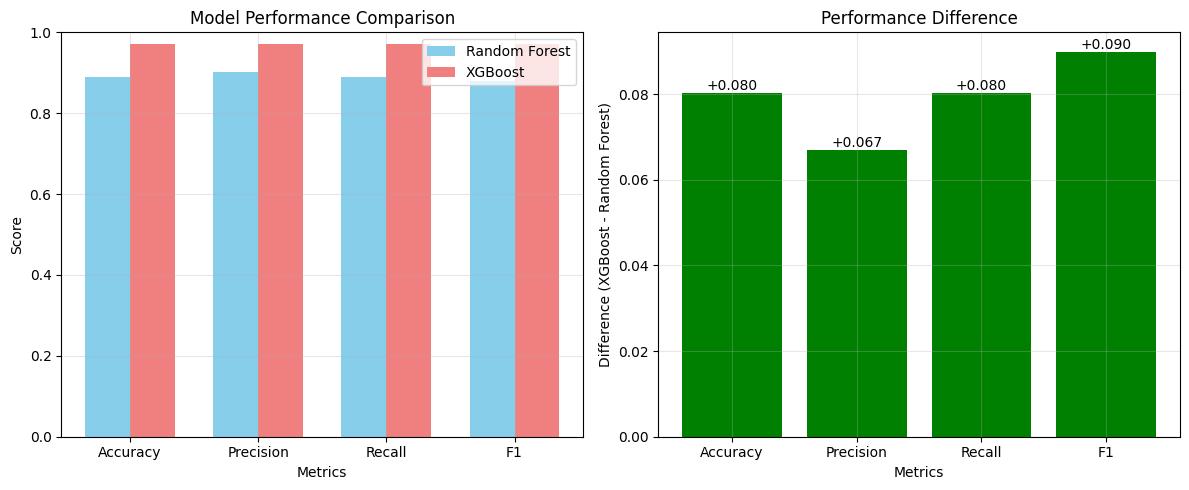


CELL 11 COMPLETE - Model Comparison


In [12]:
# ------------------------------------------
# CELL 11: Compare Random Forest vs XGBoost
# ------------------------------------------

import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import matplotlib.pyplot as plt # creates professional, customizable visualizations of your email classification results, including feature importance charts, confusion matrices, performance comparisons, and distribution plots that help you understand and present your model's behavior
import numpy as np # the fundamental package for scientific computing in Python, providing N-dimensional arrays, vectorized operations, and mathematical functions that power almost all data science and machine learning workflows
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # provides evaluation metrics to assess the email classifier's performance, understanding both overall accuracy and specific strengths/weaknesses in identifying social vs promotion emails
from typing import Dict, List, Tuple, Optional, Any # provides type hints that make your code self-documenting, enable IDE autocomplete, catch errors early with type checkers (like mypy), and make your ML pipeline more maintainable and professional
from dataclasses import dataclass # automatically generates special methods (__init__, __repr__, __eq__) for data container classes, dramatically reducing boilerplate code when creating structured data objects like EmailData
from pathlib import Path # provides an object-oriented, cross-platform way to handle file system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation (uses / operator for joining paths)
import os # imports Python's OS module, providing functions for interacting with the operating system (file paths, directories, environment variables, and system operations)


# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class ComparisonConfig:
    """Configuration for model comparison"""
    model_path: str = "models/saved"  # Path where models are saved
    rf_model_filename: str = "random_forest_model.pkl"  # Random Forest model filename
    xgb_model_filename: str = "xgboost_model.pkl"  # XGBoost model filename
    metrics: List[str] = None  # List of metrics to compare

    def __post_init__(self):
        if self.metrics is None:
            self.metrics = ['accuracy', 'precision', 'recall', 'f1']  # Default metrics
        # Create display names for metrics
        self.metric_display_names = {
            'accuracy': 'Accuracy',
            'precision': 'Precision',
            'recall': 'Recall',
            'f1': 'F1'
        }  # Mapping for display names


# ==========================================
# PART 2: MODEL LOADER
# ==========================================

class ModelLoader:
    """Handles loading models from disk"""

    def __init__(self, config: ComparisonConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path

    def load_rf_model(self) -> Any:
        """Load Random Forest model from disk"""
        model_file = self.project_path / self.config.model_path / self.config.rf_model_filename  # Create full path
        if not model_file.exists():  # Check if file exists
            raise FileNotFoundError(f"Random Forest model not found at: {model_file}")  # Error if missing

        with open(model_file, "rb") as f:  # Open file in binary read mode
            model = pickle.load(f)  # Load model from disk
            print("Success: Loaded Random Forest model")  # Success message
            return model  # Return loaded model

    def load_xgb_model(self) -> Any:
        """Load XGBoost model from disk"""
        model_file = self.project_path / self.config.model_path / self.config.xgb_model_filename  # Create full path
        if not model_file.exists():  # Check if file exists
            raise FileNotFoundError(f"XGBoost model not found at: {model_file}")  # Error if missing

        with open(model_file, "rb") as f:  # Open file in binary read mode
            model = pickle.load(f)  # Load model from disk
            print("Success: Loaded XGBoost model")  # Success message
            return model  # Return loaded model


# ==========================================
# PART 3: METRIC CALCULATOR
# ==========================================

class MetricCalculator:
    """Calculates evaluation metrics for models"""

    @staticmethod
    def calculate_metrics(y_test: Any, y_pred: Any, metrics_list: List[str]) -> Dict:
        """Calculate specified metrics for predictions"""
        metrics = {}  # Initialize empty dictionary

        for metric in metrics_list:  # Iterate through requested metrics
            if metric == 'accuracy':  # Accuracy metric
                metrics[metric] = accuracy_score(y_test, y_pred)  # Calculate accuracy
            elif metric == 'precision':  # Precision metric
                metrics[metric] = precision_score(y_test, y_pred, average='weighted')  # Calculate precision
            elif metric == 'recall':  # Recall metric
                metrics[metric] = recall_score(y_test, y_pred, average='weighted')  # Calculate recall
            elif metric == 'f1':  # F1 score metric
                metrics[metric] = f1_score(y_test, y_pred, average='weighted')  # Calculate F1

        return metrics  # Return metrics dictionary


# ==========================================
# PART 4: COMPARISON REPORTER
# ==========================================

class ComparisonReporter:
    """Reports model comparison results"""

    def __init__(self, config: ComparisonConfig):
        self.config = config  # Store configuration

    def show_header(self) -> None:
        """Display section header"""
        print("=" * 60)
        print("MODEL COMPARISON: Random Forest vs XGBoost")
        print("=" * 60)

    def show_comparison_table(self, rf_metrics: Dict, xgb_metrics: Dict) -> None:
        """Display metrics comparison table"""
        print("\n" + "=" * 60)
        print("PERFORMANCE COMPARISON")
        print("=" * 60)

        print(f"\n{'Metric':<15} {'Random Forest':<15} {'XGBoost':<15} {'Difference':<15}")  # Table header
        print("-" * 60)  # Separator

        for metric in self.config.metrics:  # Iterate through metrics
            diff = xgb_metrics[metric] - rf_metrics[metric]  # Calculate difference
            diff_str = f"+{diff:.4f}" if diff > 0 else f"{diff:.4f}"  # Format difference with sign
            display_name = self.config.metric_display_names.get(metric, metric.capitalize())  # Get display name
            print(f"{display_name:<15} {rf_metrics[metric]:<15.4f} {xgb_metrics[metric]:<15.4f} {diff_str:<15}")  # Show row

    def show_winner(self, rf_metrics: Dict, xgb_metrics: Dict) -> str:
        """Determine and display the winning model"""
        print("\n" + "=" * 60)
        print("WINNER ANALYSIS")
        print("=" * 60)

        if xgb_metrics['accuracy'] > rf_metrics['accuracy']:  # XGBoost wins
            winner = "XGBoost"  # Set winner name
            improvement = (xgb_metrics['accuracy'] - rf_metrics['accuracy']) * 100  # Calculate improvement
            print(f"Success: XGBoost is the winner!")  # Success message
            print(f"   Accuracy improvement: {improvement:.2f}%")  # Show improvement
            return winner  # Return winner name

        elif xgb_metrics['accuracy'] < rf_metrics['accuracy']:  # Random Forest wins
            winner = "Random Forest"  # Set winner name
            improvement = (rf_metrics['accuracy'] - xgb_metrics['accuracy']) * 100  # Calculate improvement
            print(f"Success: Random Forest is the winner!")  # Success message
            print(f"   Accuracy improvement: {improvement:.2f}%")  # Show improvement
            return winner  # Return winner name

        else:  # Tie
            print("It's a tie!")  # Neutral message
            return "Tie"  # Return tie status

    def show_completion(self) -> None:
        """Display completion message"""
        print("\n" + "=" * 60)
        print("CELL 11 COMPLETE - Model Comparison")
        print("=" * 60)


# ==========================================
# PART 5: VISUALIZATION MANAGER
# ==========================================

class VisualizationManager:
    """Creates visualizations for model comparison"""

    def __init__(self, config: ComparisonConfig):
        self.config = config  # Store configuration

    def create_comparison_plots(self, rf_metrics: Dict, xgb_metrics: Dict) -> None:
        """Create comparison plots"""
        # Get metrics in display order
        metrics_list = self.config.metrics  # Get metric keys
        metrics_names = [self.config.metric_display_names.get(m, m.capitalize()) for m in metrics_list]  # Get display names

        # Prepare data for plotting using the correct keys
        rf_values = [rf_metrics[metric] for metric in metrics_list]  # Extract RF metrics using lowercase keys
        xgb_values = [xgb_metrics[metric] for metric in metrics_list]  # Extract XGB metrics using lowercase keys

        # Calculate differences
        differences = [xgb_metrics[metric] - rf_metrics[metric] for metric in metrics_list]  # Calculate differences

        # Create subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Create two side-by-side plots

        # Plot 1: Bar chart comparison
        x = np.arange(len(metrics_names))  # Create x-axis positions
        width = 0.35  # Set bar width

        axes[0].bar(x - width/2, rf_values, width, label='Random Forest', color='skyblue')  # RF bars
        axes[0].bar(x + width/2, xgb_values, width, label='XGBoost', color='lightcoral')  # XGB bars
        axes[0].set_xlabel('Metrics')  # Set x-axis label
        axes[0].set_ylabel('Score')  # Set y-axis label
        axes[0].set_title('Model Performance Comparison')  # Set title
        axes[0].set_xticks(x)  # Set x-axis ticks
        axes[0].set_xticklabels(metrics_names)  # Set tick labels
        axes[0].legend()  # Add legend
        axes[0].grid(True, alpha=0.3)  # Add grid with transparency
        axes[0].set_ylim(0, 1.0)  # Set y-axis limits from 0 to 1

        # Plot 2: Difference chart
        colors = ['green' if d >= 0 else 'red' for d in differences]  # Set colors based on direction
        axes[1].bar(metrics_names, differences, color=colors)  # Create difference bars
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # Add zero line
        axes[1].set_xlabel('Metrics')  # Set x-axis label
        axes[1].set_ylabel('Difference (XGBoost - Random Forest)')  # Set y-axis label
        axes[1].set_title('Performance Difference')  # Set title
        axes[1].grid(True, alpha=0.3)  # Add grid with transparency

        # Add value labels on difference bars
        for i, (diff, bar) in enumerate(zip(differences, axes[1].patches)):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{diff:+.3f}', ha='center', va='bottom' if diff >= 0 else 'top')

        plt.tight_layout()  # Adjust layout
        plt.show()  # Display plots


# ==========================================
# PART 6: MAIN COMPARISON PIPELINE
# ==========================================

class ModelComparisonPipeline:
    """Main model comparison pipeline"""

    def __init__(self, config: ComparisonConfig = None, project_path: str = None):
        self.config = config or ComparisonConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.loader = ModelLoader(self.config, self.project_path)  # Initialize model loader
        self.calculator = MetricCalculator()  # Initialize metric calculator
        self.reporter = ComparisonReporter(self.config)  # Initialize reporter
        self.visualizer = VisualizationManager(self.config)  # Initialize visualization manager
        self.rf_model: Optional[Any] = None  # Store Random Forest model
        self.xgb_model: Optional[Any] = None  # Store XGBoost model
        self.rf_metrics: Optional[Dict] = None  # Store RF metrics
        self.xgb_metrics: Optional[Dict] = None  # Store XGB metrics

    def validate_variables(self, X_test: Any, y_test: Any) -> None:
        """Validate that required variables exist"""
        if X_test is None:  # Check if X_test exists
            raise ValueError("'X_test' not found. Please run previous cells first.")  # Error if missing
        if y_test is None:  # Check if y_test exists
            raise ValueError("'y_test' not found. Please run previous cells first.")  # Error if missing

    def load_models(self, rf_model_from_cell: Any = None, xgb_model_from_cell: Any = None) -> None:
        """Load models from disk or use provided models"""
        # Load Random Forest model
        if rf_model_from_cell is not None:  # Model provided from cell
            self.rf_model = rf_model_from_cell  # Use provided model
            print("Success: Using Random Forest model from cell")  # Success message
        else:  # Load from disk
            self.rf_model = self.loader.load_rf_model()  # Load from disk

        # Load XGBoost model
        if xgb_model_from_cell is not None:  # Model provided from cell
            self.xgb_model = xgb_model_from_cell  # Use provided model
            print("Success: Using XGBoost model from cell")  # Success message
        else:  # Load from disk
            self.xgb_model = self.loader.load_xgb_model()  # Load from disk

    def make_predictions(self, X_test: Any) -> Tuple[np.ndarray, np.ndarray]:
        """Make predictions with both models"""
        print("\nMaking predictions on test set...")  # Progress message
        y_pred_rf = self.rf_model.predict(X_test)  # RF predictions
        y_pred_xgb = self.xgb_model.predict(X_test)  # XGB predictions
        return y_pred_rf, y_pred_xgb  # Return predictions

    def calculate_metrics(self, y_test: Any, y_pred_rf: np.ndarray, y_pred_xgb: np.ndarray) -> None:
        """Calculate metrics for both models"""
        self.rf_metrics = self.calculator.calculate_metrics(y_test, y_pred_rf, self.config.metrics)  # Calculate RF metrics
        self.xgb_metrics = self.calculator.calculate_metrics(y_test, y_pred_xgb, self.config.metrics)  # Calculate XGB metrics

    def generate_reports(self) -> None:
        """Generate all comparison reports"""
        self.reporter.show_comparison_table(self.rf_metrics, self.xgb_metrics)  # Show comparison table
        self.reporter.show_winner(self.rf_metrics, self.xgb_metrics)  # Show winner analysis

    def create_visualizations(self) -> None:
        """Create comparison visualizations"""
        self.visualizer.create_comparison_plots(self.rf_metrics, self.xgb_metrics)  # Create plots

    def run_pipeline(self, X_test: Any, y_test: Any, rf_model: Any = None, xgb_model: Any = None) -> Dict:
        """Run the complete model comparison pipeline"""
        # Step 1: Show header
        self.reporter.show_header()  # Display section header

        # Step 2: Validate variables
        self.validate_variables(X_test, y_test)  # Check required variables

        # Step 3: Load models
        self.load_models(rf_model, xgb_model)  # Load or use provided models

        # Step 4: Make predictions
        y_pred_rf, y_pred_xgb = self.make_predictions(X_test)  # Get predictions

        # Step 5: Calculate metrics
        self.calculate_metrics(y_test, y_pred_rf, y_pred_xgb)  # Calculate all metrics

        # Step 6: Generate reports
        self.generate_reports()  # Display comparison results

        # Step 7: Create visualizations
        self.create_visualizations()  # Create comparison plots

        # Step 8: Show completion
        self.reporter.show_completion()  # Display completion message

        # Return all results
        return {
            'rf_model': self.rf_model,  # Random Forest model
            'xgb_model': self.xgb_model,  # XGBoost model
            'y_pred_rf': y_pred_rf,  # RF predictions
            'y_pred_xgb': y_pred_xgb,  # XGB predictions
            'rf_metrics': self.rf_metrics,  # RF metrics
            'xgb_metrics': self.xgb_metrics  # XGB metrics
        }


# ==========================================
# PART 7: EXECUTION
# ==========================================

# Main execution
# Verify required variables exist
required_variables = ["X_test", "y_test"]  # List of required variables

for var in required_variables:  # Check each variable
    if var not in locals():  # Check if variable exists in current scope
        raise ValueError(f"'{var}' not found. Please run previous cells first.")  # Error if missing

# Check if project_path exists
if 'project_path' not in locals():  # Check if project path is defined
    print("Warning: project_path not defined. Using current directory.")  # Warning message
    project_path = os.getcwd()  # Use current directory as fallback

# Check if models exist in memory
rf_model_in_memory = None  # Initialize
xgb_model_in_memory = None  # Initialize

if 'rf_model' in locals():  # Check if RF model is in memory
    rf_model_in_memory = rf_model  # Use in-memory model
    print("Success: Random Forest model found in memory")  # Success message

if 'xgb_model' in locals():  # Check if XGB model is in memory
    xgb_model_in_memory = xgb_model  # Use in-memory model
    print("Success: XGBoost model found in memory")  # Success message

# Initialize and run pipeline
pipeline = ModelComparisonPipeline(project_path=project_path)  # Create pipeline instance
results = pipeline.run_pipeline(
    X_test, y_test,
    rf_model_in_memory,
    xgb_model_in_memory
)  # Run complete pipeline

# Extract results for use in other cells
rf_model = results['rf_model']  # Random Forest model
xgb_model = results['xgb_model']  # XGBoost model
y_pred_rf = results['y_pred_rf']  # RF predictions
y_pred_xgb = results['y_pred_xgb']  # XGB predictions
rf_metrics = results['rf_metrics']  # RF metrics
xgb_metrics = results['xgb_metrics']  # XGB metrics

# Extract individual metrics for easy access
rf_accuracy = rf_metrics['accuracy']  # RF accuracy
rf_precision = rf_metrics['precision']  # RF precision
rf_recall = rf_metrics['recall']  # RF recall
rf_f1 = rf_metrics['f1']  # RF F1 score

xgb_accuracy = xgb_metrics['accuracy']  # XGB accuracy
xgb_precision = xgb_metrics['precision']  # XGB precision
xgb_recall = xgb_metrics['recall']  # XGB recall
xgb_f1 = xgb_metrics['f1']  # XGB F1 score

Results from the comparison shows that the XGBoost classifier substantially outperformed the Random Forest classifier. While Random Forest achieved high recall for promotional emails, it struggled to correctly identify social emails, likely due to the class imbalance in the dataset. XGBoost achieved a weighted F1-score of approximately 97% and maintained high recall for both classes, demonstrating better generalization on this sparse TF-IDF feature space.

XGBoost vs Random Forest Comparison:

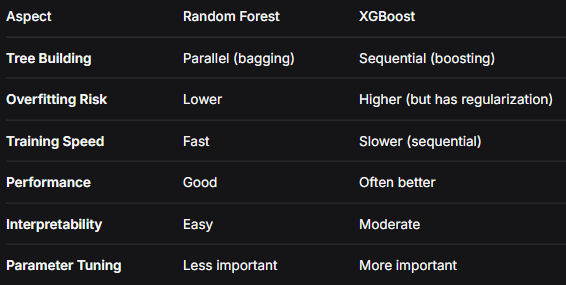

# **Cell 11.5 Hyperparameter Optimization (Quick)**

**What it does:**

Tries different combinations of XGBoost parameters to find the best performing model. Think of this like testing different ingredient amounts in a recipe to find the perfect taste!

**Why it's needed:**

The XGBoost model is already at 96.8% accuracy, but maybe it could be even better! Different parameter settings can:

      1. Improve accuracy - Find better combinations than default
      2. Prevent overfitting - Make the model generalize better to new emails
      3. peed up training - Find faster parameter combinations
      4. Balance performance - Find the sweet spot between speed and accuracy

With this cell XGBoost can become even better! Though the increase in performance might be very small but still there none the less.

.

---

**Detailed functionality:**

1. **Parameter Grid** - Defines which parameter values to test:

      * n_estimators: Number of trees (150, 200, 250)

      * max_depth: Tree depth (4, 6, 8) - controls complexity

      * learning_rate: Step size (0.05, 0.1, 0.15) - controls how fast to learn

      * subsample: % of data used per tree (0.8) - prevents overfitting

      * colsample_bytree: % of features used (0.8) - adds randomness

      * min_child_weight: Minimum instance weight (1, 3) - controls tree growth

      * gamma: Minimum loss reduction (0, 0.1) - controls splitting

      * reg_alpha: L1 regularization (0, 0.1) - penalizes complexity

      * reg_lambda: L2 regularization (1) - penalizes complexity

.

2. **Random Search** (RandomizedSearchCV) - Tests random combinations:

      * Tests 15 random combinations (instead of all 77,760 possible!)

      * Each combination is tested with 3-fold cross-validation

      * Total: 15 × 3 = 45 models trained

      * Takes ~3-5 minutes (much faster than full grid search)

.

3. **Cross-Validation** (StratifiedKFold) - Validates each parameter combination:

      * Splits training data into 3 parts

      * Trains on 2 parts, tests on 1 part

      * Repeats 3 times with different splits

      * Averages results to get reliable performance estimate

.

4. **Model Comparison** - Compares optimized vs original:

      * Shows side-by-side accuracy and F1 scores

      * Calculates improvement percentage

      * Keeps the better model

.

5. **Saving Results** - Stores the best model:

    * Saves as xgboost_optimized_model.pkl

    * Also saves tuning results for reference

.

---

**What happens to your data:**

Training data (X_train, y_train) → Used to find best parameters

Test data (X_test, y_test) → Used to evaluate the tuned model

Best parameters → Applied to create optimized model

Optimized model → Replaces original XGBoost for future cells

In [13]:
# ------------------------------------------
# CELL 11.5: Hyperparameter Optimization (Quick)
# ------------------------------------------

import os # provides functions for interacting with the operating system (file paths, directories, environment variables) - essential for loading/saving files and navigating the project structure
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import numpy as np # the fundamental package for scientific computing in Python, providing N-dimensional arrays, vectorized operations, and mathematical functions that power almost all data science and machine learning workflows
import pandas as pd # provides powerful data structures (DataFrames) for data manipulation, analysis, and loading/saving CSV files - essential for handling your email dataset
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold # RandomizedSearchCV performs hyperparameter optimization by randomly sampling from parameter distributions (faster than GridSearch); StratifiedKFold provides cross-validation that preserves class distribution for reliable model evaluation
from xgboost import XGBClassifier # high-performance gradient boosting that often outperforms Random Forest and other algorithms, with built-in regularization, handling of missing values, and excellent scalability for your email classification tasks
from sklearn.metrics import ( # provides evaluation metrics to assess your email classifier's performance, understanding both overall accuracy and specific strengths/weaknesses in identifying social vs promotion emails
    accuracy_score, # calculates the percentage of all predictions that were correct (overall correctness)
    precision_score, # measures the quality of positive predictions - of all emails predicted as promotion, how many actually were promotion (minimizes false positives)
    recall_score, # measures the quantity of positives caught - of all actual promotion emails, how many did the model correctly identify (minimizes false negatives)
    f1_score, # calculates the harmonic mean of precision and recall, providing a single balanced metric that considers both false positives and false negatives
    classification_report # generates a complete summary with precision, recall, f1-score, and support (number of samples) for each class, plus overall accuracy and averages
)
from datetime import datetime # provides tools for working with dates and times - used here to create timestamped filenames for model checkpoints, ensuring you never overwrite previous models
import matplotlib.pyplot as plt # creates professional, customizable visualizations of your email classification results, including feature importance charts, confusion matrices, performance comparisons, and distribution plots
import warnings # provides utilities for handling warning messages in Python
warnings.filterwarnings('ignore') # suppresses non-critical warning messages during model training and evaluation, keeping your output clean and focused on important results

print("=" * 60)
print("HYPERPARAMETER OPTIMIZATION")
print("XGBoost Quick Tuning")
print("=" * 60)

# -------------------------------------------------
# Verify variables
# -------------------------------------------------

required_variables = ["X_train", "X_test", "y_train", "y_test", "label_encoder"] # List of required variables that should exist from previous cells

for var in required_variables: # Iterate through each required variable name
    if var not in locals(): # Check if the variable exists in the current local scope
        raise ValueError(f"'{var}' not found. Please run previous cells first.") # Stop execution with error message if variable is missing

print(f"\nTraining samples: {X_train.shape[0]}") # Display number of training samples (rows)
print(f"Testing samples: {X_test.shape[0]}")  # Display number of test samples (rows)
print(f"Features: {X_train.shape[1]}")  # Display number of features (columns)

# -------------------------------------------------
# Define smaller parameter grid
# -------------------------------------------------

print("\nSetting up parameter grid for XGBoost...")  # Print status message to show progress

# Smaller, focused parameter grid
param_grid = {
    'n_estimators': [150, 200, 250],      # 3 options - number of boosting rounds/trees
    'max_depth': [4, 6, 8],               # 3 options - maximum tree depth
    'learning_rate': [0.05, 0.1, 0.15],   # 3 options - step size shrinkage
    'subsample': [0.8],                   # 1 option - fraction of samples used per tree
    'colsample_bytree': [0.8],            # 1 option - fraction of features used per tree
    'min_child_weight': [1, 3],           # 2 options - minimum sum of instance weight in child
    'gamma': [0, 0.1],                    # 2 options - minimum loss reduction for split
    'reg_alpha': [0, 0.1],                # 2 options - L1 regularization term on weights
    'reg_lambda': [1]                     # 1 option - L2 regularization term on weights
}

# Calculate total combinations
total_combinations = np.prod([len(v) for v in param_grid.values()])  # Multiply all parameter option counts together
print(f"Total parameter combinations: {total_combinations}")  # Display total possible combinations

# Use Random Search with very few iterations
n_iter = min(15, total_combinations)  # Test at most 15 combinations (cap by total available)
print(f"Random Search will test: {n_iter} combinations")  # Display how many will actually be tested
print(f"Total fits with 3-fold CV: {n_iter * 3}")  # Display total model fits (iterations × folds)
print(f"Estimated time: ~3-5 minutes")  # Inform user about expected runtime

# -------------------------------------------------
# Create base model
# -------------------------------------------------

xgb_base = XGBClassifier(
    random_state=42,  # Set random seed for reproducibility
    eval_metric='logloss',  # Use logloss as evaluation metric
    n_jobs=-1,  # Use all available CPU cores for parallel processing
    verbosity=0  # Suppress XGBoost output messages
)

# -------------------------------------------------
# Perform Random Search with 3-fold CV (faster!)
# -------------------------------------------------

print("\nStarting Quick Random Search with 3-fold cross-validation...")  # Status message
print("This will take ~3-5 minutes...")  # Inform user about expected runtime

# Use 3-fold instead of 5-fold (33% faster)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Create 3-fold stratified cross-validator (preserves class distribution)

random_search = RandomizedSearchCV(
    estimator=xgb_base,  # Base model to optimize
    param_distributions=param_grid,  # Parameter grid to search
    n_iter=n_iter,  # Only test limited combinations (15 max)
    cv=cv,  # 3-fold CV (faster than 5-fold)
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all available CPU cores
    random_state=42,  # Set random seed for reproducibility
    verbose=1,  # Show progress updates
    return_train_score=False  # Skip train scores (saves memory)
)

# Fit random search
random_search.fit(X_train, y_train)  # Run hyperparameter optimization on training data

# -------------------------------------------------
# Results
# -------------------------------------------------

print("\n" + "=" * 60)  # Print separator line
print("OPTIMIZATION RESULTS")  # Section header
print("=" * 60)  # Print separator line

print(f"\nBest parameters found:")  # Header for best params
for param, value in random_search.best_params_.items():  # Loop through best parameter dictionary
    print(f"   {param}: {value}")  # Display each parameter and its best value

print(f"\nBest cross-validation accuracy: {random_search.best_score_:.4f}")  # Display best CV score

# -------------------------------------------------
# Evaluate best model on test set
# -------------------------------------------------

print("\nEvaluating best model on test set...")  # Status message

best_model = random_search.best_estimator_  # Extract the best performing model
y_pred_best = best_model.predict(X_test)  # Make predictions on test set

# Calculate metrics
best_accuracy = accuracy_score(y_test, y_pred_best)  # Calculate test accuracy
best_precision = precision_score(y_test, y_pred_best, average='weighted')  # Calculate weighted precision
best_recall = recall_score(y_test, y_pred_best, average='weighted')  # Calculate weighted recall
best_f1 = f1_score(y_test, y_pred_best, average='weighted')  # Calculate weighted F1

print(f"Test Accuracy: {best_accuracy:.4f}")  # Display test accuracy
print(f"Test Precision: {best_precision:.4f}")  # Display test precision
print(f"Test Recall: {best_recall:.4f}")  # Display test recall
print(f"Test F1 Score: {best_f1:.4f}")  # Display test F1

# Classification report
print("\nClassification Report:")  # Header for classification report
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))  # Generate detailed classification metrics

# -------------------------------------------------
# Compare with original XGBoost
# -------------------------------------------------

print("\n" + "=" * 60)  # Print separator line
print("COMPARISON: Original vs Optimized XGBoost")  # Section header
print("=" * 60)  # Print separator line

try:
    original_accuracy = xgb_accuracy if 'xgb_accuracy' in locals() else None  # Check if original XGBoost accuracy exists in scope

    if original_accuracy is not None:  # Only compare if original metrics exist
        improvement = (best_accuracy - original_accuracy) * 100  # Calculate improvement percentage
        print(f"{'Model':<20} {'Accuracy':<15} {'F1 Score':<15}")  # Print table header
        print("-" * 50)  # Print separator line
        print(f"{'Original XGBoost':<20} {original_accuracy:.4f}        {xgb_f1:.4f}")  # Display original metrics
        print(f"{'Optimized XGBoost':<20} {best_accuracy:.4f}        {best_f1:.4f}")  # Display optimized metrics

        if improvement > 0:  # Check if optimized model is better
            print(f"\nAccuracy improvement: {improvement:.2f}%")  # Show positive improvement
        elif improvement < 0:  # Check if optimized model is worse
            print(f"\nOriginal model performs better by {abs(improvement):.2f}%")  # Show negative improvement
        else:  # No change
            print("\nNo change in accuracy")  # No improvement
    else:  # Original metrics not available
        print("Original XGBoost metrics not available for comparison.")  # Inform user

except Exception as e:  # Catch any errors during comparison
    print(f"Could not compare: {e}")  # Display error message

# -------------------------------------------------
# Save optimized model
# -------------------------------------------------

print("\nSaving optimized XGBoost model...")

model_path = os.path.join(project_path, "models", "saved")  # Build path to saved models directory
os.makedirs(model_path, exist_ok=True)  # Create directory if it doesn't exist

# Save optimized model
optimized_model_path = os.path.join(model_path, "xgboost_optimized_model.pkl")  # Build full path for optimized model
with open(optimized_model_path, "wb") as f:  # Open file in write-binary mode
    pickle.dump(best_model, f)  # Serialize and save best model to disk

# Save random search results
results_path = os.path.join(model_path, "quick_tuning_results.pkl")  # Build full path for tuning results
with open(results_path, "wb") as f:  # Open file in write-binary mode
    pickle.dump(random_search, f)  # Serialize and save random search object

print(f"Optimized model saved to: {optimized_model_path}")  # Display save location
print(f"Tuning results saved to: {results_path}")  # Display save location

# -------------------------------------------------
# Summary
# -------------------------------------------------

print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)

print(f"\nBest model parameters:")  # Header for best params
for param, value in random_search.best_params_.items():  # Loop through best parameter dictionary
    print(f"  - {param}: {value}")  # Display each parameter and its best value

print(f"\nBest CV Accuracy: {random_search.best_score_:.4f}")  # Display best cross-validation accuracy
print(f"Test Accuracy: {best_accuracy:.4f}")  # Display test accuracy
print(f"Test F1 Score: {best_f1:.4f}")  # Display test F1

# -------------------------------------------------
# Update variables for later cells
# -------------------------------------------------

xgb_model = best_model  # Store best model for later use
xgb_accuracy = best_accuracy  # Store accuracy for later use
xgb_precision = best_precision  # Store precision for later use
xgb_recall = best_recall  # Store recall for later use
xgb_f1 = best_f1  # Store F1 for later use
xgb_metrics = {  # Create metrics dictionary
    'accuracy': xgb_accuracy,  # Store accuracy
    'precision': xgb_precision,  # Store precision
    'recall': xgb_recall,  # Store recall
    'f1': xgb_f1  # Store F1
}

print("\nOptimized XGBoost is now the primary model!")

HYPERPARAMETER OPTIMIZATION
XGBoost Quick Tuning

Training samples: 6024
Testing samples: 1506
Features: 10008

Setting up parameter grid for XGBoost...
Total parameter combinations: 216
Random Search will test: 15 combinations
Total fits with 3-fold CV: 45
Estimated time: ~3-5 minutes

Starting Quick Random Search with 3-fold cross-validation...
This will take ~3-5 minutes...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

OPTIMIZATION RESULTS

Best parameters found:
   subsample: 0.8
   reg_lambda: 1
   reg_alpha: 0.1
   n_estimators: 150
   min_child_weight: 1
   max_depth: 8
   learning_rate: 0.15
   gamma: 0.1
   colsample_bytree: 0.8

Best cross-validation accuracy: 0.9691

Evaluating best model on test set...
Test Accuracy: 0.9675
Test Precision: 0.9673
Test Recall: 0.9675
Test F1 Score: 0.9673

Classification Report:
              precision    recall  f1-score   support

   promotion       0.97      0.98      0.98      1095
      social       0.95      0.92      0

# **Cell 12: User Email Prediciton**

**What it does:**

Allows users to test the trained models on their own emails. It provides an interactive interface where you can paste any email and get instant predictions from both Random Forest and XGBoost models, complete with confidence scores and probability breakdowns.

**Why it's needed:**

After training and comparing models (Cells 9-11), the final step is to actually USE the models for predictions. This cell provides the interface to:

      1. Test the models on real emails
      2. Get predictions from both models simultaneously
      3. See confidence scores (how sure the model is)
      4. Compare how both models perform on the same email
      5. Provide a user-friendly interface (no coding needed!)

.

---

**Detailed functionality:**

1. **Preprocessing Validation** (PreprocessingValidator class). Checks that required functions exist:

    * `preprocess_text()` - Cleans email text (from Cell 5)

    * `extract_plain_text()` - Extracts text from HTML

    * `remove_suspicious_words()` - Removes leakage words

    * Ensures these functions are available before proceeding

.

2. **Model Loading** (ModelLoader class). Loads all required models and tools:

    * Random Forest model (random_forest_model.pkl)

    * XGBoost model (xgboost_model.pkl)

    * TF-IDF vectorizer (tfidf_vectorizer.pkl)

    * Feature scaler (feature_scaler.pkl)

    * Label encoder (label_encoder.pkl)

    * Falls back to disk if models not in memory

.

3. **Feature Extraction** (FeatureExtractor class). Extracts the 8 numerical features:

    * Character count, word count, subject word count

    * Average word length, URL presence, email presence

    * Caps ratio, special character count

    * Same features as Cell 6 for consistency

.

4. **Email Prediction** (EmailPredictor class). The core prediction engine:

    * Cleans text - Uses Cell 5's preprocess_text()

    * Extracts features - Creates TF-IDF and numerical features

    * Makes predictions - Both RF and XGB predict simultaneously

    * Calculates confidence - Probability scores as percentages

    * Shows results - Displays predictions, confidence, and probabilities

.

5. **Interactive Prediction** (InteractivePredictor class). User-friendly interface:

    * Prompts for subject - Optional subject line input

    * Prompts for email content - Paste or type email (press Enter twice to finish)

    * Shows results - Displays predictions from both models

    * Option to see cleaned text - Shows what the model actually saw

    * Loop - Predict multiple emails without restarting

.

6. **Example Runner** (ExampleRunner class). Pre-defined test emails:

    * Promotion example - "Special Offer - 50% Off!" (should predict "promotion")

    * Social example - "Re: Meeting tomorrow?" (should predict "social")

    * Newsletter example - "Your weekly newsletter" (should predict "promotion")

    * Shows expected vs actual - Helps validate model performance

.

7. **Main Pipeline** (PredictorPipeline class). Orchestrates everything:

    * Validates preprocessing functions

    * Loads all models and tools

    * Displays menu for user selection

    * Runs examples or interactive mode

.

---

**What happens when you predict an email:**

1. Input → User provides subject (optional) and email text

2. Clean → Text is cleaned using Cell 5's preprocess_text()

3. Vectorize → Text is transformed to TF-IDF features

4. Extract → 8 numerical features are extracted

5. Combine → TF-IDF + numerical features = ~10,008 features

6. Predict → Both models make predictions on the same features

7. Results → Shows:

    * Prediction (Promotion or Social)

    * Confidence score (e.g., 96.8%)

    * Probability breakdown (e.g., 97% Promotion, 3% Social)

    * Whether models agree

.

**What happens to your data:**

User enters email (text) → Input to the system

Email is cleaned → Text is standardized

Features are extracted → 10,008+ features created

Models make predictions → Both RF and XGB predict

Results are displayed → User sees predictions and confidence

In [14]:
# ------------------------------------------
# CELL 12: User Email Prediction
# ------------------------------------------

import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import re # provides regular expression operations for pattern matching and text manipulation - used for cleaning email text by removing unwanted patterns like reply headers, signatures, and HTML tags
import string # provides constants and utilities for working with text characters - used for punctuation removal and text cleaning operations
import pandas as pd # provides powerful data structures (DataFrames) for data manipulation, analysis, and loading/saving CSV files - essential for handling your email dataset
import numpy as np # the fundamental package for scientific computing in Python, providing N-dimensional arrays, vectorized operations, and mathematical functions that power almost all data science and machine learning workflows
import scipy.sparse as sp # provides efficient storage and operations for sparse matrices (matrices with mostly zero values) - used for TF-IDF feature matrices where most word counts are zero
import os # provides functions for interacting with the operating system (file paths, directories, environment variables) - essential for loading/saving files and navigating the project structure
from typing import Dict, List, Optional, Tuple, Any # provides type hints that make your code self-documenting, enable IDE autocomplete, catch errors early with type checkers (like mypy), and make your ML pipeline more maintainable and professional
from dataclasses import dataclass, field # dataclass automatically generates __init__, __repr__, and __eq__ methods for data container classes; field() provides control over individual attributes with default factories, exclusion from representations, or metadata
from pathlib import Path # provides an object-oriented, cross-platform way to handle file system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation (uses / operator for joining paths)

# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class PredictorConfig:
    """Configuration for email prediction"""
    model_path: str = "models/saved"  # Path where models are saved
    rf_model_filename: str = "random_forest_model.pkl"  # Random Forest model filename
    xgb_model_filename: str = "xgboost_optimized_model.pkl"  # XGBoost model filename
    vectorizer_filename: str = "tfidf_vectorizer.pkl"  # TF-IDF vectorizer filename
    scaler_filename: str = "feature_scaler.pkl"  # Feature scaler filename
    encoder_filename: str = "label_encoder.pkl"  # Label encoder filename
    required_functions: List[str] = field(default_factory=lambda: [
        'preprocess_text', 'extract_plain_text', 'remove_suspicious_words'
    ])  # Required functions from Cell 5
    feature_columns: List[str] = field(default_factory=lambda: [
        "char_count", "word_count", "subject_word_count",
        "avg_word_length", "has_url", "has_email",
        "caps_ratio", "special_char_count"
    ])  # Feature column names


# ==========================================
# PART 2: PREPROCESSING VALIDATOR
# ==========================================

class PreprocessingValidator:
    """Validates that preprocessing functions are available"""

    def __init__(self, config: PredictorConfig):
        self.config = config  # Store configuration

    def validate_functions(self) -> None:
        """Check if required preprocessing functions exist"""
        print("\nChecking for preprocessing functions from Cell 5...")  # Progress message

        missing_functions = []  # Initialize list for missing functions

        for func in self.config.required_functions:  # Check each required function
            if func not in globals():  # Function not in global scope
                missing_functions.append(func)  # Add to missing list

        if missing_functions:  # Some functions are missing
            print(f"Error: Missing functions from Cell 5: {missing_functions}")  # Error message
            print("   Please run Cell 5 first!")  # Instruction
            print("   Cell 5 must define: preprocess_text(), extract_plain_text(), remove_suspicious_words()")  # Required functions
            raise ImportError(f"Missing required functions: {missing_functions}")  # Raise error
        else:  # All functions available
            print("Success: Found all preprocessing functions from Cell 5")  # Success message


# ==========================================
# PART 3: MODEL LOADER
# ==========================================

class ModelLoader:
    """Handles loading models and preprocessing tools from disk"""

    def __init__(self, config: PredictorConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path
        self.models = {}  # Dictionary to store loaded models

    def load_all_models(self) -> Dict:
        """Load all required models and tools"""
        print("\nLoading models and preprocessing tools...")  # Progress message

        model_path = self.project_path / self.config.model_path  # Create full model path

        # Load Random Forest model
        self.models['rf_model'] = self._load_model(
            model_path / self.config.rf_model_filename,
            "Random Forest model"
        )  # Load RF model

        # Load XGBoost model
        self.models['xgb_model'] = self._load_model(
            model_path / self.config.xgb_model_filename,
            "XGBoost model"
        )  # Load XGB model

        # Load TF-IDF vectorizer
        self.models['vectorizer'] = self._load_model(
            model_path / self.config.vectorizer_filename,
            "TF-IDF vectorizer"
        )  # Load vectorizer

        # Load feature scaler
        self.models['scaler'] = self._load_model(
            model_path / self.config.scaler_filename,
            "Feature scaler"
        )  # Load scaler

        # Load label encoder
        self.models['label_encoder'] = self._load_model(
            model_path / self.config.encoder_filename,
            "Label encoder"
        )  # Load encoder

        print("\n" + "=" * 60)  # Separator

        return self.models  # Return all loaded models

    def _load_model(self, file_path: Path, model_name: str) -> Optional[Any]:
        """Load a single model from disk"""
        try:
            with open(file_path, "rb") as f:  # Open file in binary read mode
                model = pickle.load(f)  # Load model from disk
                print(f"Success: Loaded {model_name}")  # Success message
                return model  # Return loaded model
        except FileNotFoundError:  # File not found
            print(f"Error: {model_name} not found! Please run previous cells first.")  # Error message
            return None  # Return None
        except Exception as e:  # Other errors
            print(f"Error: Could not load {model_name}: {e}")  # Error message
            return None  # Return None


# ==========================================
# PART 4: FEATURE EXTRACTOR
# ==========================================

class FeatureExtractor:
    """Extracts features from email text"""

    def __init__(self, config: PredictorConfig):
        self.config = config  # Store configuration

    def extract_features(self, text: str) -> Dict:
        """Extract numerical features from text"""
        if not text:  # Check if text is empty
            text = ""  # Set to empty string

        features = {
            "char_count": len(str(text)),  # Count characters
            "word_count": len(str(text).split()),  # Count words
            "subject_word_count": 0,  # No subject for user input
            "avg_word_length": np.mean([len(word) for word in str(text).split()]) if len(str(text).split()) > 0 else 0,  # Average word length
            "has_url": int(bool(re.search(r"http[s]?://|www\.", str(text), re.IGNORECASE))),  # Check for URL
            "has_email": int(bool(re.search(r"\S+@\S+", str(text), re.IGNORECASE))),  # Check for email
            "caps_ratio": sum(c.isupper() for c in str(text)) / max(len(str(text)), 1),  # Calculate caps ratio
            "special_char_count": len(re.findall(r"[!?$%#@]", str(text)))  # Count special characters
        }  # Dictionary of features

        return features  # Return features dictionary


# ==========================================
# PART 5: EMAIL PREDICTOR
# ==========================================

class EmailPredictor:
    """Main email prediction class"""

    def __init__(self, config: PredictorConfig, models: Dict):
        self.config = config  # Store configuration
        self.models = models  # Store loaded models
        self.feature_extractor = FeatureExtractor(config)  # Initialize feature extractor

    def predict(self, email_text: str, subject: str = "", verbose: bool = True) -> Optional[Dict]:
        """
        Predict if an email is Promotion or Social using both models

        Parameters:
        - email_text: The email content
        - subject: Optional subject line (will be prepended to text)
        - verbose: Print detailed output

        Returns:
        - Dictionary with predictions from both models
        """
        # Check if all required tools are loaded
        if self.models['rf_model'] is None or self.models['xgb_model'] is None:  # Models not loaded
            print("Error: Models not loaded! Please train models first.")
            return None  # Return None

        if self.models['vectorizer'] is None or self.models['scaler'] is None or self.models['label_encoder'] is None:  # Tools not loaded
            print("Error: Preprocessing tools not loaded!")
            return None  # Return None

        # Combine subject and text
        if subject and subject != "No Subject":  # Subject provided
            combined_text = subject + " " + email_text  # Combine subject and text
        else:  # No subject
            combined_text = email_text  # Use only text

        # Step 1: Clean the email using preprocess_text() from Cell 5
        cleaned_text = preprocess_text(combined_text)  # Apply preprocessing

        if not cleaned_text.strip():  # Check if cleaned text is empty
            print("Warning: Email is empty after preprocessing!")
            print("   Using original text for prediction...")
            cleaned_text = combined_text  # Use original text

        # Step 2: Extract numerical features
        features = self.feature_extractor.extract_features(cleaned_text)  # Extract features

        # Step 3: Create TF-IDF features
        text_df = pd.DataFrame({0: [cleaned_text]})  # Create dataframe from text

        try:  # Transform text using vectorizer
            tfidf_features = self.models['vectorizer'].transform(text_df[0])  # Transform to TF-IDF
        except Exception as e:  # Error in transformation
            print(f"Error: Error transforming text: {e}")  # Error message
            return None  # Return None

        # Step 4: Create numerical features
        feature_values = [[
            features["char_count"],  # Character count
            features["word_count"],  # Word count
            features["subject_word_count"],  # Subject word count
            features["avg_word_length"],  # Average word length
            features["has_url"],  # URL presence
            features["has_email"],  # Email presence
            features["caps_ratio"],  # Caps ratio
            features["special_char_count"]  # Special character count
        ]]  # List of feature values

        # Scale numerical features
        scaled_features = self.models['scaler'].transform(feature_values)  # Apply scaling
        scaled_features_sparse = sp.csr_matrix(scaled_features)  # Convert to sparse matrix

        # Step 5: Combine features
        combined_features = sp.hstack([tfidf_features, scaled_features_sparse])  # Stack features horizontally

        # Step 6: Make predictions
        rf_pred = self.models['rf_model'].predict(combined_features)  # RF prediction
        xgb_pred = self.models['xgb_model'].predict(combined_features)  # XGB prediction

        # Get probabilities
        rf_proba = self.models['rf_model'].predict_proba(combined_features)[0]  # RF probabilities
        xgb_proba = self.models['xgb_model'].predict_proba(combined_features)[0]  # XGB probabilities

        # Decode predictions
        rf_label = self.models['label_encoder'].inverse_transform(rf_pred)[0]  # Decode RF label
        xgb_label = self.models['label_encoder'].inverse_transform(xgb_pred)[0]  # Decode XGB label

        # Get confidence scores
        rf_confidence = max(rf_proba) * 100  # RF confidence percentage
        xgb_confidence = max(xgb_proba) * 100  # XGB confidence percentage

        # Create results dictionary
        results = {
            'rf_prediction': rf_label,  # RF prediction
            'xgb_prediction': xgb_label,  # XGB prediction
            'rf_probabilities': dict(zip(self.models['label_encoder'].classes_, rf_proba)),  # RF probabilities
            'xgb_probabilities': dict(zip(self.models['label_encoder'].classes_, xgb_proba)),  # XGB probabilities
            'rf_confidence': rf_confidence,  # RF confidence
            'xgb_confidence': xgb_confidence,  # XGB confidence
            'cleaned_text': cleaned_text[:200] + "..." if len(cleaned_text) > 200 else cleaned_text,  # Cleaned text preview
            'features': features  # Extracted features
        }  # Results dictionary

        # Print results
        if verbose:  # Verbose output requested
            self._print_results(results, subject, email_text)  # Display results

        return results  # Return results

    def _print_results(self, results: Dict, subject: str, email_text: str) -> None:
        """Print prediction results"""
        print("\n" + "=" * 60)
        print("PREDICTION RESULTS")
        print("=" * 60)

        print("\nEmail Preview:")
        print("-" * 40)
        print(f"Subject: {subject if subject else 'No Subject'}")  # Show subject
        print(f"Preview: {email_text[:200]}..." if len(email_text) > 200 else email_text)  # Show preview

        print("\nPredictions:")
        print("-" * 40)

        print(f"Random Forest: {results['rf_prediction'].upper()} (Confidence: {results['rf_confidence']:.1f}%)")  # RF prediction
        print(f"XGBoost      : {results['xgb_prediction'].upper()} (Confidence: {results['xgb_confidence']:.1f}%)")  # XGB prediction

        # Check if models agree
        if results['rf_prediction'] == results['xgb_prediction']:  # Models agree
            print(f"\nSuccess: Both models agree: {results['rf_prediction'].upper()}")  # Success message
        else:  # Models disagree
            print(f"\nWarning: Models disagree!")  # Warning message
            print(f"   Random Forest says: {results['rf_prediction'].upper()} ({results['rf_confidence']:.1f}%)")  # Show RF
            print(f"   XGBoost says: {results['xgb_prediction'].upper()} ({results['xgb_confidence']:.1f}%)")  # Show XGB

        # Show probabilities
        print("\nDetailed Probabilities:")
        print("-" * 40)
        for label in self.models['label_encoder'].classes_:  # Iterate through classes
            rf_proba_val = results['rf_probabilities'][label] * 100  # RF probability percentage
            xgb_proba_val = results['xgb_probabilities'][label] * 100  # XGB probability percentage
            print(f"{label.capitalize():<10} RF: {rf_proba_val:6.1f}%  |  XGB: {xgb_proba_val:6.1f}%")  # Show probabilities

        print("\nExtracted Features:")
        print("-" * 40)
        for key, value in results['features'].items():  # Iterate through features
            display_name = key.replace('_', ' ').title()  # Format display name
            print(f"{display_name:<20}: {value}")  # Show feature value


# ==========================================
# PART 6: INTERACTIVE PREDICTOR
# ==========================================

class InteractivePredictor:
    """Handles interactive email prediction"""

    def __init__(self, email_predictor: EmailPredictor):
        self.email_predictor = email_predictor  # Store email predictor

    def run(self) -> None:
        """Run interactive prediction session"""
        print("\n" + "=" * 60)
        print("INTERACTIVE EMAIL PREDICTOR")
        print("=" * 60)

        print("\nYou can now test the models with your own emails!")
        print("Enter 'quit' to exit.\n")

        while True:  # Main loop
            print("\n" + "-" * 40)  # Separator

            # Get subject (optional)
            subject = input("Enter subject (optional, press Enter to skip): ").strip()  # Get subject
            if subject.lower() == 'quit':  # Check for quit
                break  # Exit loop

            # Get email content
            print("\nEnter email content (paste your email):")
            print("(Press Enter twice to finish)")

            lines = []  # Initialize list for content lines
            while True:  # Content input loop
                line = input()  # Get line
                if line == "" and len(lines) > 0:  # Empty line after content means done
                    break  # Exit content loop
                if line.lower() == 'quit' and len(lines) == 0:  # Quit without content
                    return  # Exit function
                lines.append(line)  # Add line to content

            email_text = "\n".join(lines)  # Join lines into text

            if not email_text.strip():  # Check if content is empty
                print("Warning: No email content provided. Please try again.")  # Warning message
                continue  # Continue to next iteration

            # Make prediction
            print("\n" + "=" * 40)  # Separator
            print("ANALYZING EMAIL...")  # Progress message
            print("=" * 40)  # Separator

            results = self.email_predictor.predict(email_text, subject)  # Make prediction

            if results:  # Prediction successful
                # Ask if user wants to see full cleaned text
                show_cleaned = input("\nShow cleaned text? (y/n): ").lower()  # Ask user
                if show_cleaned == 'y':  # User wants to see cleaned text
                    print("\nCleaned Text:")  # Section header
                    print("-" * 40)  # Separator
                    print(results['cleaned_text'])  # Show cleaned text

            # Ask if user wants to predict another email
            continue_pred = input("\nPredict another email? (y/n): ").lower()  # Ask user
            if continue_pred != 'y':  # User doesn't want to continue
                break  # Exit loop

        print("\nThank you for using the Email Classification Predictor!")  # Thank you message
        print("=" * 60)  # Separator


# ==========================================
# PART 7: EXAMPLE RUNNER
# ==========================================

class ExampleRunner:
    """Runs pre-defined example emails through the system"""

    def __init__(self, email_predictor: EmailPredictor):
        self.email_predictor = email_predictor  # Store email predictor
        self.examples = self._create_examples()  # Create example emails

    def _create_examples(self) -> List[Dict]:
        """Create pre-defined example emails"""
        return [
            {
                'subject': "Special Offer - 50% Off!",  # Subject line
                'text': """Dear customer,

Hurry! Our biggest sale of the year is here! Save 50% on all items.
Don't miss out on this exclusive offer. Shop now before it's too late!

Click here to claim your discount!
http://www.shopexample.com/sale

Best regards,
Shop Example Team""",  # Email content
                'expected': "promotion"  # Expected category
            },
            {
                'subject': "Re: Meeting tomorrow?",  # Subject line
                'text': """Hi team,

Are we still meeting tomorrow at 2pm? I have some updates to share about the project.

Let me know if the time works for everyone.

Thanks,
John""",  # Email content
                'expected': "social"  # Expected category
            },
            {
                'subject': "Your weekly newsletter",  # Subject line
                'text': """Welcome to our newsletter!

This week's highlights:
- New product launches
- Customer success stories
- Upcoming events

Read more on our blog: http://blog.company.com

Unsubscribe link: http://company.com/unsubscribe""",  # Email content
                'expected': "promotion"  # Expected category
            }
        ]  # List of example emails

    def run(self) -> None:
        """Run example emails through the system"""
        print("\n" + "=" * 60)  # Separator
        print("RUNNING EXAMPLE EMAILS")  # Section header
        print("=" * 60)  # Separator

        print("\nTesting with pre-defined examples...\n")  # Progress message

        for i, example in enumerate(self.examples, 1):  # Iterate through examples
            print(f"\n{'-' * 40}")  # Separator
            print(f"Example {i}:")  # Example number
            print(f"Subject: {example['subject']}")  # Show subject
            print(f"Expected: {example['expected'].upper()}")  # Show expected category
            print(f"Content preview: {example['text'][:100]}...")  # Show content preview

            results = self.email_predictor.predict(example['text'], example['subject'], verbose=False)  # Make prediction

            if results:  # Prediction successful
                print(f"\nPredictions:")  # Section header
                print(f"  Random Forest: {results['rf_prediction'].upper()} ({results['rf_confidence']:.1f}%)")  # RF prediction
                print(f"  XGBoost      : {results['xgb_prediction'].upper()} ({results['xgb_confidence']:.1f}%)")  # XGB prediction

                # Check if predictions match expected
                if results['rf_prediction'] == example['expected'] and results['xgb_prediction'] == example['expected']:  # Both correct
                    print("  Success: Both models correct!")  # Success message
                elif results['rf_prediction'] == example['expected'] or results['xgb_prediction'] == example['expected']:  # One correct
                    print("  Warning: One model correct, one incorrect")  # Warning message
                else:  # Both incorrect
                    print("  Error: Both models incorrect!")  # Error message

            input("\nPress Enter to continue to next example...")  # Pause between examples


# ==========================================
# PART 8: MAIN PREDICTOR PIPELINE
# ==========================================

class PredictorPipeline:
    """Main predictor pipeline"""

    def __init__(self, config: PredictorConfig = None, project_path: str = None):
        self.config = config or PredictorConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.validator = PreprocessingValidator(self.config)  # Initialize validator
        self.models = None  # Initialize models
        self.predictor = None  # Initialize predictor

    def run(self) -> None:
        """Run the complete predictor pipeline"""
        # Step 1: Validate preprocessing functions
        self.validator.validate_functions()  # Check Cell 5 functions

        # Step 2: Load models
        loader = ModelLoader(self.config, self.project_path)  # Create loader
        self.models = loader.load_all_models()  # Load all models

        # Step 3: Check if models loaded successfully
        if self.models['rf_model'] is None or self.models['xgb_model'] is None:  # Models not loaded
            print("\nWarning: Models not loaded. Please train models first.")  # Warning message
            print("   Run Cells 9 and 10 before using this predictor.")  # Instruction
            return  # Exit function

        # Step 4: Create predictor
        self.predictor = EmailPredictor(self.config, self.models)  # Initialize predictor

        # Step 5: Ask user how they want to proceed
        print("\n" + "=" * 60)  # Separator
        print("SELECT MODE")  # Section header
        print("=" * 60)  # Separator
        print("1. Run example emails")  # Option 1
        print("2. Interactive prediction (enter your own emails)")  # Option 2
        print("3. Exit")  # Option 3

        choice = input("\nEnter your choice (1, 2, or 3): ").strip()  # Get user choice

        if choice == "1":  # Run examples
            example_runner = ExampleRunner(self.predictor)  # Create example runner
            example_runner.run()  # Run examples
        elif choice == "2":  # Interactive prediction
            interactive = InteractivePredictor(self.predictor)  # Create interactive predictor
            interactive.run()  # Run interactive session
        else:  # Exit
            print("\nGoodbye!")  # Goodbye message
            print("=" * 60)  # Separator


# ==========================================
# PART 9: EXECUTION
# ==========================================

# Main execution
print("=" * 60)
print("EMAIL CLASSIFICATION PREDICTOR")
print("Random Forest vs XGBoost")
print("=" * 60)

# Check if project_path exists
if 'project_path' not in locals():  # Check if project path is defined
    print("Warning: project_path not defined. Using current directory.")  # Warning message
    project_path = os.getcwd()  # Use current directory as fallback

# Create and run pipeline
pipeline = PredictorPipeline(project_path=project_path)  # Create pipeline instance
pipeline.run()  # Run pipeline

print("\n" + "=" * 60)
print("CELL 12 COMPLETE - Email Prediction Completed")
print("=" * 60)

EMAIL CLASSIFICATION PREDICTOR
Random Forest vs XGBoost

Checking for preprocessing functions from Cell 5...
Success: Found all preprocessing functions from Cell 5

Loading models and preprocessing tools...
Success: Loaded Random Forest model
Success: Loaded XGBoost model
Success: Loaded TF-IDF vectorizer
Success: Loaded Feature scaler
Success: Loaded Label encoder


SELECT MODE
1. Run example emails
2. Interactive prediction (enter your own emails)
3. Exit

Enter your choice (1, 2, or 3): 2

INTERACTIVE EMAIL PREDICTOR

You can now test the models with your own emails!
Enter 'quit' to exit.


----------------------------------------
Enter subject (optional, press Enter to skip): 

Enter email content (paste your email):
(Press Enter twice to finish)
William, nu närmar sig terminsstarten! 📚 Om bara några veckor drar höstterminen igång och just nu ökar efterfrågan på kurslitteratur snabbt. Genom att köpa dina kursböcker redan idag ökar chansen att hitta de böcker du behöver till ett bra

# **Cell 13: Export Prediction History to PowerBI**

**What it does:**

Generates predictions for ALL emails in your dataset (not just the test set) and exports them along with detailed statistics into a format that can be imported into PowerBI for dashboard creation. Think of this like creating a comprehensive report card for every email in your system!

**Why it's needed:**

After training and evaluating models (Cells 9-11), you have a working model. But what about all the other emails in your dataset? This cell:

    1. Makes predictions on EVERY email (not just the test set)
    2. Creates a complete prediction history with features and confidence scores
    3. Exports data in a PowerBI-friendly format
    4. Generates summary statistics and visualizations
    5. Creates a dashboard-ready dataset with all necessary information

.

---

**Detailed functionality:**

1. **Model Loading** (ExportModelLoader class). Loads all required models and data:

    * Random Forest and XGBoost models

    * TF-IDF vectorizer and feature scaler

    * Label encoder for decoding predictions

    * Original dataset (or loads from CSV if not in memory)

    * Same models used for predictions in Cell 12

.

2. **Prediction Generation** (PredictionGenerator class). Makes predictions on ALL emails:

    * Full dataset - Predicts on every email in the original dataset (not just test set)

    * Both models - Gets predictions from both Random Forest and XGBoost

    * Confidence scores - Calculates how sure each model is

    * Probabilities - Gets probability for both classes (Promotion/Social)

    * Model agreement - Checks if both models agree on the prediction

    * Correctness - Compares predictions to actual labels

.

3. **Data Cleaning for PowerBI** (DataCleaner class). Ensures data is PowerBI-ready:

    * Numeric formatting - Converts all numbers to proper decimal format

    * Type conversion - Ensures correct data types (int, float, bool)

    * Handles edge cases - Replaces empty values with 0

    * Removes special characters - Makes CSV import clean

.

4. **Summary Statistics** (SummaryStatsGenerator class). Creates performance summary:

    * Model accuracy - RF and XGB accuracy on full dataset

    * Confidence scores - Average confidence per category per model

    * Category distribution - How many Promotion vs Social emails

    * Model agreement percentage - How often models agree

.

5. **Data Export** (DataExporter class). Exports multiple files:

    * Prediction history - Complete dataset with all predictions

    * Summary statistics - JSON with performance metrics

    * Confusion matrices - RF and XGB confusion matrices as CSV

    * Sample data - First 1000 predictions for quick testing

    * PowerBI simple - Simplified format with boolean flags

.

6. **PowerBI Instructions** (PowerBIInstructions class). Provides dashboard guidance:

    * How to import data into PowerBI

    * Suggested visualizations

    * Measures to create (DAX formulas)

    * Slicers to add for interactivity


.

---

**What gets exported:**

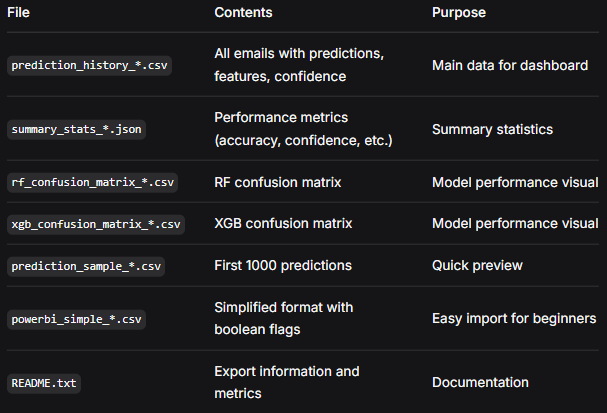

[ Some instructions are included on how one can utilize the information in PowerBI and create a comprehensive dashboard. ]


**What happens to your data:**

Original dataset (7540 emails) → Loaded from memory or CSV

All emails → Predictions made with both models

Features + Predictions + Confidence → Combined into one dataframe

Multiple formats → Exported as CSV and JSON

Ready for PowerBI → Dashboard creation



In [15]:
# ------------------------------------------
# CELL 13: Export Prediction History for PowerBI
# ------------------------------------------

import pandas as pd # provides powerful data structures (DataFrames) for data manipulation, analysis, and loading/saving CSV files - essential for handling your email dataset
import numpy as np # the fundamental package for scientific computing in Python, providing N-dimensional arrays, vectorized operations, and mathematical functions that power almost all data science and machine learning workflows
import pickle # provides functionality for serializing (pickling) and deserializing (unpickling) Python objects, enabling you to save and load trained models, vectorizers, and other objects to/from disk
import os # provides functions for interacting with the operating system (file paths, directories, environment variables) - essential for loading/saving files and navigating the project structure
from datetime import datetime # provides tools for working with dates and times - used here to create timestamped filenames for model checkpoints, ensuring you never overwrite previous models
import json # provides functionality for working with JSON (JavaScript Object Notation) data - used for saving/loading configuration files and metadata in a human-readable format
import glob # provides pattern matching for file paths using wildcards (e.g., *.csv) - used to find and list files matching specific patterns in directories
import scipy.sparse as sp # provides efficient storage and operations for sparse matrices (matrices with mostly zero values) - used for TF-IDF feature matrices where most word counts are zero
from typing import Dict, List, Optional, Any, Tuple # provides type hints that make your code self-documenting, enable IDE autocomplete, catch errors early with type checkers (like mypy), and make your ML pipeline more maintainable and professional
from dataclasses import dataclass, field # dataclass automatically generates __init__, __repr__, and __eq__ methods for data container classes; field() provides control over individual attributes with default factories, exclusion from representations, or metadata
from pathlib import Path # provides an object-oriented, cross-platform way to handle file system paths that's cleaner, more readable, and more intuitive than traditional string-based path manipulation (uses / operator for joining paths)

# ==========================================
# PART 1: CONFIGURATION
# ==========================================

@dataclass
class ExportConfig:
    """Configuration for data export"""
    model_path: str = "models/saved"  # Path where models are saved
    data_path: str = "data/processed"  # Path where processed data is stored
    export_base_path: str = "exports"  # Base path for exports
    rf_model_filename: str = "random_forest_model.pkl"  # Random Forest model filename
    xgb_model_filename: str = "xgboost_model.pkl"  # XGBoost model filename
    vectorizer_filename: str = "tfidf_vectorizer.pkl"  # TF-IDF vectorizer filename
    scaler_filename: str = "feature_scaler.pkl"  # Feature scaler filename
    encoder_filename: str = "label_encoder.pkl"  # Label encoder filename
    feature_columns: List[str] = field(default_factory=lambda: [
        "char_count", "word_count", "subject_word_count",
        "avg_word_length", "has_url", "has_email",
        "caps_ratio", "special_char_count"
    ])  # Feature column names
    numeric_columns: List[str] = field(default_factory=lambda: [
        'char_count', 'word_count', 'subject_word_count', 'avg_word_length',
        'has_url', 'has_email', 'caps_ratio', 'special_char_count',
        'rf_confidence', 'xgb_confidence', 'rf_promo_prob', 'rf_social_prob',
        'xgb_promo_prob', 'xgb_social_prob'
    ])  # Numeric columns for cleaning
    bool_columns: List[str] = field(default_factory=lambda: [
        'models_agree', 'rf_correct', 'xgb_correct'
    ])  # Boolean columns
    int_columns: List[str] = field(default_factory=lambda: [
        'char_count', 'word_count', 'subject_word_count',
        'has_url', 'has_email', 'special_char_count'
    ])  # Integer columns


# ==========================================
# PART 2: MODEL LOADER
# ==========================================

class ExportModelLoader:
    """Handles loading models and data for export"""

    def __init__(self, config: ExportConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path
        self.models = {}  # Dictionary to store loaded models
        self.df = None  # Dataframe placeholder

    def load_all(self) -> Dict:
        """Load all required models and data"""
        print("\nLoading models and data...")  # Progress message

        model_path = self.project_path / self.config.model_path  # Create full model path

        # Load label encoder
        self.models['label_encoder'] = self._load_model(
            model_path / self.config.encoder_filename,
            "Label encoder"
        )  # Load encoder

        # Load Random Forest model
        self.models['rf_model'] = self._load_model(
            model_path / self.config.rf_model_filename,
            "Random Forest model"
        )  # Load RF model

        # Load XGBoost model
        self.models['xgb_model'] = self._load_model(
            model_path / self.config.xgb_model_filename,
            "XGBoost model"
        )  # Load XGB model

        # Load TF-IDF vectorizer
        self.models['vectorizer'] = self._load_model(
            model_path / self.config.vectorizer_filename,
            "TF-IDF vectorizer"
        )  # Load vectorizer

        # Load feature scaler
        self.models['scaler'] = self._load_model(
            model_path / self.config.scaler_filename,
            "Feature scaler"
        )  # Load scaler

        # Load dataset
        self.df = self._load_dataset()  # Load processed data

        return self.models  # Return all loaded models

    def _load_model(self, file_path: Path, model_name: str) -> Optional[Any]:
        """Load a single model from disk"""
        try:
            with open(file_path, "rb") as f:  # Open file in binary read mode
                model = pickle.load(f)  # Load model from disk
                print(f"Success: Loaded {model_name}")  # Success message
                return model  # Return loaded model
        except FileNotFoundError:  # File not found
            print(f"Error: {model_name} not found!")  # Error message
            return None  # Return None
        except Exception as e:  # Other errors
            print(f"Error: Could not load {model_name}: {e}")  # Error message
            return None  # Return None

    def _load_dataset(self) -> Optional[pd.DataFrame]:
        """Load dataset from processed data folder"""
        # Check if df exists in global scope
        global df  # Declare global to access it
        if 'df' in globals():  # Check if df exists in global scope
            print("Success: Using dataframe from memory")  # Success message
            return df  # Return dataframe from memory

        print("Warning: Dataframe not found! Looking for saved CSV...")  # Warning message
        data_path = self.project_path / self.config.data_path  # Create data path
        csv_files = glob.glob(str(data_path / "cleaned_emails_*.csv"))  # Find CSV files

        if csv_files:  # CSV files found
            latest_csv = max(csv_files, key=os.path.getctime)  # Get newest file
            loaded_df = pd.read_csv(latest_csv)  # Load CSV
            print(f"Success: Loaded dataset from: {os.path.basename(latest_csv)}")  # Success message
            print(f"   Shape: {loaded_df.shape}")  # Show shape
            return loaded_df  # Return loaded dataframe

        print("Error: No dataset found! Please run Cells 4-6 first.")  # Error message
        raise FileNotFoundError("Dataset not found")  # Raise error


# ==========================================
# PART 3: EXPORT FOLDER MANAGER
# ==========================================

class ExportFolderManager:
    """Manages export folder creation and file management"""

    def __init__(self, config: ExportConfig, project_path: str):
        self.config = config  # Store configuration
        self.project_path = Path(project_path)  # Store project path
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Create timestamp
        self.export_folder = None  # Store export folder path

    def create_folder(self) -> Path:
        """Create timestamped export folder"""
        print("\n" + "=" * 60)
        print("CREATING EXPORT FOLDER")
        print("=" * 60)

        export_base_path = self.project_path / self.config.export_base_path  # Create base path
        self.export_folder = export_base_path / f"export_{self.timestamp}"  # Create folder path
        self.export_folder.mkdir(parents=True, exist_ok=True)  # Create folder

        print(f"Success: Created export folder: {self.export_folder}")  # Success message
        print(f"   All files from this run will be saved here")  # Info message

        return self.export_folder  # Return folder path

    def create_readme(self, summary_stats: Dict = None) -> None:
        """Create README file in export folder"""
        readme_content = f"""Export Run Information
============================================
Export Date: {datetime.now().strftime("%Y-%m-%d")}
Export Time: {datetime.now().strftime("%H:%M:%S")}
Export ID: {self.timestamp}

Files in this export:
- prediction_history_*.csv: Full prediction history for all emails
- summary_stats_*.json: Summary statistics and model performance
- rf_confusion_matrix_*.csv: Random Forest confusion matrix
- xgb_confusion_matrix_*.csv: XGBoost confusion matrix
- prediction_sample_*.csv: Sample of 1000 predictions
- powerbi_simple_*.csv: Simplified format for PowerBI
- README.txt: This file

"""  # Header content

        if summary_stats:  # Add performance metrics if available
            readme_content += f"""
Model Performance Summary:
- Random Forest Accuracy: {summary_stats.get('rf_accuracy', 0):.2f}%
- XGBoost Accuracy: {summary_stats.get('xgb_accuracy', 0):.2f}%
- Models Agree Percentage: {summary_stats.get('models_agree_percentage', 0):.2f}%
- Total Emails: {summary_stats.get('total_emails', 0)}

Confidence Scores:
- RF - Promotion: {summary_stats.get('rf_promo_avg_confidence', 0):.2f}%
- RF - Social: {summary_stats.get('rf_social_avg_confidence', 0):.2f}%
- XGB - Promotion: {summary_stats.get('xgb_promo_avg_confidence', 0):.2f}%
- XGB - Social: {summary_stats.get('xgb_social_avg_confidence', 0):.2f}%

Category Distribution:
"""
            # Add category distribution
            for category, count in summary_stats.get('category_distribution', {}).items():
                readme_content += f"- {category}: {count} emails\n"

        readme_file = self.export_folder / "README.txt"  # Create file path
        with open(readme_file, 'w') as f:  # Open file in write mode
            f.write(readme_content)  # Write content

        print(f"Success: Created README.txt in export folder")  # Success message

    def get_export_path(self) -> Path:
        """Return export folder path"""
        return self.export_folder  # Return folder path


# ==========================================
# PART 4: PREDICTION GENERATOR
# ==========================================

class PredictionGenerator:
    """Generates predictions for all emails"""

    def __init__(self, config: ExportConfig, models: Dict, df: pd.DataFrame):
        self.config = config  # Store configuration
        self.models = models  # Store models
        self.df = df  # Store dataframe

    def generate_predictions(self) -> pd.DataFrame:
        """Generate predictions for all emails"""
        print("\n" + "=" * 60)
        print("CREATING PREDICTION HISTORY")
        print("=" * 60)

        # Check if necessary components are loaded
        if self.models['rf_model'] is None or self.models['xgb_model'] is None:  # Models not loaded
            print("Warning: Models not loaded. Cannot create predictions.")  # Warning message
            print("   Please run Cells 8-10 first.")  # Instruction
            return None  # Return None

        # Check if features exist
        missing_features = [col for col in self.config.feature_columns if col not in self.df.columns]  # Find missing features
        if missing_features:  # Features missing
            print(f"Warning: Missing features: {missing_features}")  # Warning message
            print("   Please run Cell 6 first!")  # Instruction
            return None  # Return None

        # Prepare features
        print("\nPreparing features for prediction...")  # Progress message

        X_text = self.df["clean_text"].fillna("")  # Get text data

        # Transform text with vectorizer
        X_tfidf = self.models['vectorizer'].transform(X_text)  # Apply TF-IDF

        # Get numerical features
        X_num = self.df[self.config.feature_columns].values  # Get numerical values
        X_num_scaled = self.models['scaler'].transform(X_num)  # Apply scaling

        # Combine features
        X_num_sparse = sp.csr_matrix(X_num_scaled)  # Convert to sparse
        X_combined = sp.hstack([X_tfidf, X_num_sparse])  # Stack features

        # Make predictions
        print("   Making Random Forest predictions...")  # RF progress
        rf_predictions = self.models['rf_model'].predict(X_combined)  # RF predictions
        rf_proba = self.models['rf_model'].predict_proba(X_combined)  # RF probabilities

        print("   Making XGBoost predictions...")  # XGB progress
        xgb_predictions = self.models['xgb_model'].predict(X_combined)  # XGB predictions
        xgb_proba = self.models['xgb_model'].predict_proba(X_combined)  # XGB probabilities

        # Decode predictions
        rf_labels = self.models['label_encoder'].inverse_transform(rf_predictions)  # Decode RF
        xgb_labels = self.models['label_encoder'].inverse_transform(xgb_predictions)  # Decode XGB

        # Get confidence scores
        rf_confidence = np.max(rf_proba, axis=1) * 100  # RF confidence percentage
        xgb_confidence = np.max(xgb_proba, axis=1) * 100  # XGB confidence percentage

        # Create prediction history dataframe
        print("\nCreating prediction history dataframe...")  # Progress message

        pred_history = pd.DataFrame({
            'email_id': self.df.index,  # Email ID
            'category': self.df['category'],  # Actual category
            'text_preview': self.df['text'].str[:200] + '...',  # Text preview
            'subject': self.df['subject'].fillna(''),  # Subject line
            'char_count': self.df['char_count'],  # Character count
            'word_count': self.df['word_count'],  # Word count
            'subject_word_count': self.df['subject_word_count'],  # Subject word count
            'avg_word_length': self.df['avg_word_length'],  # Average word length
            'has_url': self.df['has_url'],  # URL presence
            'has_email': self.df['has_email'],  # Email presence
            'caps_ratio': self.df['caps_ratio'],  # Caps ratio
            'special_char_count': self.df['special_char_count'],  # Special char count
            'rf_prediction': rf_labels,  # RF prediction
            'rf_confidence': rf_confidence,  # RF confidence
            'rf_promo_prob': rf_proba[:, 0] * 100,  # RF promo probability
            'rf_social_prob': rf_proba[:, 1] * 100,  # RF social probability
            'xgb_prediction': xgb_labels,  # XGB prediction
            'xgb_confidence': xgb_confidence,  # XGB confidence
            'xgb_promo_prob': xgb_proba[:, 0] * 100,  # XGB promo probability
            'xgb_social_prob': xgb_proba[:, 1] * 100,  # XGB social probability
            'models_agree': rf_labels == xgb_labels,  # Model agreement
            'rf_correct': rf_labels == self.df['category'],  # RF correctness
            'xgb_correct': xgb_labels == self.df['category'],  # XGB correctness
            'prediction_timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")  # Timestamp
        })  # Create dataframe

        print(f"Success: Created prediction history with {len(pred_history)} records")  # Success message

        return pred_history  # Return prediction history


# ==========================================
# PART 5: DATA CLEANER (FIXED)
# ==========================================

class DataCleaner:
    """Cleans data for PowerBI export"""

    def __init__(self, config: ExportConfig):
        self.config = config  # Store configuration

    def clean_data(self, pred_history: pd.DataFrame) -> pd.DataFrame:
        """Clean data for PowerBI export"""
        print("\n" + "=" * 60)
        print("DATA CLEANING FOR POWERBI")
        print("=" * 60)

        # Print column names for debugging
        print(f"Columns before cleaning: {list(pred_history.columns)}")

        # Clean numeric columns - only clean columns that exist
        for col in self.config.numeric_columns:  # Iterate through numeric columns
            if col in pred_history.columns:  # Check if column exists
                try:
                    # Convert to string
                    pred_history[col] = pred_history[col].astype(str)  # Convert to string
                    # Remove non-numeric characters
                    pred_history[col] = pred_history[col].str.replace(r'[^0-9.\-]', '', regex=True)  # Remove invalid chars
                    # Remove duplicate periods
                    pred_history[col] = pred_history[col].str.replace(r'\.(?=.*\.)', '', regex=True)  # Clean periods
                    # Handle empty strings
                    pred_history[col] = pred_history[col].replace('', '0')  # Replace empty with 0
                    pred_history[col] = pred_history[col].replace('-', '0')  # Replace minus with 0
                    # Convert to float
                    pred_history[col] = pd.to_numeric(pred_history[col], errors='coerce').fillna(0)  # Convert to numeric
                    # Round to 4 decimals
                    pred_history[col] = pred_history[col].round(4)  # Round values
                    print(f"   Cleaned {col} -> {pred_history[col].dtype}")  # Confirmation
                except Exception as e:
                    print(f"   Error cleaning {col}: {e}")  # Error message
            else:
                print(f"   Warning: Column {col} not found in prediction history")  # Warning

        # Convert boolean columns
        for col in self.config.bool_columns:  # Iterate through boolean columns
            if col in pred_history.columns:  # Check if column exists
                try:
                    pred_history[col] = pred_history[col].astype(bool)  # Convert to boolean
                    print(f"   Converted {col} -> bool")  # Confirmation
                except Exception as e:
                    print(f"   Error converting {col} to bool: {e}")  # Error
            else:
                print(f"   Warning: Column {col} not found in prediction history")  # Warning

        # Convert integer columns
        for col in self.config.int_columns:  # Iterate through integer columns
            if col in pred_history.columns:  # Check if column exists
                try:
                    pred_history[col] = pred_history[col].astype(int)  # Convert to integer
                    print(f"   Converted {col} -> int")  # Confirmation
                except Exception as e:
                    print(f"   Error converting {col} to int: {e}")  # Error
            else:
                print(f"   Warning: Column {col} not found in prediction history")  # Warning

        print("Success: Data types corrected!")  # Success message

        return pred_history  # Return cleaned dataframe


# ==========================================
# PART 6: SUMMARY STATISTICS GENERATOR (FIXED)
# ==========================================

class SummaryStatsGenerator:
    """Generates summary statistics for export"""

    def __init__(self, config: ExportConfig):
        self.config = config  # Store configuration

    def generate_summary(self, pred_history: pd.DataFrame, df: pd.DataFrame) -> Dict:
      """Generate summary statistics"""
      print("\n" + "=" * 60)
      print("CREATING SUMMARY STATISTICS")
      print("=" * 60)

      # Print available columns for debugging
      print(f"Available columns in pred_history: {list(pred_history.columns)}")

      # Check if the dataframe is empty
      if len(pred_history) == 0:
          print("Warning: pred_history is empty!")  # Warning
          return {
              'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
              'total_emails': 0,
              'category_distribution': {},
              'rf_accuracy': 0.0,
              'xgb_accuracy': 0.0,
              'models_agree_percentage': 0.0
          }

      summary_stats = {
          'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),  # Timestamp
          'total_emails': int(len(pred_history)),  # Total emails
          'category_distribution': self._convert_to_native(df['category'].value_counts().to_dict()),  # Category distribution
      }  # Dictionary of summary stats

      # Add accuracy metrics if columns exist
      if 'rf_correct' in pred_history.columns:
          try:
              summary_stats['rf_accuracy'] = float((pred_history['rf_correct'].sum() / len(pred_history)) * 100)  # RF accuracy
              print(f"   RF Accuracy: {summary_stats['rf_accuracy']:.2f}%")  # Debug
          except Exception as e:
              print(f"   Error calculating RF accuracy: {e}")  # Error
              summary_stats['rf_accuracy'] = 0.0  # Default value
      else:
          print("   Warning: 'rf_correct' column not found")  # Warning
          summary_stats['rf_accuracy'] = 0.0  # Default value

      if 'xgb_correct' in pred_history.columns:
          try:
              summary_stats['xgb_accuracy'] = float((pred_history['xgb_correct'].sum() / len(pred_history)) * 100)  # XGB accuracy
              print(f"   XGB Accuracy: {summary_stats['xgb_accuracy']:.2f}%")  # Debug
          except Exception as e:
              print(f"   Error calculating XGB accuracy: {e}")  # Error
              summary_stats['xgb_accuracy'] = 0.0  # Default value
      else:
          print("   Warning: 'xgb_correct' column not found")  # Warning
          summary_stats['xgb_accuracy'] = 0.0  # Default value

      if 'models_agree' in pred_history.columns:
          try:
              summary_stats['models_agree_count'] = int(pred_history['models_agree'].sum())  # Agreement count
              summary_stats['models_agree_percentage'] = float((pred_history['models_agree'].sum() / len(pred_history)) * 100)  # Agreement percentage
              print(f"   Models Agree: {summary_stats['models_agree_percentage']:.2f}%")  # Debug
          except Exception as e:
              print(f"   Error calculating model agreement: {e}")  # Error
              summary_stats['models_agree_count'] = 0  # Default value
              summary_stats['models_agree_percentage'] = 0.0  # Default value
      else:
          print("   Warning: 'models_agree' column not found")  # Warning
          summary_stats['models_agree_count'] = 0  # Default value
          summary_stats['models_agree_percentage'] = 0.0  # Default value

      # Add confidence scores if columns exist
      for model in ['rf', 'xgb']:  # Iterate through models
          for category in ['promotion', 'social']:  # Iterate through categories
              pred_col = f'{model}_prediction'  # Prediction column name
              conf_col = f'{model}_confidence'  # Confidence column name

              # Check if columns exist
              if pred_col in pred_history.columns and conf_col in pred_history.columns:
                  try:
                      # Use loc to filter rows where prediction matches category, loc = a pandas indexing method that selects data by row/column labels (or boolean masks), used here to filter rows where a condition is True and extract specific columns.
                      mask = pred_history[pred_col] == category  # Boolean mask
                      if mask.sum() > 0:  # Check if any predictions exist
                          # Use loc to select rows where mask is True, then get confidence column
                          avg_conf = float(pred_history.loc[mask, conf_col].mean())  # Calculate average
                          key = f'{model}_{category}_avg_confidence'
                          summary_stats[key] = avg_conf  # Store
                          print(f"   {key}: {avg_conf:.2f}%")  # Debug
                      else:  # No predictions found
                          key = f'{model}_{category}_avg_confidence'
                          summary_stats[key] = 0.0  # Set to 0
                          print(f"   No {category} predictions for {model}")  # Debug
                  except Exception as e:
                      print(f"   Error calculating {model}_{category}_avg_confidence: {e}")  # Error
                      key = f'{model}_{category}_avg_confidence'
                      summary_stats[key] = 0.0  # Set to 0
              else:  # Columns not found
                  key = f'{model}_{category}_avg_confidence'
                  summary_stats[key] = 0.0  # Set to 0
                  print(f"   Warning: Columns {pred_col} or {conf_col} not found")  # Debug

      return summary_stats  # Return summary statistics

    @staticmethod
    def _convert_to_native(obj: Any) -> Any:
        """Convert numpy types to Python native types for JSON serialization"""
        if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):  # Integer types
            return int(obj)  # Convert to Python int
        elif isinstance(obj, (np.float64, np.float32, np.float16)):  # Float types
            return float(obj)  # Convert to Python float
        elif isinstance(obj, np.bool_):  # Boolean types
            return bool(obj)  # Convert to Python bool
        elif isinstance(obj, pd.Series):  # Pandas Series
            return obj.tolist()  # Convert to list
        elif isinstance(obj, dict):  # Dictionary
            return {k: SummaryStatsGenerator._convert_to_native(v) for k, v in obj.items()}  # Recursive conversion
        elif isinstance(obj, list):  # List
            return [SummaryStatsGenerator._convert_to_native(item) for item in obj]  # Recursive conversion
        else:  # Other types
            return obj  # Return as-is


# ==========================================
# PART 7: DATA EXPORTER
# ==========================================

class DataExporter:
    """Handles exporting data to CSV and JSON"""

    def __init__(self, config: ExportConfig):
        self.config = config  # Store configuration
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Create timestamp

    def export_prediction_history(self, pred_history: pd.DataFrame, export_folder: Path) -> Path:
        """Export prediction history to CSV"""
        print("\n" + "=" * 60)
        print("EXPORTING TO CSV FOR POWERBI")
        print("=" * 60)

        # Create clean version for export
        export_df = pred_history.copy()  # Create copy

        # Format numeric columns as strings with period decimal
        for col in self.config.numeric_columns:  # Iterate through numeric columns
            if col in export_df.columns:  # Check if column exists
                export_df[col] = export_df[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "0.0000")  # Format values

        # Export to CSV
        export_file = export_folder / f"prediction_history_{self.timestamp}.csv"  # Create file path
        export_df.to_csv(export_file, index=False)  # Save to CSV
        print(f"Success: Exported prediction history to: {export_file}")  # Success message
        print(f"   File size: {export_file.stat().st_size / (1024*1024):.2f} MB")  # Show file size

        return export_file  # Return file path

    def export_summary_stats(self, summary_stats: Dict, export_folder: Path) -> Path:
        """Export summary statistics to JSON"""
        summary_file = export_folder / f"summary_stats_{self.timestamp}.json"  # Create file path
        with open(summary_file, 'w') as f:  # Open file in write mode
            json.dump(summary_stats, f, indent=2)  # Save to JSON

        print(f"Success: Exported summary statistics to: {summary_file}")  # Success message
        return summary_file  # Return file path

    def export_confusion_matrices(self, pred_history: pd.DataFrame, export_folder: Path) -> Tuple[Path, Path]:
        """Export confusion matrices to CSV"""
        print("\nCreating confusion matrix data...")  # Progress message

        # Random Forest confusion matrix
        if 'rf_prediction' in pred_history.columns and 'category' in pred_history.columns:
            rf_cm = pd.crosstab(
                pred_history['category'],  # Actual values
                pred_history['rf_prediction'],  # RF predictions
                rownames=['Actual'],  # Row name
                colnames=['Predicted']  # Column name
            )  # Create RF confusion matrix
            rf_cm_file = export_folder / f"rf_confusion_matrix_{self.timestamp}.csv"  # RF file path
            rf_cm.to_csv(rf_cm_file)  # Save RF matrix
            print(f"Success: Exported RF confusion matrix to: {rf_cm_file}")  # Success message
        else:
            print("Warning: Cannot create RF confusion matrix - missing columns")  # Warning
            rf_cm_file = None

        # XGBoost confusion matrix
        if 'xgb_prediction' in pred_history.columns and 'category' in pred_history.columns:
            xgb_cm = pd.crosstab(
                pred_history['category'],  # Actual values
                pred_history['xgb_prediction'],  # XGB predictions
                rownames=['Actual'],  # Row name
                colnames=['Predicted']  # Column name
            )  # Create XGB confusion matrix
            xgb_cm_file = export_folder / f"xgb_confusion_matrix_{self.timestamp}.csv"  # XGB file path
            xgb_cm.to_csv(xgb_cm_file)  # Save XGB matrix
            print(f"Success: Exported XGB confusion matrix to: {xgb_cm_file}")  # Success message
        else:
            print("Warning: Cannot create XGB confusion matrix - missing columns")  # Warning
            xgb_cm_file = None

        return rf_cm_file, xgb_cm_file  # Return file paths

    def export_sample_data(self, pred_history: pd.DataFrame, export_folder: Path) -> Path:
        """Export sample of predictions"""
        print("\nCreating sample data for PowerBI...")  # Progress message

        # Select columns for sample
        sample_columns = []
        available_cols = ['email_id', 'category', 'subject', 'text_preview',
                         'rf_prediction', 'rf_confidence', 'rf_correct',
                         'xgb_prediction', 'xgb_confidence', 'xgb_correct',
                         'models_agree', 'word_count', 'has_url']

        # Only include columns that exist
        for col in available_cols:
            if col in pred_history.columns:
                sample_columns.append(col)

        sample_data = pred_history[sample_columns].head(1000)  # Get first 1000 rows
        sample_file = export_folder / f"prediction_sample_{self.timestamp}.csv"  # Create file path
        sample_data.to_csv(sample_file, index=False)  # Save to CSV

        print(f"Success: Exported sample data to: {sample_file}")  # Success message
        return sample_file  # Return file path

    def export_powerbi_simple(self, pred_history: pd.DataFrame, export_folder: Path) -> Path:
        """Export simplified format for PowerBI"""
        print("\n" + "=" * 60)
        print("OPTIONAL: EXPORT POWERBI-FRIENDLY FORMAT")
        print("=" * 60)

        # Create simplified dataframe with available columns
        powerbi_data = pd.DataFrame()  # Create empty dataframe

        # Add columns that exist
        if 'email_id' in pred_history.columns:
            powerbi_data['email_id'] = pred_history['email_id']
        if 'category' in pred_history.columns:
            powerbi_data['category'] = pred_history['category']
        if 'rf_prediction' in pred_history.columns:
            powerbi_data['rf_prediction'] = pred_history['rf_prediction']
        if 'xgb_prediction' in pred_history.columns:
            powerbi_data['xgb_prediction'] = pred_history['xgb_prediction']
        if 'rf_confidence' in pred_history.columns:
            powerbi_data['rf_confidence'] = pred_history['rf_confidence']
        if 'xgb_confidence' in pred_history.columns:
            powerbi_data['xgb_confidence'] = pred_history['xgb_confidence']
        if 'rf_correct' in pred_history.columns:
            powerbi_data['rf_correct'] = pred_history['rf_correct']
        if 'xgb_correct' in pred_history.columns:
            powerbi_data['xgb_correct'] = pred_history['xgb_correct']
        if 'models_agree' in pred_history.columns:
            powerbi_data['models_agree'] = pred_history['models_agree']
        if 'word_count' in pred_history.columns:
            powerbi_data['word_count'] = pred_history['word_count']
        if 'has_url' in pred_history.columns:
            powerbi_data['has_url'] = pred_history['has_url']
        if 'has_email' in pred_history.columns:
            powerbi_data['has_email'] = pred_history['has_email']

        # Add boolean columns as 0/1 if possible
        if 'category' in powerbi_data.columns:
            powerbi_data['is_promotion'] = (powerbi_data['category'] == 'promotion').astype(int)  # Actual promotion flag
        if 'rf_prediction' in powerbi_data.columns:
            powerbi_data['rf_is_promo'] = (powerbi_data['rf_prediction'] == 'promotion').astype(int)  # RF promotion flag
        if 'xgb_prediction' in powerbi_data.columns:
            powerbi_data['xgb_is_promo'] = (powerbi_data['xgb_prediction'] == 'promotion').astype(int)  # XGB promotion flag
        if 'rf_correct' in powerbi_data.columns:
            powerbi_data['rf_correct_bool'] = powerbi_data['rf_correct'].astype(int)  # RF correct flag
        if 'xgb_correct' in powerbi_data.columns:
            powerbi_data['xgb_correct_bool'] = powerbi_data['xgb_correct'].astype(int)  # XGB correct flag

        # Export simplified version
        simple_file = export_folder / f"powerbi_simple_{self.timestamp}.csv"  # Create file path
        powerbi_data.to_csv(simple_file, index=False)  # Save to CSV

        print(f"Success: Exported simplified PowerBI data to: {simple_file}")  # Success message
        print(f"   Shape: {powerbi_data.shape}")  # Show shape

        return simple_file  # Return file path


# ==========================================
# PART 8: POWERBI INSTRUCTION GENERATOR
# ==========================================

class PowerBIInstructions:
    """Generates instructions for PowerBI dashboard creation"""

    @staticmethod
    def print_instructions(export_folder: Path, timestamp: str) -> None:
        """Print instructions for PowerBI dashboard"""
        print("\n" + "=" * 60)
        print("POWERBI DASHBOARD INSTRUCTIONS")
        print("=" * 60)

        print(f"""
To create a PowerBI dashboard:

1. Import the CSV files from: {export_folder}
   - Open PowerBI Desktop
   - Click 'Get Data' -> 'Text/CSV'
   - Import: prediction_history_{timestamp}.csv

2. Create visualizations:
   Model Performance Comparison:
      - Stacked bar chart comparing RF vs XGB accuracy
      - Use: 'rf_correct' and 'xgb_correct' columns

   Confidence Distribution:
      - Histogram of RF confidence scores
      - Histogram of XGB confidence scores

   Confusion Matrix:
      - Import rf_confusion_matrix_{timestamp}.csv
      - Import xgb_confusion_matrix_{timestamp}.csv
      - Create matrix visual with Actual vs Predicted

   Model Agreement:
      - Pie chart showing where models agree/disagree
      - Use: 'models_agree' column

   Detailed Table:
      - Table view showing individual predictions
      - Include: email_id, category, predictions, confidence

3. Create measures:
   - RF Accuracy = CALCULATE(AVERAGE('Table'[rf_correct]))
   - XGB Accuracy = CALCULATE(AVERAGE('Table'[xgb_correct]))
   - Model Agreement = CALCULATE(AVERAGE('Table'[models_agree]))

4. Add slicers:
   - Category (actual)
   - RF Prediction
   - XGB Prediction
   - Confidence level ranges
   - Has URL (Yes/No)

5. Export files are stored in:
   {export_folder}
        """)  # Instructions


# ==========================================
# PART 9: MAIN EXPORT PIPELINE
# ==========================================

class ExportPipeline:
    """Main export pipeline"""

    def __init__(self, config: ExportConfig = None, project_path: str = None):
        self.config = config or ExportConfig()  # Use provided config or default
        self.project_path = project_path or os.getcwd()  # Use provided path or current
        self.models = None  # Store models
        self.df = None  # Store dataframe
        self.pred_history = None  # Store prediction history
        self.export_folder = None  # Store export folder
        self.summary_stats = None  # Store summary statistics

    def run(self) -> None:
        """Run the complete export pipeline"""
        print("=" * 60)
        print("EXPORT PREDICTION HISTORY FOR POWERBI")
        print("=" * 60)

        # Step 1: Load models and data
        loader = ExportModelLoader(self.config, self.project_path)  # Create loader
        self.models = loader.load_all()  # Load all models
        self.df = loader.df  # Store dataframe

        # Step 2: Create export folder
        folder_manager = ExportFolderManager(self.config, self.project_path)  # Create folder manager
        self.export_folder = folder_manager.create_folder()  # Create folder

        # Step 3: Generate predictions
        predictor = PredictionGenerator(self.config, self.models, self.df)  # Create predictor
        self.pred_history = predictor.generate_predictions()  # Generate predictions

        if self.pred_history is None:  # Prediction failed
            print("Error: Failed to generate predictions. Exiting.")  # Error message
            return  # Exit function

        # Step 4: Clean data
        cleaner = DataCleaner(self.config)  # Create cleaner
        self.pred_history = cleaner.clean_data(self.pred_history)  # Clean data

        # Step 5: Generate summary statistics
        summary_generator = SummaryStatsGenerator(self.config)  # Create summary generator
        self.summary_stats = summary_generator.generate_summary(self.pred_history, self.df)  # Generate summary

        # Step 6: Export data
        exporter = DataExporter(self.config)  # Create exporter
        exporter.export_prediction_history(self.pred_history, self.export_folder)  # Export prediction history
        exporter.export_summary_stats(self.summary_stats, self.export_folder)  # Export summary stats
        exporter.export_confusion_matrices(self.pred_history, self.export_folder)  # Export confusion matrices
        exporter.export_sample_data(self.pred_history, self.export_folder)  # Export sample data
        exporter.export_powerbi_simple(self.pred_history, self.export_folder)  # Export simplified version

        # Step 7: Create README
        folder_manager.create_readme(self.summary_stats)  # Create README with stats

        # Step 8: Print summary
        self._print_summary()  # Print export summary

        # Step 9: Print PowerBI instructions
        PowerBIInstructions.print_instructions(self.export_folder, folder_manager.timestamp)  # Print instructions

        print("\n" + "=" * 60)
        print("CELL 13 COMPLETE - Prediction History Exported")
        print("=" * 60)

    def _print_summary(self) -> None:
        """Print export summary"""
        print("\n" + "=" * 60)
        print("SUMMARY FOR POWERBI DASHBOARD")
        print("=" * 60)

        print(f"\nModel Performance:")
        if 'rf_accuracy' in self.summary_stats:
            print(f"   Random Forest Accuracy: {self.summary_stats['rf_accuracy']:.2f}%")
        if 'xgb_accuracy' in self.summary_stats:
            print(f"   XGBoost Accuracy: {self.summary_stats['xgb_accuracy']:.2f}%")
        if 'models_agree_percentage' in self.summary_stats:
            print(f"   Models Agree: {self.summary_stats['models_agree_percentage']:.2f}%")

        print(f"\nConfidence Scores:")
        for model in ['rf', 'xgb']:
            for category in ['promotion', 'social']:
                key = f'{model}_{category}_avg_confidence'
                if key in self.summary_stats:
                    print(f"   {model.upper()} - {category.capitalize()}: {self.summary_stats[key]:.2f}%")

        print(f"\nFiles Exported to: {self.export_folder}")
        print(f"   1. Prediction History: prediction_history_*.csv")
        print(f"   2. Summary Statistics: summary_stats_*.json")
        print(f"   3. RF Confusion Matrix: rf_confusion_matrix_*.csv")
        print(f"   4. XGB Confusion Matrix: xgb_confusion_matrix_*.csv")
        print(f"   5. Sample Data: prediction_sample_*.csv")
        print(f"   6. PowerBI Simple: powerbi_simple_*.csv")
        print(f"   7. README.txt")


# ==========================================
# PART 10: EXECUTION
# ==========================================

# Main execution
if __name__ == "__main__":
    # Check if project_path exists
    if 'project_path' not in locals():  # Check if project path is defined
        print("Warning: project_path not defined. Using current directory.")  # Warning message
        project_path = os.getcwd()  # Use current directory as fallback

    # Create and run pipeline
    pipeline = ExportPipeline(project_path=project_path)  # Create pipeline instance
    pipeline.run()  # Run pipeline

    print("\n" + "=" * 60)
    print("ALL EXPORTS COMPLETE")
    print("=" * 60)

    print(f"\nAll files saved in: {pipeline.export_folder}")
    print("You can now import these files into PowerBI!")

EXPORT PREDICTION HISTORY FOR POWERBI

Loading models and data...
Success: Loaded Label encoder
Success: Loaded Random Forest model
Success: Loaded XGBoost model
Success: Loaded TF-IDF vectorizer
Success: Loaded Feature scaler
Success: Using dataframe from memory

CREATING EXPORT FOLDER
Success: Created export folder: /content/drive/MyDrive/AI KURS: WilliamJohanssonFridén YH02444-2024-1-2-3/AI kurs/AI Spam or Ham project/exports/export_20260817_075640
   All files from this run will be saved here

CREATING PREDICTION HISTORY

Preparing features for prediction...
   Making Random Forest predictions...
   Making XGBoost predictions...

Creating prediction history dataframe...
Success: Created prediction history with 7530 records

DATA CLEANING FOR POWERBI
Columns before cleaning: ['email_id', 'category', 'text_preview', 'subject', 'char_count', 'word_count', 'subject_word_count', 'avg_word_length', 'has_url', 'has_email', 'caps_ratio', 'special_char_count', 'rf_prediction', 'rf_confiden

#Slutsats:
Många människor lägger onödig tid på att manuellt försöka avgöra om ett mejl är en social notifikation eller en reklamutskick. Det här projektet löser det problemet genom att använda maskininlärning för att automatiskt klassificera mejl – så att användaren slipper gissa. Du matar helt enkelt in ett mejl och får ett omedelbart, tillförlitligt svar.

Genom att kombinera datahantering, feature engineering, modelljämförelse (Random Forest vs XGBoost) och en tydlig Power BI-visualisering visar projektet på en komplett lösning – från rådata till insikter. Resultatet är ett praktiskt verktyg som inte bara sparar tid, utan också ger användaren bättre kontroll över sin inkorg och därmed en mer organiserad digital vardag.

#Conclusion:
Many people waste time trying to figure out if an email is a social notification or a promotion. This project uses machine learning to automatically classify emails, so users don't have to guess. Simply input an email and get an instant, reliable answer.

By combining data processing, feature engineering, model comparison (Random Forest vs XGBoost), and a clear Power BI visualization, the project demonstrates a complete solution – from raw data to insights. The result is a practical tool that not only saves time but also gives the user better control over their inbox and, consequently, a more organized digital everyday life.

